# Analyse des protéines de liaison à l'actine (ABP)

Ce notebook explore les interactions actine–ABP à partir des données filtrées :
- Vue d'ensemble des ABP (nombre d'interactions, sites S1, clusters C70)
- Analyse de compétition : quels ABPs partagent le même site S1 sur l'actine
- Heatmap de présence ABP × site S1
- Groupes de compétition et comparaison des interfaces
- Stats PDB sans ABP (filaments d'actine pure)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from adjustText import adjust_text


DATA = Path("../data/filtered")

df_all   = pd.read_csv(DATA / "filtered_all_data.csv")
df_pp    = pd.read_csv(DATA / "proteins_per_pdb.csv")
df_c70   = pd.read_csv(DATA / "patches_infos_cluster_data_70.csv")
df_s1    = pd.read_csv(DATA / "patches_infos_s1_binding_site.csv")

df_all["s1_actine"] = df_all["s1_actine"].fillna(False)
df_all["s2_actine"] = df_all["s2_actine"].fillna(False)
df_all["_pdb"]      = df_all["subunit_1"].str.split("_").str[0]

print(f"{len(df_all)} interactions totales · {df_all['_pdb'].nunique()} PDB")

2058 interactions totales · 144 PDB


## 1. Vue d'ensemble des ABP

In [2]:
# Interactions hétéro : actin S1 ↔ ABP S2
hetero = df_all[df_all["s1_actine"] & ~df_all["s2_actine"]].copy()

# Lier avec proteins_per_pdb pour avoir le nom propre de la protéine
df_abp    = df_pp[~df_pp["is_actin"]].copy()
df_abp["chain_low"] = df_abp["chain"].str.lower()
hetero["subunit_2_low"] = hetero["subunit_2"].str.lower()
hetero_m  = hetero.merge(df_abp[["chain_low", "protein", "pdb_id"]],
                         left_on="subunit_2_low", right_on="chain_low", how="left")

abp_stats = (
    hetero_m.groupby("protein")
    .agg(
        nb_interactions=("subunit_1", "count"),
        nb_pdb=("_pdb", "nunique"),
        nb_c70=("cluster_data_70", "nunique"),
        nb_s1=("s1_binding_site_cluster_data_70", "nunique"),
        s1_sites=("s1_binding_site_cluster_data_70",
                  lambda x: ", ".join(sorted(x.dropna().astype(str).unique()))),
    )
    .reset_index()
    .sort_values("nb_interactions", ascending=False)
)

print(f"{len(abp_stats)} ABPs distincts · {len(hetero)} interactions hétéro")
abp_stats.head(15)

53 ABPs distincts · 792 interactions hétéro


,protein,nb_interactions,nb_pdb,nb_c70,nb_s1,s1_sites
17,"Coronin-1B,Methylated-DNA--protein-cysteine me...",91,6,6,7,"6685_260, 6685_261, 6685_262, 6685_263, 6685_2..."
16,Cofilin-2,72,10,2,2,"6685_0, 6685_21"
15,Cofilin-1,64,9,2,3,"6685_0, 6685_200, 6685_21"
14,Cell invasion protein SipA,61,4,14,11,"6685_154, 6685_178, 6685_179, 6685_180, 6685_1..."
42,Tropomyosin alpha-1 chain,35,7,17,9,"6685_128, 6685_129, 6685_130, 6685_135, 6685_1..."
50,VopV,34,1,3,3,"6685_257, 6685_258, 6685_259"
38,Spectrin beta chain,32,2,2,2,"6685_121, 6685_141"
48,Vibrio VopV,31,1,3,3,"6685_257, 6685_258, 6685_259"
25,Inverted formin-2,30,5,22,18,"6685_0, 6685_200, 6685_202, 6685_209, 6685_210..."
13,Catenin alpha-1,28,4,4,4,"6685_0, 6685_102, 6685_141, 6685_16"


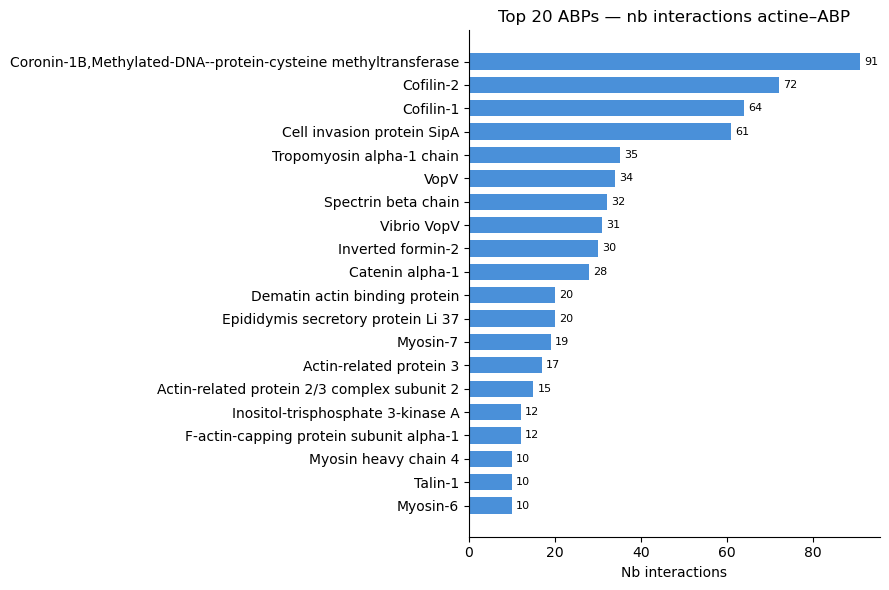

In [3]:
# Bar chart : top ABPs par nb interactions
top20 = abp_stats.head(20).sort_values("nb_interactions")
fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(top20["protein"], top20["nb_interactions"], color="#4a90d9", height=0.7)
ax.bar_label(bars, fmt="%d", padding=3, fontsize=8)
ax.set_xlabel("Nb interactions")
ax.set_title("Top 20 ABPs — nb interactions actine–ABP")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## 2. Sites S1 utilisés par chaque ABP

In [4]:
# Matrice binaire ABP × site S1 (présence = au moins 1 interaction)
abp_s1 = (
    hetero_m.dropna(subset=["protein", "s1_binding_site_cluster_data_70"])
    .groupby(["protein", "s1_binding_site_cluster_data_70"])["subunit_1"]
    .count()
    .rename("nb_inter")
    .reset_index()
)

# Pivoter : lignes = ABP, colonnes = site S1
mat = abp_s1.pivot_table(
    index="protein",
    columns="s1_binding_site_cluster_data_70",
    values="nb_inter",
    aggfunc="sum",
    fill_value=0,
)

# Trier ABPs par nb de sites, sites par nb d'ABPs
mat = mat.loc[
    mat.gt(0).sum(axis=1).sort_values(ascending=False).index,
    mat.gt(0).sum(axis=0).sort_values(ascending=False).index,
]

print(f"Matrice : {mat.shape[0]} ABPs × {mat.shape[1]} sites S1")
print(f"Sites S1 avec 2+ ABPs : {(mat.gt(0).sum() >= 2).sum()}")

Matrice : 53 ABPs × 141 sites S1
Sites S1 avec 2+ ABPs : 28


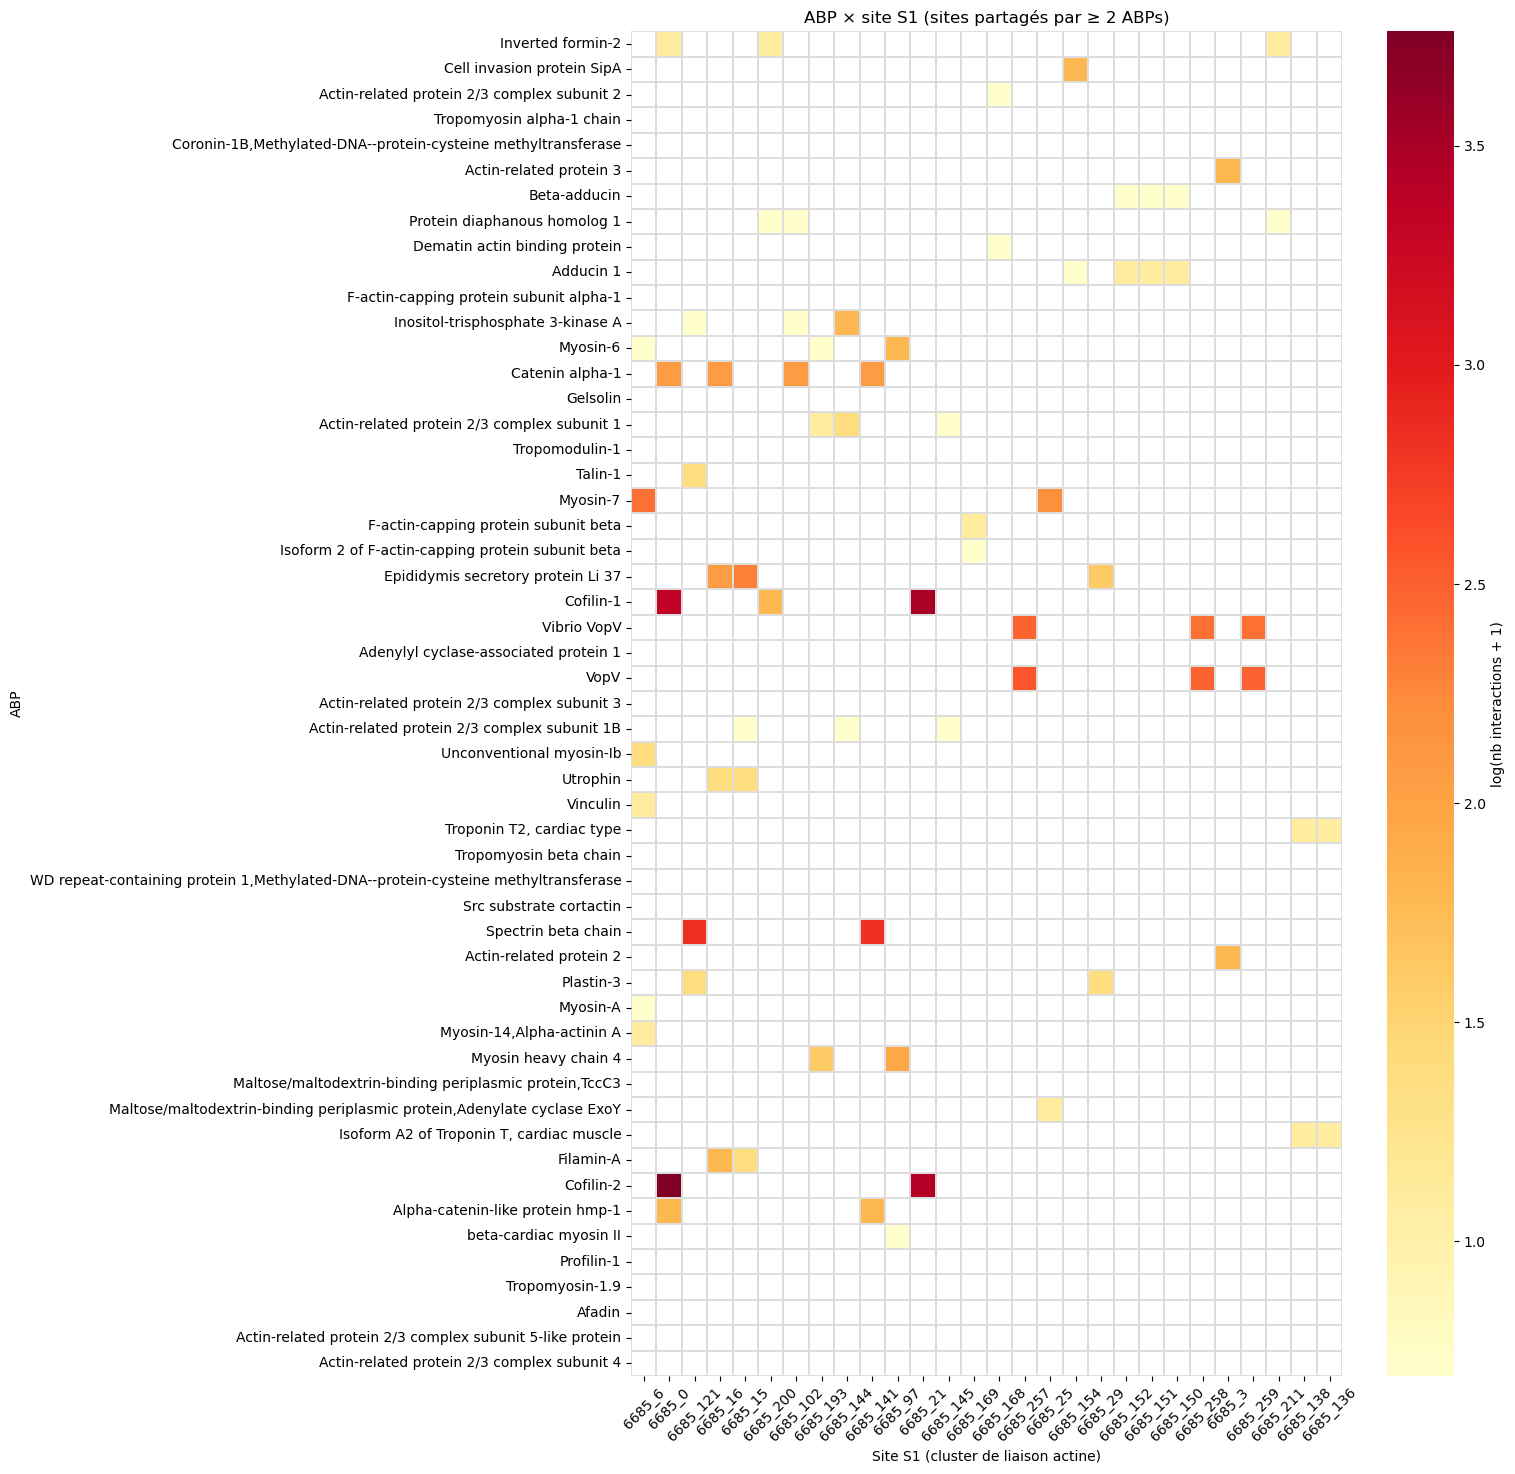

In [5]:
# Heatmap ABP × site S1 (présence/absence + intensité = nb interactions)
mat_bool = mat.gt(0).astype(int)  # pour le masque
mat_log  = np.log1p(mat)          # log pour atténuer les grands écarts

# Ne garder que les sites partagés par ≥ 2 ABPs
shared_sites = mat.columns[mat.gt(0).sum() >= 2]
mat_shared   = mat_log[shared_sites]

fig_h = max(6, len(mat_shared) * 0.28)
fig_w = max(8, len(shared_sites) * 0.55)
fig, ax = plt.subplots(figsize=(fig_w, fig_h))
sns.heatmap(
    mat_shared,
    ax=ax,
    cmap="YlOrRd",
    linewidths=0.3,
    linecolor="#dddddd",
    mask=mat_shared == 0,
    cbar_kws={"label": "log(nb interactions + 1)"},
)
ax.set_title("ABP × site S1 (sites partagés par ≥ 2 ABPs)", fontsize=12)
ax.set_xlabel("Site S1 (cluster de liaison actine)")
ax.set_ylabel("ABP")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

## Heatmap ABP × positions actine (= streamlit) + dendrogramme

Mêmes données que le heatmap streamlit (`_build_abp_heatmap_data` : %ASA buried moyen équitable par cluster C70, ABP par titre). Ajout du **dendrogramme des ABP à droite**, **noms à gauche**, format large pour Word.

/Users/user/Desktop/stage/actin_project/.pixi/envs/default/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


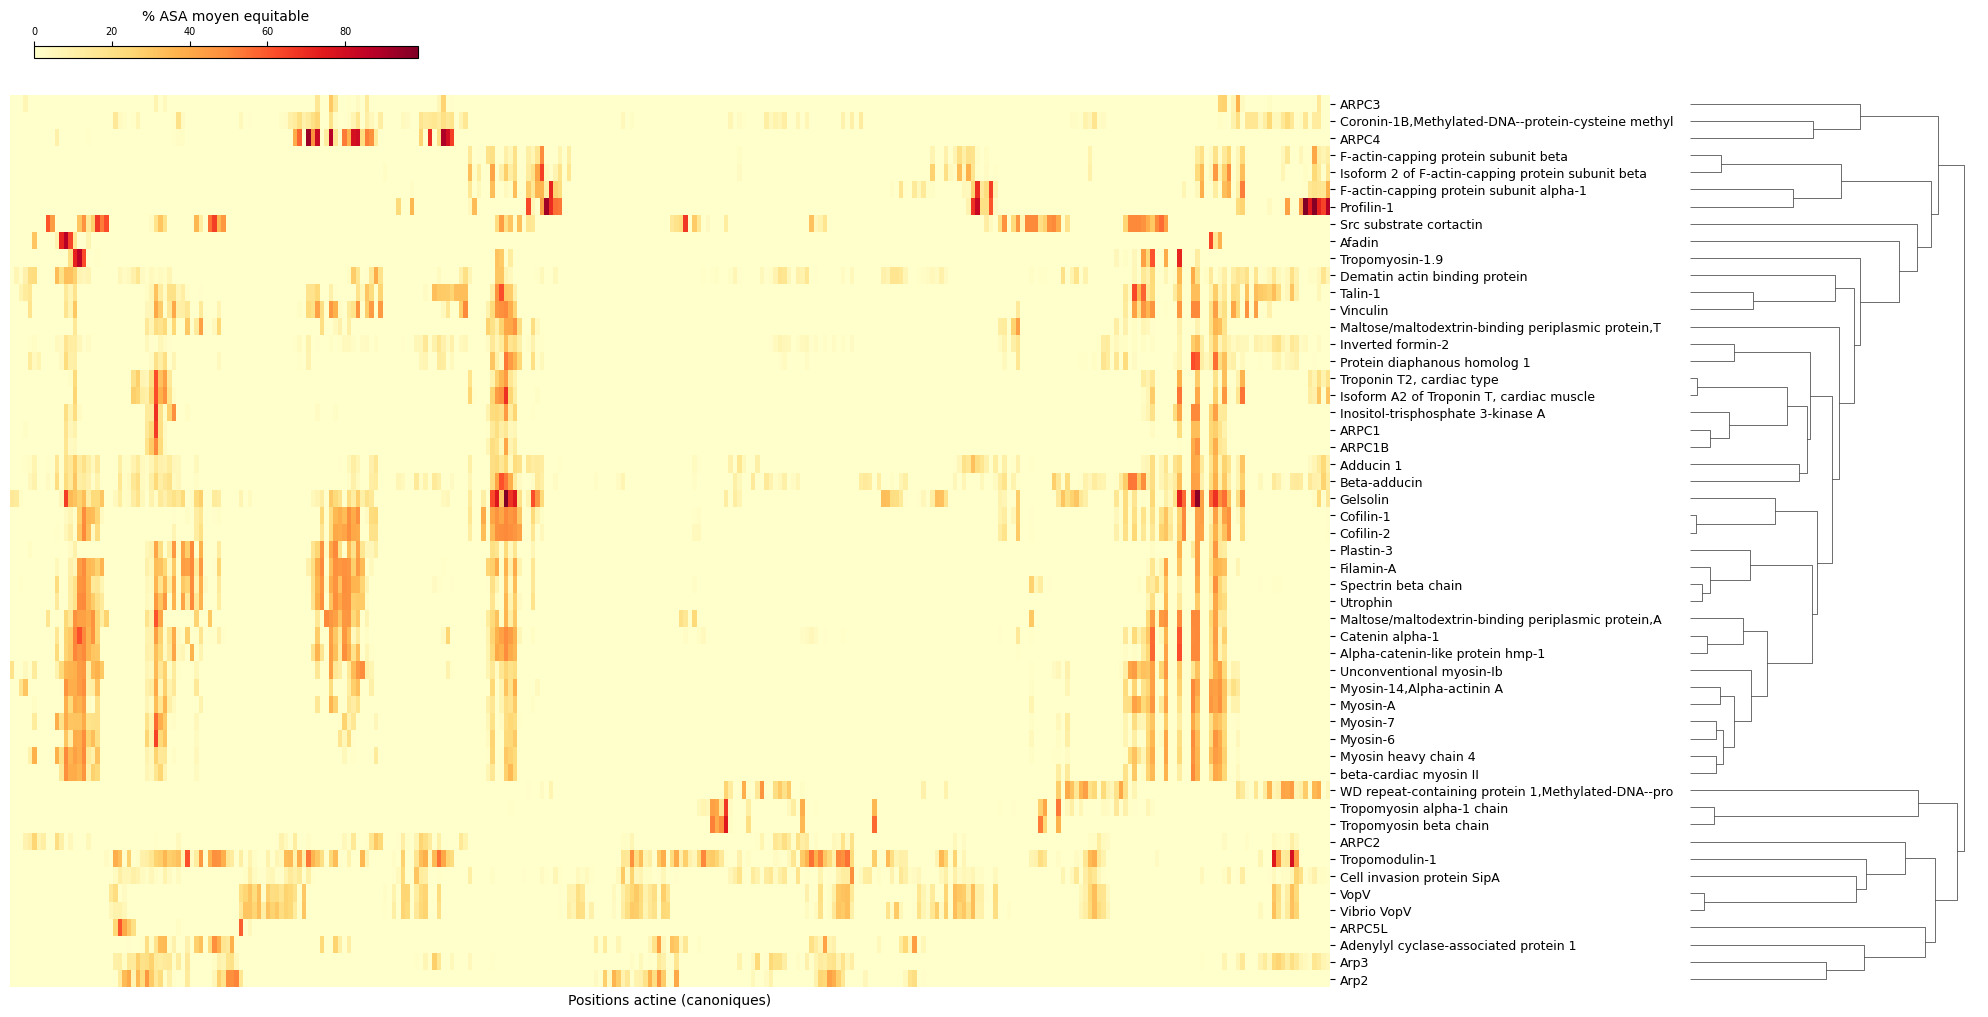

In [6]:
# Heatmap ABP x positions actine (= streamlit) + dendrogramme (pour Word)
import seaborn as sns, matplotlib as mpl
from scipy.cluster.hierarchy import leaves_list
from pathlib import Path as _P
_R = _P('..') if _P('../data').exists() else _P('.')
df3 = pd.read_csv(_R/'data/filtered/details/3.interface_residues.csv')
df3['buried_ASA_percent'] = pd.to_numeric(df3['buried_ASA_percent'].astype(str).str.replace('%','',regex=False), errors='coerce')
df3['canon'] = pd.to_numeric(df3['residue_number_canon_mafft'], errors='coerce')
df3 = df3[df3.canon.notna() & df3.buried_ASA_percent.notna()].copy()
di = pd.read_csv(_R/'data/filtered/details/1.interactions.csv')
da = pd.read_csv(_R/'data/filtered/filtered_all_data.csv', low_memory=False)
pp = pd.read_csv(_R/'data/filtered/proteins_per_pdb.csv')
actin_ch = set(pp[pp.is_actin]['chain'].str.lower())
homo = set(di[di['chain_B_id'].str.lower().isin(actin_ch)]['interaction_id'])
het = di[~di.interaction_id.isin(homo)].merge(
    da[['subunit_1','subunit_2','subunit_2_title','s2_actine','cluster_data_70']],
    left_on=['chain_A_id','chain_B_id'], right_on=['subunit_1','subunit_2'], how='left').drop_duplicates('interaction_id')
het = het[het['s2_actine'].fillna(False)==False].copy()
import re as _re
def _arp_name(n):
    if 'complex subunit 5-like' in n: return 'ARPC5L'
    mc = _re.search(r'complex subunit (\d+[A-Za-z]?)', n)
    if mc: return 'ARPC' + mc.group(1)
    if _re.match(r'Actin-related protein 3(\b|,|$)', n): return 'Arp3'
    if _re.match(r'Actin-related protein 2(\b|,|$)', n): return 'Arp2'
    return n
het['abp'] = het['subunit_2_title'].fillna('Unknown').str.replace(r'\s*\(.*?\)','',regex=True).str.strip().str[:50].map(_arp_name)
s1ch=het.set_index('interaction_id')['chain_A_id'].str.lower(); abpn=het.set_index('interaction_id')['abp']; c70n=het.set_index('interaction_id')['cluster_data_70']
d3 = df3[df3.interaction_id.isin(set(het.interaction_id))].copy()
d3['_s1c']=d3.interaction_id.map(s1ch); d3=d3[d3.chain.str.lower()==d3._s1c].copy()
d3['abp']=d3.interaction_id.map(abpn); d3['canon']=d3.canon.astype(int); d3['c70']=d3.interaction_id.map(c70n)
abp_freq=d3.groupby('abp')['interaction_id'].nunique().sort_values(ascending=False)
ac70n=d3.groupby(['abp','c70'])['interaction_id'].nunique()
ag=d3.groupby(['abp','c70','canon'])['buried_ASA_percent'].sum().reset_index(name='s')
ag['a70']=ag.apply(lambda r:r['s']/max(ac70n.get((r.abp,r.c70),1),1),axis=1)
nc70=d3.groupby('abp')['c70'].nunique()
eq=ag.groupby(['abp','canon'])['a70'].sum().reset_index(); eq['v']=eq['a70']/eq['abp'].map(nc70)
pivot=eq.pivot(index='abp',columns='canon',values='v').loc[abp_freq.index].fillna(0)   # noms seuls (pas de parentheses)

g=sns.clustermap(pivot, cmap='YlOrRd', figsize=(24,10.5), row_cluster=True, col_cluster=False, metric='correlation',
                 dendrogram_ratio=(0.12,0.0), xticklabels=False, cbar_pos=None)
order=g.dendrogram_row.reordered_ind
g.ax_heatmap.yaxis.set_ticks_position('right'); g.ax_heatmap.yaxis.set_label_position('right')
g.ax_heatmap.set_yticks(np.arange(len(pivot))+0.5)
g.ax_heatmap.set_yticklabels([pivot.index[i] for i in order], fontsize=9, rotation=0)
g.ax_heatmap.set_ylabel('')
g.ax_heatmap.set_position([0.04, 0.06, 0.55, 0.85])   # heatmap a gauche
g.ax_row_dendrogram.set_position([0.74, 0.06, 0.12, 0.85]); g.ax_row_dendrogram.invert_xaxis()  # X=0.74 -> dendro colle aux noms (baisser X = plus proche)
g.ax_heatmap.set_xlabel('Positions actine (canoniques)')
# legende gradient : barre horizontale propre en haut a gauche
cax=g.fig.add_axes([0.05,0.945,0.16,0.012])
sm=mpl.cm.ScalarMappable(cmap='YlOrRd', norm=mpl.colors.Normalize(pivot.values.min(), pivot.values.max()))
g.fig.colorbar(sm, cax=cax, orientation='horizontal', label='% ASA moyen equitable')
cax.tick_params(labelsize=7); cax.xaxis.set_label_position('top'); cax.xaxis.set_ticks_position('top')
plt.show()

## Choix du nombre de clusters k (méthode du coude)

k-means sur les profils ABP (mêmes données que le dendrogramme : % ASA équitable C70 par position). On trace l'inertie (somme des carrés intra-cluster) en fonction de k ; le « coude » indique le k optimal.

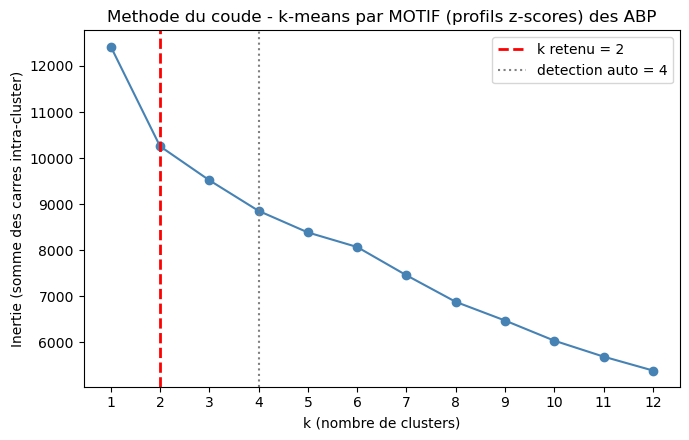

k retenu : 2 | detection auto : 4


In [7]:
# Methode du coude (elbow) pour k-means sur les profils de liaison ABP (scipy, sans sklearn)
from scipy.cluster.vq import kmeans2
ks = list(range(1, 13))
Xr = pivot.values.astype(float)
X = (Xr - Xr.mean(axis=1, keepdims=True)) / (Xr.std(axis=1, keepdims=True) + 1e-9)  # z-score par ABP -> distance par motif
inertias = []
for k in ks:
    best = np.inf
    for seed in range(8):
        try:
            cent, lab = kmeans2(X, k, minit='++', seed=seed)
        except Exception:
            continue
        best = min(best, float(((X - cent[lab]) ** 2).sum()))
    inertias.append(best)

# detection du coude = point le plus eloigne de la droite (premier->dernier)
x = np.array(ks, float); y = np.array(inertias, float)
xn = (x - x.min()) / (x.max() - x.min()); yn = (y - y.min()) / (y.max() - y.min())
x1, y1, x2, y2 = xn[0], yn[0], xn[-1], yn[-1]
dist = np.abs((y2 - y1) * xn - (x2 - x1) * yn + x2 * y1 - y2 * x1) / np.hypot(y2 - y1, x2 - x1)
k_auto = int(x[np.argmax(dist)])
K_CHOISI = 2   # choix retenu (coude visuel, distance de correlation)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(ks, inertias, 'o-', color='steelblue')
ax.axvline(K_CHOISI, color='red', ls='--', lw=2, label=f'k retenu = {K_CHOISI}')
ax.axvline(k_auto, color='grey', ls=':', label=f'detection auto = {k_auto}')
ax.set_xlabel('k (nombre de clusters)'); ax.set_ylabel('Inertie (somme des carres intra-cluster)')
ax.set_title('Methode du coude - k-means par MOTIF (profils z-scores) des ABP'); ax.legend()
ax.set_xticks(ks)
plt.tight_layout(); plt.show()
print('k retenu :', K_CHOISI, '| detection auto :', k_auto)

## k-means (k=2) + PCA des ABP — forme = côté filament (+ / − / partout)

Couleur = cluster k-means (motif) ; **forme du marqueur = tendance de localisation dans le filament** (barbé +, pointé −, partout), dérivée de `actin_filament_positions.csv` (protomères d'actine liés par chaque ABP).

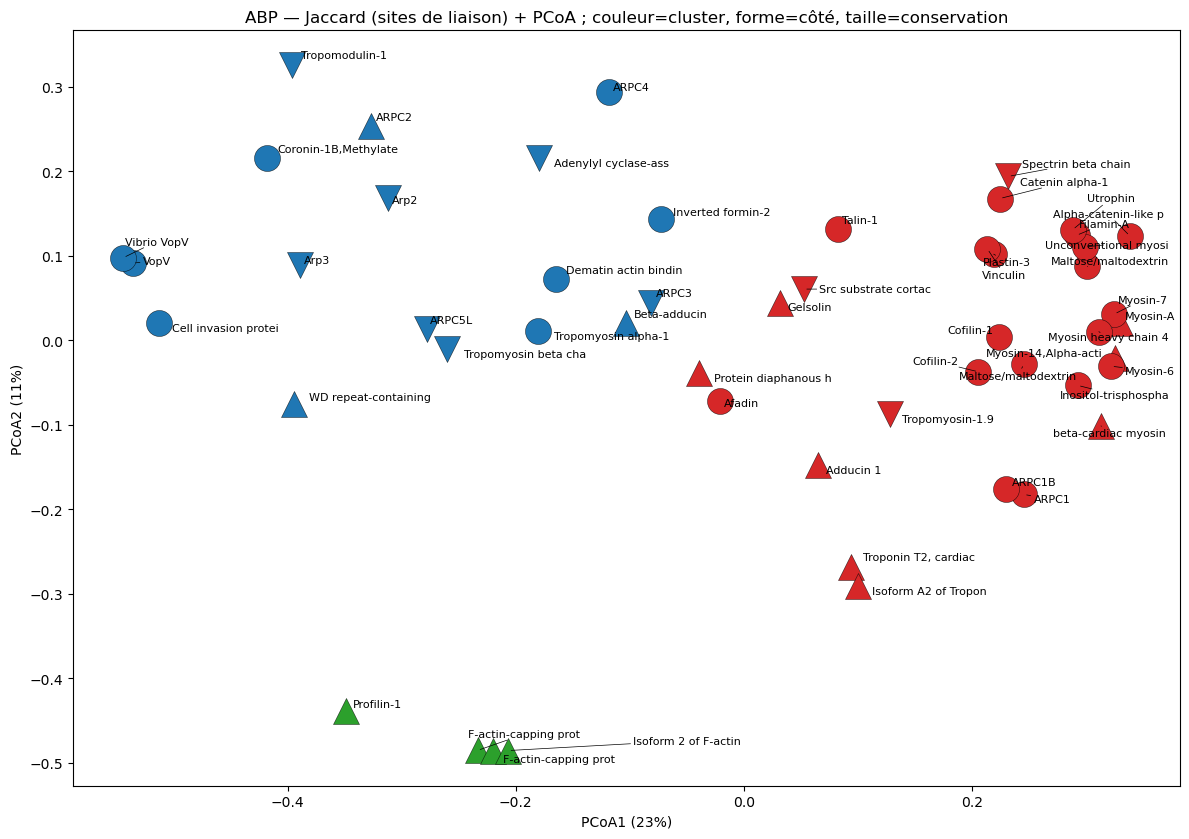

Cluster 1 (n=18): Coronin-1B,Methylated-DNA--protein-cysteine methyl, Cell invasion protein SipA, Tropomyosin alpha-1 chain, VopV, Vibrio VopV, Inverted formin-2, Dematin actin binding protein, Arp3, ARPC2, Arp2, Tropomodulin-1, ARPC3, Adenylyl cyclase-associated protein 1, Beta-adducin, WD repeat-containing protein 1,Methylated-DNA--pro, ARPC4, Tropomyosin beta chain, ARPC5L

Cluster 2 (n=30): Cofilin-1, Spectrin beta chain, Catenin alpha-1, Myosin-7, Inositol-trisphosphate 3-kinase A, Alpha-catenin-like protein hmp-1, Myosin heavy chain 4, Myosin-6, Talin-1, Filamin-A, Adducin 1, Protein diaphanous homolog 1, Maltose/maltodextrin-binding periplasmic protein,A, Gelsolin, Plastin-3, Unconventional myosin-Ib, Utrophin, Cofilin-2, ARPC1, Troponin T2, cardiac type, Vinculin, Isoform A2 of Troponin T, cardiac muscle, Myosin-14,Alpha-actinin A, ARPC1B, Src substrate cortactin, Tropomyosin-1.9, Myosin-A, Maltose/maltodextrin-binding periplasmic protein,T, beta-cardiac myosin II, Afadin

Clus

In [8]:
# k-means (k=2) + PCA ; couleur=cluster, forme=cote filament (+/-/partout)
from scipy.cluster.vq import kmeans2
from matplotlib.lines import Line2D
from pathlib import Path as _P
_R = _P('..') if _P('../data').exists() else _P('.')

# --- tendance cote filament par ABP (via actin_filament_positions.csv) ---
fil = pd.read_csv(_R/'data/filtered/actin_filament_positions.csv'); c2l = dict(zip(fil['chain'].str.lower(), fil['label']))
_da = pd.read_csv(_R/'data/filtered/filtered_all_data.csv', low_memory=False); _da['s2_actine']=_da['s2_actine'].fillna(False).astype(bool)
_di = pd.read_csv(_R/'data/filtered/details/1.interactions.csv').merge(
    _da[['subunit_1','subunit_2','subunit_2_title','s2_actine']].drop_duplicates(), left_on=['chain_A_id','chain_B_id'], right_on=['subunit_1','subunit_2'], how='left')
_di['s2_actine']=_di['s2_actine'].fillna(False).astype(bool); _di=_di[~_di['s2_actine']].copy()
_di['abp']=_di['subunit_2_title'].fillna('Unknown').str.replace(r'\s*\(.*?\)','',regex=True).str.strip().str[:50].map(_arp_name)
_di['fil']=_di['chain_A_id'].str.lower().map(c2l)
def _simp(l):
    if pd.isna(l): return None
    if l=='+': return '+'          # bout barbe strict
    if l=='-': return '-'          # bout pointe strict
    return 'side'                  # side, +2, +3, -2, -3 -> lateral
_di['grp']=_di['fil'].map(_simp)
# tendance par presence (ensemble des positions), identique a streamlit _pos_border_color :
# + (avec ou sans side) -> barbe ; - (avec ou sans side) -> pointe ; side seul ou les 2 bouts -> lateral
posset=_di.dropna(subset=['grp']).groupby('abp')['grp'].apply(set)
def _tend(s):
    hp='+' in s; hm='-' in s
    if hp and not hm: return '+'
    if hm and not hp: return '-'
    return 'partout'
tendance={a:_tend(posset.get(a,set())) for a in posset.index}
tend_arr=np.array([tendance.get(a,'partout') for a in pivot.index])

# --- distance de Jaccard (presence/absence de site) + PCoA (MDS classique) ---
from scipy.spatial.distance import pdist, squareform
_B=(pivot.values>0).astype(bool)
_Dj=np.nan_to_num(squareform(pdist(_B,metric='jaccard')))
_n=_Dj.shape[0]; _Jc=np.eye(_n)-np.ones((_n,_n))/_n
_G=-0.5*_Jc@(_Dj**2)@_Jc
_val,_vec=np.linalg.eigh(_G); _ord=_val.argsort()[::-1]; _val,_vec=_val[_ord],_vec[:,_ord]
_posv=np.maximum(_val,0); pcs=_vec[:,:2]*np.sqrt(_posv[:2]); ev=_posv/_posv.sum()*100
# k-means (k=2) sur l'embedding PCoA (qqs dimensions)
K=3; _kd=min(6,_n); _emb=_vec[:,:_kd]*np.sqrt(_posv[:_kd])
best=None
for sd in range(30):
    cc,ll=kmeans2(_emb,K,minit='++',seed=sd)
    if len(set(ll))<K: continue
    ss=((_emb-cc[ll])**2).sum()
    if best is None or ss<best[0]: best=(ss,ll)
labels=best[1]

# --- taille = conservation moyenne de l'interface actine (ponderee par enfouissement) ---
_cdf=pd.read_csv(_R/'data/proteocast/conservation_vs_asa_per_position.csv')
_cmap=dict(zip(_cdf['canon'].astype(int), _cdf['conservation']))
_cvec=np.array([_cmap.get(int(c),np.nan) for c in pivot.columns]); _msk=~np.isnan(_cvec)
_W=pivot.values.astype(float)
_num=(_W[:,_msk]*_cvec[_msk]).sum(1); _den=_W[:,_msk].sum(1)
cons_abp=np.where(_den>0,_num/np.where(_den>0,_den,1),np.nan)   # conservation moyenne ponderee de l'interface
cmin=np.nanmin(cons_abp); cmax=np.nanmax(cons_abp)
_t=(cons_abp-cmin)/(cmax-cmin); sizes=20+620*np.power(np.clip(_t,0,1),2.5); sizes=np.where(np.isnan(sizes),20,sizes)

cols=['#1f77b4','#d62728','#2ca02c','#ff7f0e']; shp={'+':'^','-':'v','partout':'o'}
fig,ax=plt.subplots(figsize=(12,8.5))
for cl in range(K):
    for t,mk in shp.items():
        m=(labels==cl)&(tend_arr==t)
        if m.any(): ax.scatter(pcs[m,0],pcs[m,1],marker=mk,color=cols[cl],s=350,edgecolor='k',lw=0.3)
texts = []
for i, nm in enumerate(pivot.index):
    texts.append(
        ax.text(
            pcs[i,0],
            pcs[i,1],
            nm[:20],
            fontsize=8))
adjust_text(
    texts,
    ax=ax,
    arrowprops=dict(arrowstyle='-', lw=0.5)
)
sh=[Line2D([0],[0],marker=m,color='grey',ls='',ms=10,label=l) for l,m in [('barbé (+)','^'),('pointé (−)','v'),('partout','o')]]
co=[Line2D([0],[0],marker='s',color=cols[c],ls='',ms=10,label=f'cluster {c+1}') for c in range(K)]
ax.set_xlabel(f'PCoA1 ({ev[0]:.0f}%)'); ax.set_ylabel(f'PCoA2 ({ev[1]:.0f}%)')
ax.set_title('ABP — Jaccard (sites de liaison) + PCoA ; couleur=cluster, forme=côté, taille=conservation')
plt.tight_layout(); plt.show()
for cl in range(K):
    print(f'Cluster {cl+1} (n={int((labels==cl).sum())}):', ', '.join(pivot.index[labels==cl])); print()
_cs=pd.Series(cons_abp,index=pivot.index).dropna().sort_values(ascending=False)
print('Conservation interface — top 5 :'); print(_cs.head().round(3).to_string())
print('\nConservation interface — bottom 5 :'); print(_cs.tail().round(3).to_string())

## PCA biophysique des ABP (ordination) — 10 descripteurs d'interface

Contrairement à la PCA d'**empreinte** (qui regroupe les ABP par *position* de liaison sur l'actine), cette PCA décrit chaque ABP par **10 descripteurs biophysiques de son interface côté actine** (moyennes équitables par cluster C70, z-scorées) :
conservation, hydrophobicité (Kyte-Doolittle), %H-bond, %pont salin, fraction chargée +/−, position filament (ordinale), taille d'interface (Å²), nb de sites occupés, nb de compétiteurs.

⚠️ **C'est une figure d'ordination, pas de clustering** : les ABP forment un *gradient* continu (silhouette k-means ≈ 0.18 < 0.30 de l'empreinte). On la lit via les **loadings** (panel de droite) et on la **colore par position filament** (overlay biologique), pas par k-means.

La section produit **3 vues** : (1) individus colorés par position, (2) **cercle de corrélation** (variables en flèches), (3) **biplot** combinant individus + flèches.

52 ABP, 11 descripteurs (agreg. 2 etages : par site -> pondere enfouissement -> moyenne entre sites). Imputes: aucun
Variance PC1+PC2 = 24% + 15% = 40%


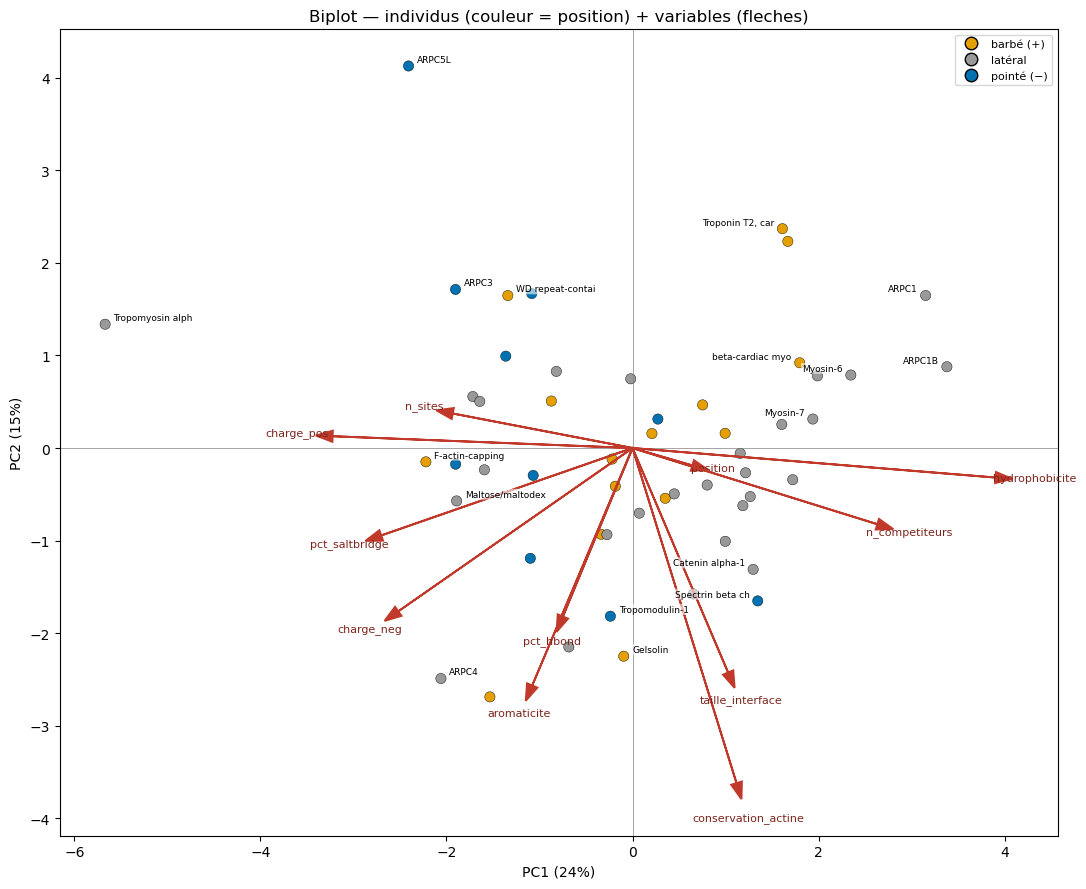

Silhouette k-means k=2 = 0.160  (vs ~0.30 pour la PCA d'empreinte -> ici gradient, pas clusters nets)


In [9]:
# === PCA biophysique (ordination) : 11 descripteurs d'interface cote actine ===
import warnings; warnings.filterwarnings('ignore')
import re as _re
from pathlib import Path as _P
from matplotlib.lines import Line2D
from scipy.spatial.distance import pdist, squareform
_R = _P('..') if _P('../data').exists() else _P('.')

def _arpn(n):
    if 'complex subunit 5-like' in n: return 'ARPC5L'
    mc=_re.search(r'complex subunit (\d+[A-Za-z]?)',n)
    if mc: return 'ARPC'+mc.group(1)
    if _re.match(r'Actin-related protein 3(\b|,|$)',n): return 'Arp3'
    if _re.match(r'Actin-related protein 2(\b|,|$)',n): return 'Arp2'
    return n
_df3=pd.read_csv(_R/'data/filtered/details/3.interface_residues.csv')
_df3['pct']=pd.to_numeric(_df3['buried_ASA_percent'].astype(str).str.replace('%','',regex=False),errors='coerce')
_df3['a2']=pd.to_numeric(_df3['buried_ASA_Å²'].astype(str).str.replace('<0.1','0.05',regex=False),errors='coerce')
_df3['canon']=pd.to_numeric(_df3['residue_number_canon_mafft'],errors='coerce')
_df3=_df3[_df3.canon.notna()&_df3.pct.notna()].copy()
_di=pd.read_csv(_R/'data/filtered/details/1.interactions.csv')
_da=pd.read_csv(_R/'data/filtered/filtered_all_data.csv',low_memory=False)
_pp=pd.read_csv(_R/'data/filtered/proteins_per_pdb.csv'); _ac=set(_pp[_pp.is_actin]['chain'].str.lower())
_homo=set(_di[_di['chain_B_id'].str.lower().isin(_ac)]['interaction_id'])
_het=_di[~_di.interaction_id.isin(_homo)].merge(
    _da[['subunit_1','subunit_2','subunit_2_title','s2_actine','cluster_data_70','s1_binding_site_cluster_data_70']],
    left_on=['chain_A_id','chain_B_id'],right_on=['subunit_1','subunit_2'],how='left').drop_duplicates('interaction_id')
_het=_het[_het['s2_actine'].fillna(False)==False].copy()
_het['abp']=_het['subunit_2_title'].fillna('Unknown').str.replace(r'\s*\(.*?\)','',regex=True).str.strip().str[:50].map(_arpn)
# un "site" = cluster de site de liaison S1 (fallback = cluster_data_70 si manquant)
_het['site']=_het['s1_binding_site_cluster_data_70'].fillna('c70_'+_het['cluster_data_70'].astype(str))
_im=_het.set_index('interaction_id'); _s1=_im['chain_A_id'].str.lower(); _ab=_im['abp']; _st=_im['site']
_dd=_df3[_df3.interaction_id.isin(set(_het.interaction_id))].copy()
_dd['_c']=_dd.interaction_id.map(_s1); _dd=_dd[_dd.chain.str.lower()==_dd._c].copy()   # cote actine
_dd['abp']=_dd.interaction_id.map(_ab); _dd['site']=_dd.interaction_id.map(_st); _dd['canon']=_dd.canon.astype(int)
_cdf=pd.read_csv(_R/'data/proteocast/conservation_vs_asa_per_position.csv'); _cons=dict(zip(_cdf['canon'].astype(int),_cdf['conservation']))
_KD={'A':1.8,'R':-4.5,'N':-3.5,'D':-3.5,'C':2.5,'Q':-3.5,'E':-3.5,'G':-0.4,'H':-3.2,'I':4.5,'L':3.8,'K':-3.9,'M':1.9,'F':2.8,'P':-1.6,'S':-0.8,'T':-0.7,'W':-0.9,'Y':-1.3,'V':4.2}
def _mode(s): m=s.mode(); return m.iloc[0] if len(m) else None
# --- etage 1 : par (abp, site, canon) -> enfouissement moyen de la position dans le site ---
_pos=_dd.groupby(['abp','site','canon']).agg(w=('pct','mean'),a2=('a2','mean'),res=('residue_name',_mode)).reset_index()
_pos['kd']=_pos['res'].map(lambda r:_KD.get(str(r),0.0)); _pos['cons']=_pos['canon'].map(lambda c:_cons.get(int(c),np.nan))
_pos['ispos']=_pos['res'].isin({'R','K'}).astype(float); _pos['isneg']=_pos['res'].isin({'D','E'}).astype(float); _pos['isaro']=_pos['res'].isin({'F','Y','W'}).astype(float)
def _wm(g,col):
    w=g['w'].values; x=g[col].values; m=~np.isnan(x)
    return (w[m]*x[m]).sum()/w[m].sum() if w[m].sum()>0 else np.nan
# --- etage 1bis : par (abp, site) moyennes ponderees enfouissement ; etage 2 : moyenne entre sites ---
_site=_pos.groupby(['abp','site']).apply(lambda g:pd.Series({
    'conservation_actine':_wm(g,'cons'),'hydrophobicite':_wm(g,'kd'),'charge_pos':_wm(g,'ispos'),
    'charge_neg':_wm(g,'isneg'),'aromaticite':_wm(g,'isaro'),'asa_moyen':_wm(g,'w'),'taille_interface':g['a2'].sum()})).reset_index()
F=_site.groupby('abp')[['conservation_actine','hydrophobicite','charge_pos','charge_neg','aromaticite','asa_moyen']].mean()
F['taille_interface']=_site.groupby('abp')['taille_interface'].max()   # la plus grosse interface de l'ABP (pas la moyenne/somme)
# ratios H-bond / pont salin : par site puis moyenne entre sites
_hb=_het.groupby(['abp','site'])[['num_contacts','num_hbonds','num_salt_bridges']].sum().reset_index()
_hb['pct_hbond']=100*_hb['num_hbonds']/_hb['num_contacts']; _hb['pct_saltbridge']=100*_hb['num_salt_bridges']/_hb['num_contacts']
F=F.join(_hb.groupby('abp')[['pct_hbond','pct_saltbridge']].mean())
# position ordinale (aussi utilisee en couleur)
_fil=pd.read_csv(_R/'data/filtered/actin_filament_positions.csv'); _c2l=dict(zip(_fil['chain'].str.lower(),_fil['label']))
_het['fil']=_het['chain_A_id'].str.lower().map(_c2l)
_het['grp']=_het['fil'].map(lambda l: l if l in ('+','-') else ('side' if pd.notna(l) else None))
_ps=_het.dropna(subset=['grp']).groupby('abp')['grp'].apply(set)
F['position']=pd.Series({a:(1.0 if ('+' in _ps.get(a,set()) and '-' not in _ps.get(a,set())) else (-1.0 if ('-' in _ps.get(a,set()) and '+' not in _ps.get(a,set())) else 0.0)) for a in F.index})
F['n_sites']=_het.groupby('abp')['cluster_data_70'].nunique()   # nb de clusters d'interface C70 de l'ABP
_abs1=_het.dropna(subset=['s1_binding_site_cluster_data_70']).groupby('abp')['s1_binding_site_cluster_data_70'].apply(set)
_s1a={}
for a,ss in _abs1.items():
    for s in ss: _s1a.setdefault(s,set()).add(a)
F['n_competiteurs']=pd.Series({a:len({x for s in _abs1.get(a,set()) for x in _s1a.get(s,set())}-{a}) for a in F.index})
F=F[['conservation_actine','hydrophobicite','charge_pos','charge_neg','aromaticite','taille_interface','pct_hbond','pct_saltbridge','position','n_sites','n_competiteurs']]
_miss=F[F.isna().any(axis=1)].index.tolist(); F=F.fillna(F.median(numeric_only=True))
print(f"{len(F)} ABP, {F.shape[1]} descripteurs (agreg. 2 etages : par site -> pondere enfouissement -> moyenne entre sites). Imputes: {_miss if _miss else 'aucun'}")

# z-score + PCA
X=F.values.astype(float); Xz=(X-X.mean(0))/(X.std(0)+1e-9)
Xc=Xz-Xz.mean(0); U,S,Vt=np.linalg.svd(Xc,full_matrices=False); pcs=U[:,:2]*S[:2]; ev=(S**2)/(S**2).sum()*100
print(f"Variance PC1+PC2 = {ev[0]:.0f}% + {ev[1]:.0f}% = {ev[0]+ev[1]:.0f}%")

# couleur = position filament
_pcol={1.0:'#E69F00',-1.0:'#0072B2',0.0:'#999999'}; _plab={1.0:'barbé (+)',-1.0:'pointé (−)',0.0:'latéral'}
_pc=F['position'].map(_pcol).values

# === Biplot : individus (couleur = position) + variables (fleches) ===
cor=np.array([[np.corrcoef(Xz[:,j],pcs[:,k])[0,1] for k in range(2)] for j in range(F.shape[1])])
_f=0.72*np.abs(pcs).max()/np.abs(cor).max()
fig,axb=plt.subplots(figsize=(11,9))
axb.scatter(pcs[:,0],pcs[:,1],c=_pc,s=55,edgecolor='k',lw=.3,zorder=2)
# labels anti-chevauchement : ABP peripheriques, en reservant les emplacements des labels de fleches
_dist=np.hypot(pcs[:,0],pcs[:,1]); _thr=np.percentile(_dist,55)
_xr=pcs[:,0].max()-pcs[:,0].min(); _yr=pcs[:,1].max()-pcs[:,1].min()
_placed=[(cor[j,0]*_f*1.06,cor[j,1]*_f*1.06) for j in range(F.shape[1])]
def _free(x,y,mx=0.06,my=0.045):
    return all(not(abs(x-px)<mx*_xr and abs(y-py)<my*_yr) for px,py in _placed)
for i in np.argsort(-_dist):
    if _dist[i]<_thr: break
    x,y=pcs[i,0],pcs[i,1]
    if not _free(x,y): continue
    _placed.append((x,y)); sd=-1 if x>0 else 1
    axb.annotate(F.index[i][:16],(x,y),fontsize=6.5,zorder=4,ha='right' if sd<0 else 'left',
                 xytext=(6*sd,3),textcoords='offset points',bbox=dict(boxstyle='round,pad=0.1',fc='white',ec='none',alpha=0.6))
for j,nm in enumerate(F.columns):
    axb.arrow(0,0,cor[j,0]*_f,cor[j,1]*_f,color='#c0392b',head_width=.12,length_includes_head=True,lw=1.4,zorder=3)
    axb.annotate(nm,(cor[j,0]*_f*1.06,cor[j,1]*_f*1.06),fontsize=8,color='#7b241c',ha='center',zorder=3)
axb.axhline(0,color='grey',lw=.5); axb.axvline(0,color='grey',lw=.5)
axb.set_xlabel(f'PC1 ({ev[0]:.0f}%)'); axb.set_ylabel(f'PC2 ({ev[1]:.0f}%)')
axb.set_title('Biplot — individus (couleur = position) + variables (fleches)')
axb.legend(handles=[Line2D([0],[0],marker='o',ls='',mfc=_pcol[k],mec='k',ms=9,label=_plab[k]) for k in [1.0,0.0,-1.0]],loc='best',fontsize=8)
plt.tight_layout(); plt.show()

# silhouette (confirme que c'est une ordination, pas des clusters nets)
from scipy.cluster.vq import kmeans2
_D=squareform(pdist(Xz))
def _sil(D,lab):
    n=len(lab); s=np.zeros(n)
    for i in range(n):
        sm=(lab==lab[i]).copy(); sm[i]=False
        a=D[i,sm].mean() if sm.any() else 0
        b=min((D[i,lab==c].mean() for c in set(lab) if c!=lab[i]),default=0)
        s[i]=0 if max(a,b)==0 else (b-a)/max(a,b)
    return s.mean()
_bb=None
for sd in range(60):
    c,l=kmeans2(Xz,2,minit='++',seed=sd)
    if len(set(l))<2: continue
    ss=((Xz-c[l])**2).sum()
    if _bb is None or ss<_bb[0]: _bb=(ss,l)
print(f"Silhouette k-means k=2 = {_sil(_D,_bb[1]):.3f}  (vs ~0.30 pour la PCA d'empreinte -> ici gradient, pas clusters nets)")

## PCA des positions de l'actine (individu = résidu canonique)

Jusqu'ici les PCA prenaient les **ABP** comme individus. Ici on **transpose la question** : un point = **une position canonique de l'actine** (résidu MAFFT), décrite par ses propriétés vues côté actine à l'interface hétéro (actine–ABP). On répond à : *quelles positions de l'actine sont des « hubs » multi-ABP, et lesquelles sont des hotspots conservés et profondément enfouis ?*

**Population** : positions touchées par ≥ 1 ABP (interface hétéro).

**Descripteurs retenus** (z-scorés) :

| Descripteur | Sens biologique |
|---|---|
| `conservation` | conservation Proteocast (sensibilité aux mutations) — *demandé* |
| `n_fam` | nombre de **familles** d'ABP distinctes en contact (cluster séquence 40 %) — *demandé* |
| `n_fam_core` | idem mais seulement les familles enfouissant le résidu au **cœur** de l'interface (>25 % ASA) |
| `asa_max` | %ASA enfoui **maximum** à la position — *demandé* |
| `hydrophobicite` | Kyte-Doolittle du résidu canonique |
| `rsa` | accessibilité relative au solvant (exposition de surface) |
| `homo_asa` | surface enfouie par les contacts actine–actine (filament) |
| `hetero_asa` | surface enfouie par les contacts actine–ABP |
| `combined_asa` | surface totale enfouie (homo + hétéro) |
| `frac_buried` | fraction d'interactions où le résidu est réellement enfoui (>25 %) — consistance |
| `pref_filament` | tendance barbé (+1) / pointé (−1) / latéral (0) des ABP qui touchent la position |

*Note : `frac_impactful` et `asa_mean` ont été retirés ; `homo_asa`/`hetero_asa`/`combined_asa`, `entropie_abp`, `frac_buried` et `pref_filament` ont été ajoutés. Pistes restantes si besoin : `mean_vs` (variant score Proteocast), `charge_pos`/`charge_neg`/`aromaticite` (indicateurs 0/1 du type de résidu).*

Lecture : **panel gauche** = positions colorées par classe Proteocast (sensitive/tolerant) ; **panel droit** = cercle de corrélation des descripteurs.

294 positions actine (touchees par >=1 ABP) x 10 descripteurs. Imputes: ['hydrophobicite', 'rsa']
Variance PC1+PC2 = 26% + 21% = 47%


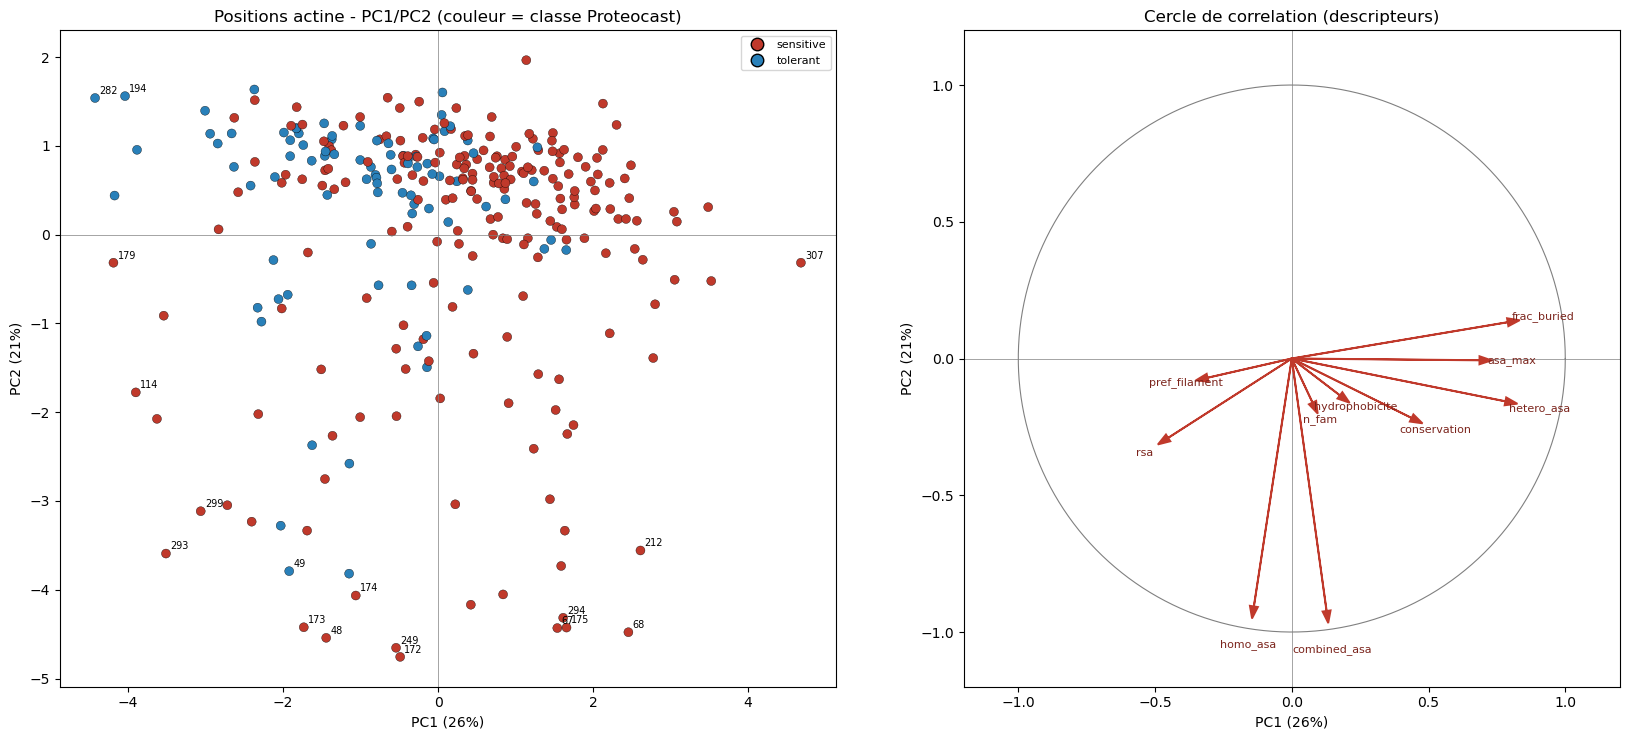


Loadings PC1/PC2 :
                  PC1    PC2
conservation    0.297 -0.163
n_fam           0.059 -0.139
asa_max         0.454 -0.005
hydrophobicite  0.131 -0.111
rsa            -0.304 -0.216
homo_asa       -0.090 -0.654
hetero_asa      0.512 -0.114
combined_asa    0.083 -0.665
frac_buried     0.517  0.096
pref_filament  -0.218 -0.055

Positions les plus extremes (hubs multi-ABP / forte interface) :
       n_fam  asa_max  conservation   PC1   PC2
canon                                          
68         4    100.0          3.79  2.46 -4.48
293        9     37.6          5.12 -3.51 -3.59
172       11     90.7          6.56 -0.49 -4.76
48        34     99.8          3.85 -1.44 -4.54
173       18     79.6          4.27 -1.73 -4.42
175        4    100.0          5.11  1.66 -4.43
307        1    100.0          6.08  4.68 -0.32
67         5     99.2          5.13  1.54 -4.43
282        1     16.7          2.36 -4.43  1.54
249        9     94.0          5.74 -0.54 -4.65


In [10]:
# === PCA des POSITIONS de l'actine (individu = residu canonique) ===
# Unite d'observation = une position canonique de l'actine, vue cote actine a l'interface hetero (actine-ABP).
import warnings; warnings.filterwarnings('ignore')
import re as _re
from pathlib import Path as _P
from matplotlib.lines import Line2D
_R = _P('..') if _P('../data').exists() else _P('.')

def _arpn(n):
    if 'complex subunit 5-like' in n: return 'ARPC5L'
    mc=_re.search(r'complex subunit (\d+[A-Za-z]?)',n)
    if mc: return 'ARPC'+mc.group(1)
    if _re.match(r'Actin-related protein 3(\b|,|$)',n): return 'Arp3'
    if _re.match(r'Actin-related protein 2(\b|,|$)',n): return 'Arp2'
    return n

# --- interfaces hetero (actine S1 <-> ABP), cote actine ---
_df3=pd.read_csv(_R/'data/filtered/details/3.interface_residues.csv')
_df3['pct']=pd.to_numeric(_df3['buried_ASA_percent'].astype(str).str.replace('%','',regex=False),errors='coerce')
_df3['a2']=pd.to_numeric(_df3['buried_ASA_Å²'].astype(str).str.replace('<0.1','0.05',regex=False),errors='coerce')
_df3['canon']=pd.to_numeric(_df3['residue_number_canon_mafft'],errors='coerce')
_df3=_df3[_df3.canon.notna()&_df3.pct.notna()].copy()
_di=pd.read_csv(_R/'data/filtered/details/1.interactions.csv')
_da=pd.read_csv(_R/'data/filtered/filtered_all_data.csv',low_memory=False)
_pp=pd.read_csv(_R/'data/filtered/proteins_per_pdb.csv'); _ac=set(_pp[_pp.is_actin]['chain'].str.lower())
_homo=set(_di[_di['chain_B_id'].str.lower().isin(_ac)]['interaction_id'])
_het=_di[~_di.interaction_id.isin(_homo)].merge(
    _da[['subunit_1','subunit_2','subunit_2_title','s2_actine','cluster_data_70','s2_sequence_cluster_40','s2_sequence_cluster_70']],
    left_on=['chain_A_id','chain_B_id'],right_on=['subunit_1','subunit_2'],how='left').drop_duplicates('interaction_id')
_het=_het[_het['s2_actine'].fillna(False)==False].copy()
_het['abp']=_het['subunit_2_title'].fillna('Unknown').str.replace(r'\s*\(.*?\)','',regex=True).str.strip().str[:50].map(_arpn)
_im=_het.set_index('interaction_id'); _s1=_im['chain_A_id'].str.lower(); _ab=_im['abp']; _c70=_im['cluster_data_70']; _fm=_im['s2_sequence_cluster_40']; _fm70=_im['s2_sequence_cluster_70']
_d=_df3[_df3.interaction_id.isin(set(_het.interaction_id))].copy()
_d['_c']=_d.interaction_id.map(_s1); _d=_d[_d.chain.str.lower()==_d._c].copy()   # cote actine
_d['abp']=_d.interaction_id.map(_ab); _d['fam']=_d.interaction_id.map(_fm); _d['fam70']=_d.interaction_id.map(_fm70); _d['c70']=_d.interaction_id.map(_c70); _d['canon']=_d.canon.astype(int)

_KD={'A':1.8,'R':-4.5,'N':-3.5,'D':-3.5,'C':2.5,'Q':-3.5,'E':-3.5,'G':-0.4,'H':-3.2,'I':4.5,'L':3.8,'K':-3.9,'M':1.9,'F':2.8,'P':-1.6,'S':-0.8,'T':-0.7,'W':-0.9,'Y':-1.3,'V':4.2}
def _mode(s): m=s.mode(); return m.iloc[0] if len(m) else None

# --- agregation par position canonique ---
P=_d.groupby('canon').agg(
    n_fam=('fam','nunique'),               # nb de FAMILLES d'ABP distinctes (cluster sequence 40%)
    n_fam70=('fam70','nunique'),           # idem au seuil 70% (sous-familles)
    asa_max=('pct','max'),                 # %ASA enfoui max                 [demande]
    asa_mean=('pct','mean'),               # %ASA enfoui moyen
    area_max=('a2','max'),                 # aire absolue enfouie max (A^2)
    n_interfaces=('interaction_id','nunique'),  # frequence (nb d'interactions hetero)
    n_c70=('c70','nunique'),               # diversite de sites d'interface
    res=('residue_name',_mode),
)
P['hydrophobicite']=P['res'].map(lambda r:_KD.get(str(r),np.nan))   # Kyte-Doolittle

# --- descripteurs Proteocast / exposition par position ---
_cdf=pd.read_csv(_R/'data/proteocast/conservation_vs_asa_per_position.csv').set_index('canon')
P=P.join(_cdf[['conservation','rsa','residue_class','homo_asa','hetero_asa','combined_asa']])
#   conservation = sensibilite Proteocast ; rsa = exposition ; homo/hetero/combined_asa = surface enfouie filament / ABP / totale

# --- descripteurs structuraux supplementaires ---
# fraction d'interactions ou le residu est REELLEMENT enfoui (%ASA > 25%) -> consistance du contact
P['frac_buried']=_d.assign(_b=(_d['pct']>25)).groupby('canon')['_b'].mean()
# nb de FAMILLES enfouissant le residu au COEUR de l'interface (>25% ASA) -- version 'coeur'
P['n_fam_core']=_d[_d['pct']>25].dropna(subset=['fam']).groupby('canon')['fam'].nunique()
P['n_fam_core']=P['n_fam_core'].fillna(0)
# idem au seuil 70% (sous-familles), coeur >25% ASA
P['n_fam70_core']=_d[_d['pct']>25].dropna(subset=['fam70']).groupby('canon')['fam70'].nunique().fillna(0)
P['n_fam70_core']=P['n_fam70_core'].reindex(P.index).fillna(0)
# preference filament (+1 barbe / -1 pointe / 0 lateral) des ABP touchant la position
_fil=pd.read_csv(_R/'data/filtered/actin_filament_positions.csv'); _c2l=dict(zip(_fil['chain'].str.lower(),_fil['label']))
def _filnum(l):
    if pd.isna(l): return np.nan
    l=str(l); return 1.0 if l.startswith('+') else (-1.0 if l.startswith('-') else 0.0)
_i2f=_het.assign(_fn=_het['chain_A_id'].str.lower().map(_c2l).map(_filnum)).set_index('interaction_id')['_fn']
P['pref_filament']=_d.assign(_pf=_d.interaction_id.map(_i2f)).groupby('canon')['_pf'].mean()

cols=['conservation','n_fam','asa_max','hydrophobicite','rsa','homo_asa','hetero_asa','combined_asa','frac_buried','pref_filament']
F=P[cols].copy(); _cls=P['residue_class'].fillna('?')
_miss=F.columns[F.isna().any()].tolist(); F=F.fillna(F.median(numeric_only=True))
print(f"{len(F)} positions actine (touchees par >=1 ABP) x {F.shape[1]} descripteurs. Imputes: {_miss if _miss else 'aucun'}")

# --- z-score + PCA (SVD) ---
X=F.values.astype(float); Xz=(X-X.mean(0))/(X.std(0)+1e-9)
Xc=Xz-Xz.mean(0); U,S,Vt=np.linalg.svd(Xc,full_matrices=False); pcs=U[:,:2]*S[:2]; ev=(S**2)/(S**2).sum()*100
print(f"Variance PC1+PC2 = {ev[0]:.0f}% + {ev[1]:.0f}% = {ev[0]+ev[1]:.0f}%")
cor=np.array([[np.corrcoef(Xz[:,j],pcs[:,k])[0,1] for k in range(2)] for j in range(F.shape[1])])

# --- figure : individus (gauche) + cercle de correlation (droite) ---
_ccol={'sensitive':'#c0392b','tolerant':'#2980b9','?':'#999999'}; _pc=_cls.map(_ccol).values
fig,(ax,axc)=plt.subplots(1,2,figsize=(17,7.5))
ax.scatter(pcs[:,0],pcs[:,1],c=_pc,s=42,edgecolor='k',lw=.25,zorder=2)
_dist=np.hypot(pcs[:,0],pcs[:,1])
for i in np.argsort(-_dist)[:18]:   # annoter les positions les plus extremes
    ax.annotate(str(F.index[i]),(pcs[i,0],pcs[i,1]),fontsize=7,zorder=4,xytext=(3,3),textcoords='offset points')
ax.axhline(0,color='grey',lw=.5); ax.axvline(0,color='grey',lw=.5)
ax.set_xlabel(f'PC1 ({ev[0]:.0f}%)'); ax.set_ylabel(f'PC2 ({ev[1]:.0f}%)')
ax.set_title('Positions actine - PC1/PC2 (couleur = classe Proteocast)')
ax.legend(handles=[Line2D([0],[0],marker='o',ls='',mfc=_ccol[k],mec='k',ms=9,label=k) for k in ['sensitive','tolerant']],loc='best',fontsize=8)
_th=np.linspace(0,2*np.pi,200); axc.plot(np.cos(_th),np.sin(_th),color='grey',lw=.8)
for j,nm in enumerate(F.columns):
    axc.arrow(0,0,cor[j,0],cor[j,1],color='#c0392b',head_width=.03,length_includes_head=True,lw=1.3,zorder=3)
    axc.annotate(nm,(cor[j,0]*1.10,cor[j,1]*1.10),fontsize=8,color='#7b241c',ha='center',va='center',zorder=3)
axc.axhline(0,color='grey',lw=.5); axc.axvline(0,color='grey',lw=.5)
axc.set_xlim(-1.2,1.2); axc.set_ylim(-1.2,1.2); axc.set_aspect('equal')
axc.set_xlabel(f'PC1 ({ev[0]:.0f}%)'); axc.set_ylabel(f'PC2 ({ev[1]:.0f}%)'); axc.set_title('Cercle de correlation (descripteurs)')
plt.tight_layout(); plt.show()

print('\nLoadings PC1/PC2 :'); print(pd.DataFrame(Vt[:2].T,index=F.columns,columns=['PC1','PC2']).round(3).to_string())
print('\nPositions les plus extremes (hubs multi-ABP / forte interface) :')
print(F.assign(PC1=pcs[:,0],PC2=pcs[:,1]).reindex(F.index[np.argsort(-_dist)[:10]])[['n_fam','asa_max','conservation','PC1','PC2']].round(2).to_string())


### Biplot : PCA **structure seule** + conservation projetée (3 colorations)

⚠️ **Lever la circularité.** Dans la PCA ci-dessus, `conservation` et `frac_impactful` sont des **descripteurs d'entrée** : colorer par classe `sensitive`/`tolerant` revient à colorer par une variable d'entrée, donc la séparation en 2 groupes le long de PC2 est **garantie par construction** (tautologie, pas un résultat).

Ici on **retire conservation + frac_impactful** des descripteurs : la PCA ne décrit plus que la **géométrie d'interface** (nb d'ABP en contact, %ASA max/moyen, hydrophobicité, exposition au solvant). La conservation est ensuite **projetée par-dessus** → la question « les résidus conservés occupent-ils une zone particulière de l'espace structural ? » devient un **vrai test**.

Trois biplots (individus + flèches), colorés différemment :
1. **propriété physico-chimique** du résidu canonique (note : `hydrophobicite` en flèche dérive de la même info) ;
2. **conservation continue** (+ corrélation conservation↔axes, non circulaire) ;
3. **classe Proteocast** (sensitive/tolerant) — overlay, plus une entrée.

*Résultat* : conservation ne corrèle plus que modérément avec les axes (≈ +0,33 sur PC2), et le recouvrement sensitive/tolerant est réel → la géométrie d'interface ne prédit que **partiellement** la conservation.

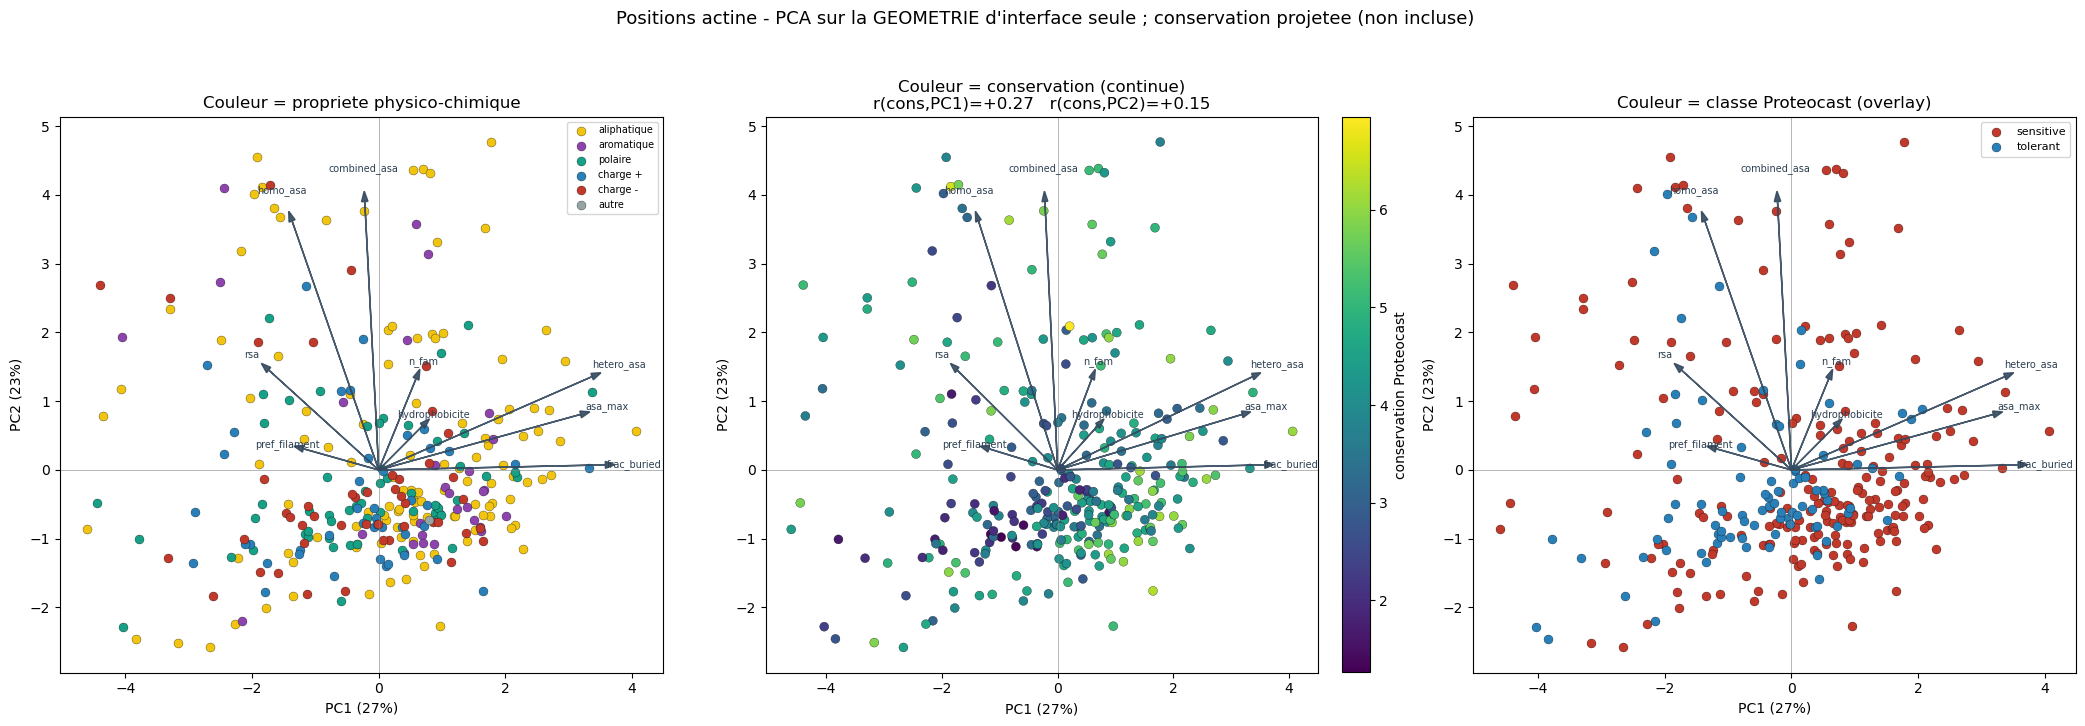

PCA structure seule (9 desc.) : PC1+PC2 = 27+23 = 50%
Conservation vs axes (NON circulaire) : r(PC1)=+0.27, r(PC2)=+0.15 -> lien faible structure d'interface <-> conservation
Sens biologique : si le lien etait fort, la geometrie d'interface 'expliquerait' la conservation ;
ici modere -> les positions sensibles ne se reduisent PAS a une signature structurale d'interface.


In [11]:
# === Biplot : PCA STRUCTURE seule (conservation NON incluse) + 3 colorations ===
# Retire conservation + frac_impactful des descripteurs pour eviter la circularite,
# puis projette la conservation en couleur (overlay) -> test reel structure -> conservation.
assert 'P' in dir(), "Lance d'abord la cellule precedente (qui construit P)."

# classification physico-chimique du residu canonique (EDITABLE : remplace par ta liste)
_PHYS={**dict.fromkeys('GAVLIPM','aliphatique'), **dict.fromkeys('FYW','aromatique'),
       **dict.fromkeys('STCNQ','polaire'), **dict.fromkeys('KRH','charge +'), **dict.fromkeys('DE','charge -')}
_PCOL={'aliphatique':'#f1c40f','aromatique':'#8e44ad','polaire':'#16a085','charge +':'#2980b9','charge -':'#c0392b','autre':'#95a5a6'}

struct=['n_fam','asa_max','hydrophobicite','rsa','homo_asa','hetero_asa','combined_asa','frac_buried','pref_filament']  # geometrie seule (conservation EXCLUE -> overlay)
Fs=P[struct].copy(); Fs=Fs.fillna(Fs.median(numeric_only=True))
_Xz=(Fs.values-Fs.values.mean(0))/(Fs.values.std(0)+1e-9)
_U,_S,_Vt=np.linalg.svd(_Xz-_Xz.mean(0),full_matrices=False); pcs=_U[:,:2]*_S[:2]; ev=(_S**2)/(_S**2).sum()*100
cor=np.array([[np.corrcoef(_Xz[:,j],pcs[:,k])[0,1] for k in range(2)] for j in range(Fs.shape[1])])

cons=P['conservation'].values.astype(float); _cf=np.nan_to_num(cons,nan=np.nanmedian(cons))
cls=P['residue_class'].fillna('?').values; phys=P['res'].map(lambda r:_PHYS.get(str(r),'autre')).values
_rc1=np.corrcoef(_cf,pcs[:,0])[0,1]; _rc2=np.corrcoef(_cf,pcs[:,1])[0,1]   # NON circulaire (cons hors PCA)

_f=0.85*np.abs(pcs).max()/np.abs(cor).max()
def _arrows(ax):
    for j,nm in enumerate(struct):
        ax.arrow(0,0,cor[j,0]*_f,cor[j,1]*_f,color='#34495e',head_width=.10,length_includes_head=True,lw=1.1,zorder=5,alpha=.9)
        ax.annotate(nm,(cor[j,0]*_f*1.08,cor[j,1]*_f*1.08),fontsize=7,color='#2c3e50',ha='center',va='center',zorder=6)
    ax.axhline(0,color='grey',lw=.4); ax.axvline(0,color='grey',lw=.4)
    ax.set_xlabel(f'PC1 ({ev[0]:.0f}%)'); ax.set_ylabel(f'PC2 ({ev[1]:.0f}%)')

from matplotlib.lines import Line2D
fig,axes=plt.subplots(1,3,figsize=(21,7))
# (A) propriete physico-chimique
for c in _PCOL:
    m=phys==c
    if m.any(): axes[0].scatter(pcs[m,0],pcs[m,1],c=_PCOL[c],s=42,edgecolor='k',lw=.2,label=c,zorder=2)
_arrows(axes[0]); axes[0].legend(fontsize=7,loc='best'); axes[0].set_title('Couleur = propriete physico-chimique')
# (B) conservation continue
sc=axes[1].scatter(pcs[:,0],pcs[:,1],c=cons,cmap='viridis',s=42,edgecolor='k',lw=.2,zorder=2)
_arrows(axes[1]); fig.colorbar(sc,ax=axes[1],label='conservation Proteocast',fraction=.046,pad=.04)
axes[1].set_title(f'Couleur = conservation (continue)\nr(cons,PC1)={_rc1:+.2f}   r(cons,PC2)={_rc2:+.2f}')
# (C) classe Proteocast (overlay, plus une entree de la PCA)
_ccol={'sensitive':'#c0392b','tolerant':'#2980b9'}
for k in ['sensitive','tolerant']:
    m=cls==k
    if m.any(): axes[2].scatter(pcs[m,0],pcs[m,1],c=_ccol[k],s=42,edgecolor='k',lw=.2,label=k,zorder=2)
_arrows(axes[2]); axes[2].legend(fontsize=8,loc='best'); axes[2].set_title('Couleur = classe Proteocast (overlay)')
plt.suptitle('Positions actine - PCA sur la GEOMETRIE d\'interface seule ; conservation projetee (non incluse)',y=1.03,fontsize=13)
plt.tight_layout(); plt.show()

print(f"PCA structure seule ({len(struct)} desc.) : PC1+PC2 = {ev[0]:.0f}+{ev[1]:.0f} = {ev[0]+ev[1]:.0f}%")
_lvl='faible' if max(abs(_rc1),abs(_rc2))<0.3 else 'modere'
print(f"Conservation vs axes (NON circulaire) : r(PC1)={_rc1:+.2f}, r(PC2)={_rc2:+.2f} -> lien {_lvl} structure d'interface <-> conservation")
print("Sens biologique : si le lien etait fort, la geometrie d'interface 'expliquerait' la conservation ;")
print("ici modere -> les positions sensibles ne se reduisent PAS a une signature structurale d'interface.")


## En fonction de quoi un résidu d'actine est-il conservé ? (analyse **supervisée**)

⚠️ La PCA répond à « comment les positions co-varient », **pas** à « qu'est-ce qui *cause* la conservation ». Pour ça, la conservation devient la **variable à expliquer (Y)** et les descripteurs structuraux les **prédicteurs (X)** → c'est une **régression / corrélation**, pas une ordination.

Deux niveaux de lecture :
- **Univarié** (gauche) : corrélation de Spearman conservation ↔ chaque descripteur → quel facteur s'associe le plus à la conservation.
- **Multivarié** (droite) : régression `conservation ~ tous les descripteurs` (coefficients standardisés + R²) → quel facteur prédit la conservation *une fois les autres pris en compte*.

**Focus de la question** : *une position en contact avec **plusieurs familles** d'ABP est-elle plus conservée qu'avec une **seule** ?* On donne la corrélation **brute**, **en contrôlant l'enfouissement (`rsa`)**, et le test 1-famille vs ≥2-familles — car les positions multi-familles sont des surfaces exposées, ce qui masque l'effet propre du nombre de familles. (`n_fam` = familles distinctes ; `n_fam_core` = uniquement celles enfouissant le résidu >25 % ASA.)

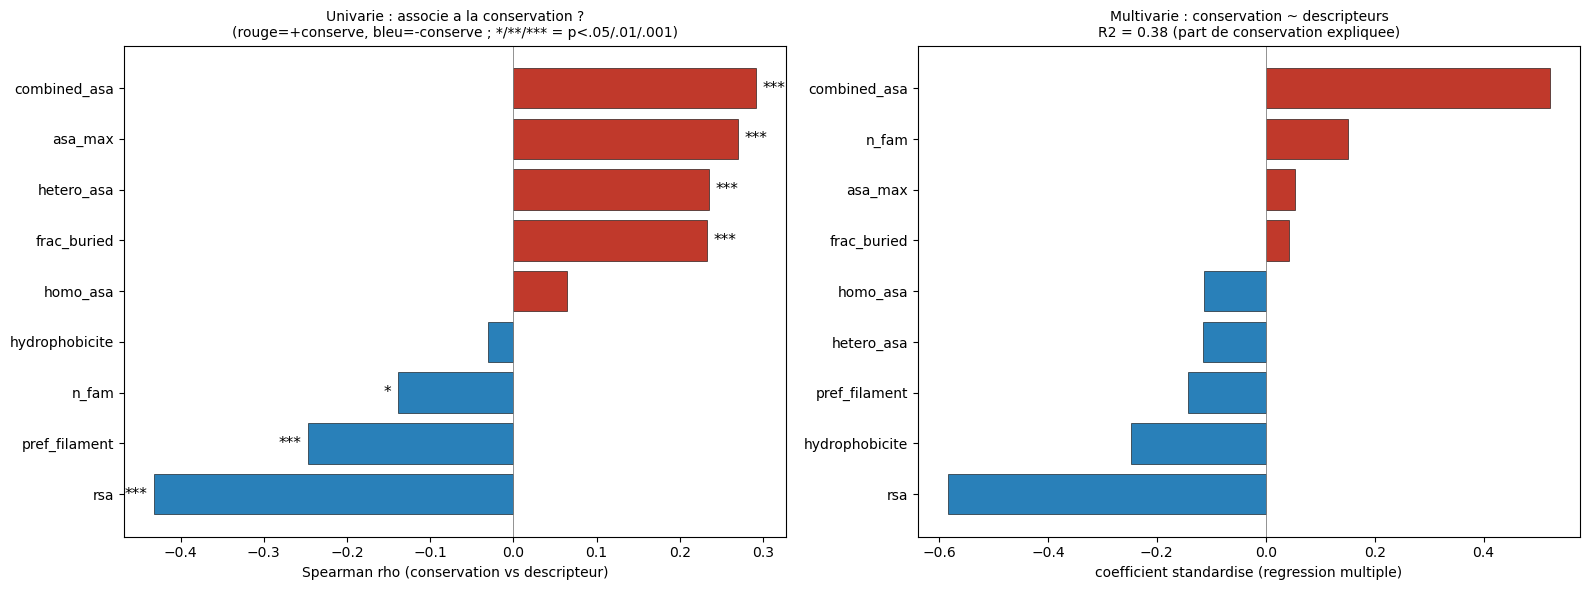

Modele complet : R2 = 0.38  sur 294 positions d'interface ABP

>>> Ta question : plus de FAMILLES d'ABP differentes (cluster sequence 40%) -> plus ou moins conserve ?
    brut                                : rho = -0.138  (legerement NEGATIF)
    a enfouissement (rsa) egal          : rho = +0.142  (le signe S'INVERSE)
    -> brut negatif car les positions multi-ABP sont des surfaces exposees (et l'exposition baisse la conservation) ;
       a exposition egale, plus d'ABP differents -> un peu PLUS conserve (patch fonctionnel = hub).

UNE seule famille (n=15) : conservation moy=4.45
PLUSIEURS familles (n=279) : conservation moy=4.02   Mann-Whitney p=1.83e-01

Conservation moyenne par tranche de nb de familles :
       mean  count
n_fam             
1      4.45     15
2-3    4.19     34
4-10   4.14    118
11+    3.86    127


In [12]:
# === Qu'est-ce qui determine la conservation d'une position d'actine ? (supervise) ===
# conservation = Y (a expliquer) ; descripteurs = X (predicteurs) -> REGRESSION, pas PCA.
from scipy.stats import spearmanr, mannwhitneyu
assert 'P' in dir(), "Lance d'abord la cellule pospca (construit P)."

_pred=['n_fam','asa_max','hydrophobicite','rsa','homo_asa','hetero_asa','combined_asa','frac_buried','pref_filament']
M=P[['conservation']+_pred].dropna(subset=['conservation']).copy()
M[_pred]=M[_pred].fillna(M[_pred].median())
y=M['conservation'].values

# (1) univarie : Spearman conservation vs chaque descripteur
uni=pd.DataFrame({'rho':[spearmanr(y,M[c])[0] for c in _pred],
                  'p':[spearmanr(y,M[c])[1] for c in _pred]}, index=_pred).sort_values('rho')

# (2) multivarie : regression standardisee conservation ~ tous les descripteurs
Xz=(M[_pred].values-M[_pred].values.mean(0))/(M[_pred].values.std(0)+1e-9)
yz=(y-y.mean())/(y.std()+1e-9); Xd=np.c_[np.ones(len(yz)),Xz]
beta=np.linalg.lstsq(Xd,yz,rcond=None)[0]; yhat=Xd@beta
R2=1-((yz-yhat)**2).sum()/((yz-yz.mean())**2).sum()
coef=pd.Series(beta[1:],index=_pred).sort_values()

# (3) focus n_abp : brut vs en controlant l'enfouissement (rsa)
def _resid(a,b):
    b=np.c_[np.ones(len(b)),b]; return a-b@np.linalg.lstsq(b,a,rcond=None)[0]
_rr=spearmanr(M['n_fam'],y)[0]; _mk=M['rsa'].notna().values
_rp=spearmanr(_resid(M['n_fam'].values[_mk],M['rsa'].values[_mk]),_resid(y[_mk],M['rsa'].values[_mk]))[0]

fig,(ax1,ax2)=plt.subplots(1,2,figsize=(16,6))
ax1.barh(uni.index,uni['rho'],color=['#c0392b' if v>0 else '#2980b9' for v in uni['rho']],edgecolor='k',lw=.4)
for i,(c,row) in enumerate(uni.iterrows()):
    st='***' if row['p']<1e-3 else '**' if row['p']<1e-2 else '*' if row['p']<5e-2 else ''
    ax1.text(row['rho']+(0.008 if row['rho']>=0 else -0.008),i,st,va='center',ha='left' if row['rho']>=0 else 'right',fontsize=11)
ax1.axvline(0,color='grey',lw=.6); ax1.set_xlabel("Spearman rho (conservation vs descripteur)")
ax1.set_title("Univarie : associe a la conservation ?\n(rouge=+conserve, bleu=-conserve ; */**/*** = p<.05/.01/.001)",fontsize=10)
ax2.barh(coef.index,coef.values,color=['#c0392b' if v>0 else '#2980b9' for v in coef.values],edgecolor='k',lw=.4)
ax2.axvline(0,color='grey',lw=.6); ax2.set_xlabel("coefficient standardise (regression multiple)")
ax2.set_title(f"Multivarie : conservation ~ descripteurs\nR2 = {R2:.2f} (part de conservation expliquee)",fontsize=10)
plt.tight_layout(); plt.show()

print(f"Modele complet : R2 = {R2:.2f}  sur {len(M)} positions d'interface ABP")
print("\n>>> Ta question : plus de FAMILLES d'ABP differentes (cluster sequence 40%) -> plus ou moins conserve ?")
print(f"    brut                                : rho = {_rr:+.3f}  (legerement NEGATIF)")
print(f"    a enfouissement (rsa) egal          : rho = {_rp:+.3f}  (le signe S'INVERSE)")
print("    -> brut negatif car les positions multi-ABP sont des surfaces exposees (et l'exposition baisse la conservation) ;")
print("       a exposition egale, plus d'ABP differents -> un peu PLUS conserve (patch fonctionnel = hub).")
# UNE seule famille vs PLUSIEURS familles (la question directe)
_one=M[M['n_fam']==1]['conservation']; _multi=M[M['n_fam']>=2]['conservation']
_u,_pu=mannwhitneyu(_one,_multi)
print(f"\nUNE seule famille (n={len(_one)}) : conservation moy={_one.mean():.2f}")
print(f"PLUSIEURS familles (n={len(_multi)}) : conservation moy={_multi.mean():.2f}   Mann-Whitney p={_pu:.2e}")
print("\nConservation moyenne par tranche de nb de familles :")
_b=pd.cut(M['n_fam'],[0,1,3,10,40],labels=['1','2-3','4-10','11+'])
print(M.groupby(_b,observed=True)['conservation'].agg(['mean','count']).round(2).to_string())


## PCA des interfaces (niveau cluster C70) — homo + hétéro

Ici **un point = un cluster d'interface C70** (et non un ABP). On inclut **toutes** les interfaces — actine-actine (**homo**, filament) ET actine-ABP (**hétéro**) — décrites par 7 descripteurs côté actine agrégés par cluster (conservation, hydrophobicité, charges +/−, aire d'interface, %H-bond, %pont salin).

Avantage vs PCA ABP : **pas d'agrégation par protéine** (chaque interface est sa propre observation), n plus grand, et on peut contraster **homo vs hétéro**. Le niveau **cluster C70** évite la pseudo-réplication (interactions quasi-dupliquées).

### Représentation : nombre de **familles** d'ABP en contact vs conservation

Visualisation directe de ta question. Deux définitions du « nombre de familles » :
- **`n_fam`** — toutes les familles d'ABP (cluster séquence 40 %) qui touchent la position ;
- **`n_fam_core`** — uniquement celles qui enfouissent le résidu au **cœur** de l'interface (**> 25 % ASA**), donc un vrai contact, pas un effleurement.

Pour chaque définition : conservation par tranche de nombre de familles (boxplots) + comparaison **1 famille vs ≥ 2**. Le 3ᵉ panel colore les points par `rsa` pour **montrer le confondant** : les positions multi-familles sont des surfaces exposées (jaunes), donc naturellement moins conservées.

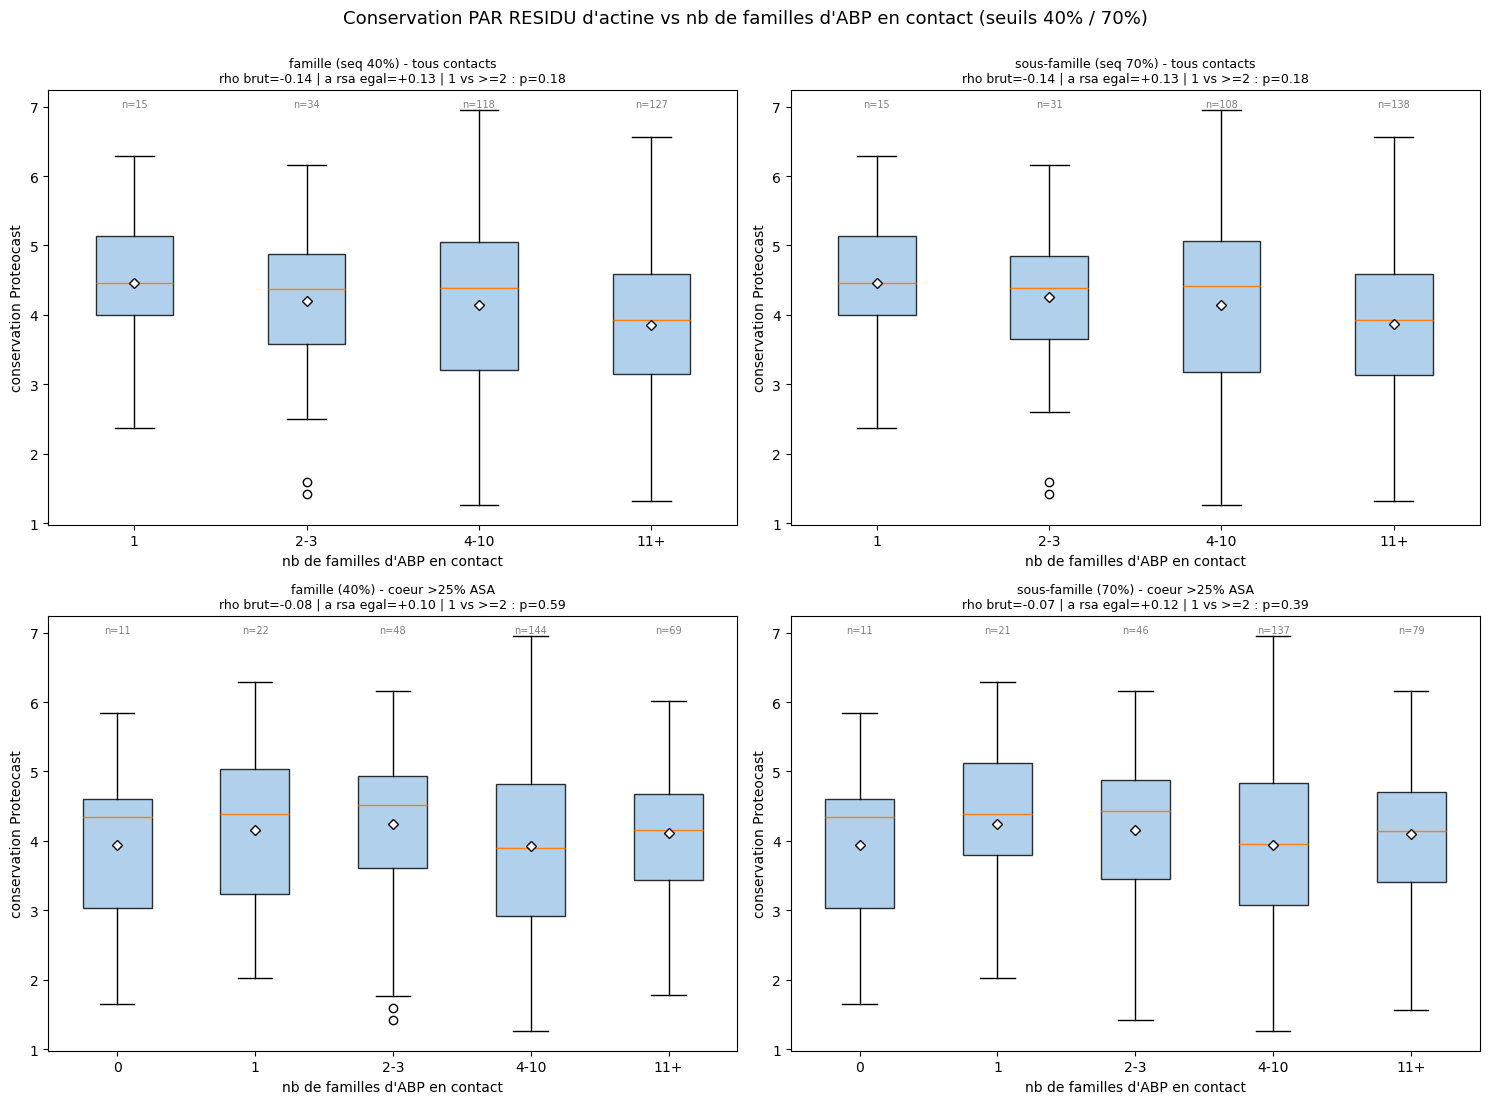

Synthese (1 individu = 1 residu/position d'actine, n=294) :
  n_fam        : 1 fam moy=4.45 (n=15) vs >=2 moy=4.02 (n=279) | MW p=0.18 | rho brut=-0.14 a rsa egal=+0.13
  n_fam70      : 1 fam moy=4.45 (n=15) vs >=2 moy=4.02 (n=279) | MW p=0.18 | rho brut=-0.14 a rsa egal=+0.13
  n_fam_core   : 1 fam moy=4.16 (n=22) vs >=2 moy=4.03 (n=261) | MW p=0.59 | rho brut=-0.08 a rsa egal=+0.10


  n_fam70_core : 1 fam moy=4.24 (n=21) vs >=2 moy=4.03 (n=262) | MW p=0.39 | rho brut=-0.07 a rsa egal=+0.12

Conclusion : meme a 70% (decoupage plus fin en sous-familles), pas d'effet net du nombre de familles sur la conservation ;
la legere tendance brute (multi-familles un peu moins conserve) est un artefact d'EXPOSITION (positions de surface).


In [13]:
# === Representation : nb de FAMILLES d'ABP en contact vs conservation (PAR RESIDU) ===
# 2 seuils de cluster de sequence (famille 40% / sous-famille 70%) x 2 definitions (tous contacts / coeur >25% ASA)
from scipy.stats import spearmanr, mannwhitneyu
assert 'P' in dir(), "Lance d'abord la cellule pospca (construit P)."
def _resid(a,b):
    b=np.c_[np.ones(len(b)),b]; return a-b@np.linalg.lstsq(b,a,rcond=None)[0]

_variants=[('n_fam',"famille (seq 40%) - tous contacts"),
           ('n_fam70',"sous-famille (seq 70%) - tous contacts"),
           ('n_fam_core',"famille (40%) - coeur >25% ASA"),
           ('n_fam70_core',"sous-famille (70%) - coeur >25% ASA")]
fig,axes=plt.subplots(2,2,figsize=(15,11)); axes=axes.ravel()
for ax,(col,ttl) in zip(axes,_variants):
    sub=P[['conservation',col,'rsa']].dropna(subset=['conservation',col]).copy()
    hasz=(sub[col]==0).any()
    _bins=[-1,0,1,3,10,40] if hasz else [0,1,3,10,40]
    _labs=['0','1','2-3','4-10','11+'] if hasz else ['1','2-3','4-10','11+']
    sub['_b']=pd.cut(sub[col],_bins,labels=_labs)
    cats=[l for l in _labs if (sub['_b']==l).any()]
    grp=[sub[sub['_b']==l]['conservation'].values for l in cats]
    bp=ax.boxplot(grp,labels=cats,patch_artist=True,showmeans=True,meanprops=dict(marker='D',mfc='white',mec='k',ms=5))
    for pt in bp['boxes']: pt.set_facecolor('#9ec5e8'); pt.set_alpha(.8)
    for i,g in enumerate(grp): ax.text(i+1,7.0,f'n={len(g)}',ha='center',fontsize=7,color='grey')
    one=sub[sub[col]==1]['conservation']; multi=sub[sub[col]>=2]['conservation']
    pu=mannwhitneyu(one,multi)[1] if len(one) and len(multi) else np.nan
    r=spearmanr(sub[col],sub['conservation'])[0]
    mm=sub.dropna(subset=['rsa']); rp=spearmanr(_resid(mm[col].values,mm['rsa'].values),_resid(mm['conservation'].values,mm['rsa'].values))[0]
    ax.set_xlabel("nb de familles d'ABP en contact"); ax.set_ylabel('conservation Proteocast')
    ax.set_title(f'{ttl}\nrho brut={r:+.2f} | a rsa egal={rp:+.2f} | 1 vs >=2 : p={pu:.2f}',fontsize=9)
plt.suptitle("Conservation PAR RESIDU d'actine vs nb de familles d'ABP en contact (seuils 40% / 70%)",y=1.0,fontsize=13)
plt.tight_layout(); plt.show()

print("Synthese (1 individu = 1 residu/position d'actine, n=294) :")
for col,ttl in _variants:
    sub=P[['conservation',col,'rsa']].dropna(subset=['conservation',col])
    one=sub[sub[col]==1]['conservation']; multi=sub[sub[col]>=2]['conservation']
    r=spearmanr(sub[col],sub['conservation'])[0]; mm=sub.dropna(subset=['rsa'])
    rp=spearmanr(_resid(mm[col].values,mm['rsa'].values),_resid(mm['conservation'].values,mm['rsa'].values))[0]
    pu=mannwhitneyu(one,multi)[1]
    print(f"  {col:13s}: 1 fam moy={one.mean():.2f} (n={len(one)}) vs >=2 moy={multi.mean():.2f} (n={len(multi)}) | MW p={pu:.2f} | rho brut={r:+.2f} a rsa egal={rp:+.2f}")
print("\nConclusion : meme a 70% (decoupage plus fin en sous-familles), pas d'effet net du nombre de familles sur la conservation ;")
print("la legere tendance brute (multi-familles un peu moins conserve) est un artefact d'EXPOSITION (positions de surface).")


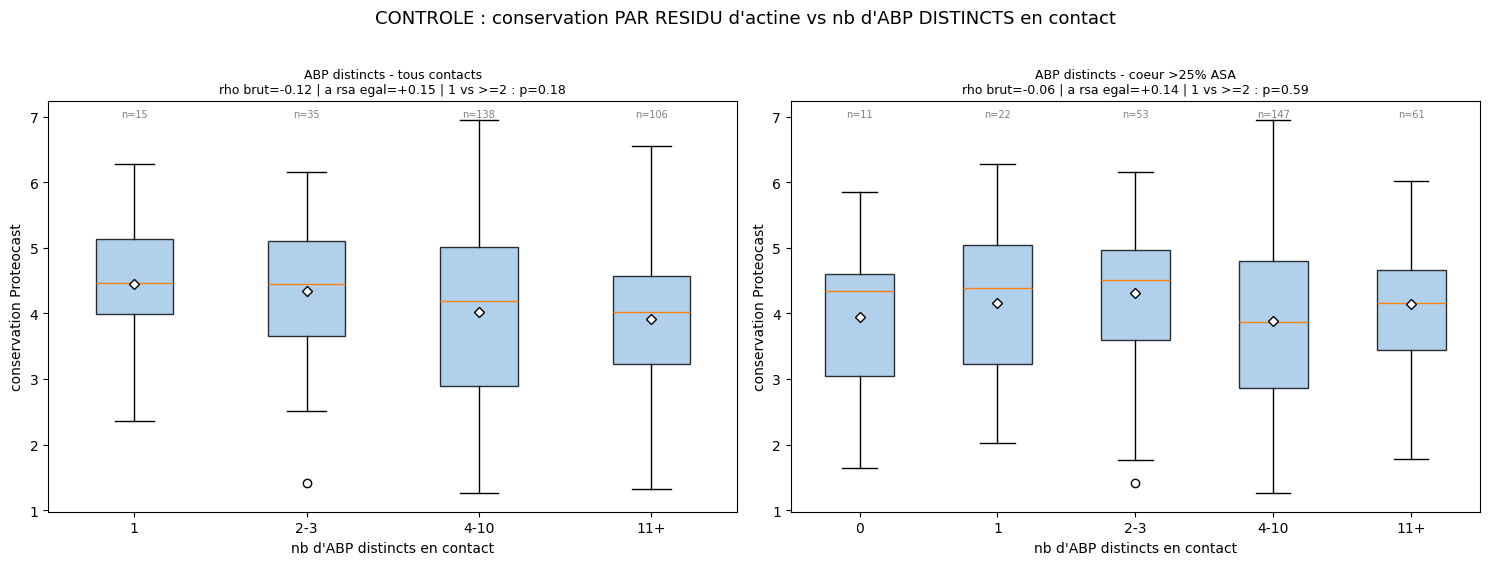

Synthese ABP distincts (1 individu = 1 residu/position d'actine) :
  n_abp      : 1 ABP moy=4.45 (n=15) vs >=2 moy=4.02 (n=279) | MW p=0.18 | rho brut=-0.12 a rsa egal=+0.15
  n_abp_core : 1 ABP moy=4.16 (n=22) vs >=2 moy=4.03 (n=261) | MW p=0.59 | rho brut=-0.06 a rsa egal=+0.14

Comparaison familles vs ABP distincts : si rho 'a rsa egal' reste proche de 0 et MW p non-signif,
le resultat est ROBUSTE au mode de comptage (familles OU proteines individuelles).


In [14]:
# === CONTROLE : nb d'ABP DISTINCTS (proteines individuelles) au lieu des familles ===
# Meme analyse que ci-dessus mais on compte les ABP individuels (colonne 'abp'),
# pas les familles de sequence. Question : retrouve-t-on le meme resultat ?
from scipy.stats import spearmanr, mannwhitneyu
assert '_d' in dir() and 'P' in dir(), "Lance d'abord la cellule qui construit _d / P."

# nb d'ABP distincts par position canonique : tous contacts + coeur (>25% ASA)
_nabp      = _d.dropna(subset=['abp']).groupby('canon')['abp'].nunique()
_nabp_core = _d[_d['pct']>25].dropna(subset=['abp']).groupby('canon')['abp'].nunique()
A = P[['conservation','rsa']].copy()
A['n_abp']      = _nabp.reindex(A.index)
A['n_abp_core'] = _nabp_core.reindex(A.index).fillna(0)

_variants_abp=[('n_abp',      "ABP distincts - tous contacts"),
               ('n_abp_core', "ABP distincts - coeur >25% ASA")]
fig,axes=plt.subplots(1,2,figsize=(15,5.5)); axes=axes.ravel()
for ax,(col,ttl) in zip(axes,_variants_abp):
    sub=A[['conservation',col,'rsa']].dropna(subset=['conservation',col]).copy()
    hasz=(sub[col]==0).any()
    _bins=[-1,0,1,3,10,40] if hasz else [0,1,3,10,40]
    _labs=['0','1','2-3','4-10','11+'] if hasz else ['1','2-3','4-10','11+']
    sub['_b']=pd.cut(sub[col],_bins,labels=_labs)
    cats=[l for l in _labs if (sub['_b']==l).any()]
    grp=[sub[sub['_b']==l]['conservation'].values for l in cats]
    bp=ax.boxplot(grp,labels=cats,patch_artist=True,showmeans=True,meanprops=dict(marker='D',mfc='white',mec='k',ms=5))
    for pt in bp['boxes']: pt.set_facecolor('#9ec5e8'); pt.set_alpha(.8)
    for i,g in enumerate(grp): ax.text(i+1,7.0,f'n={len(g)}',ha='center',fontsize=7,color='grey')
    one=sub[sub[col]==1]['conservation']; multi=sub[sub[col]>=2]['conservation']
    pu=mannwhitneyu(one,multi)[1] if len(one) and len(multi) else np.nan
    r=spearmanr(sub[col],sub['conservation'])[0]
    mm=sub.dropna(subset=['rsa']); rp=spearmanr(_resid(mm[col].values,mm['rsa'].values),_resid(mm['conservation'].values,mm['rsa'].values))[0]
    ax.set_xlabel("nb d'ABP distincts en contact"); ax.set_ylabel('conservation Proteocast')
    ax.set_title(f'{ttl}\nrho brut={r:+.2f} | a rsa egal={rp:+.2f} | 1 vs >=2 : p={pu:.2f}',fontsize=9)
plt.suptitle("CONTROLE : conservation PAR RESIDU d'actine vs nb d'ABP DISTINCTS en contact",y=1.02,fontsize=13)
plt.tight_layout(); plt.show()

print("Synthese ABP distincts (1 individu = 1 residu/position d'actine) :")
for col,ttl in _variants_abp:
    sub=A[['conservation',col,'rsa']].dropna(subset=['conservation',col])
    one=sub[sub[col]==1]['conservation']; multi=sub[sub[col]>=2]['conservation']
    r=spearmanr(sub[col],sub['conservation'])[0]; mm=sub.dropna(subset=['rsa'])
    rp=spearmanr(_resid(mm[col].values,mm['rsa'].values),_resid(mm['conservation'].values,mm['rsa'].values))[0]
    pu=mannwhitneyu(one,multi)[1]
    print(f"  {col:11s}: 1 ABP moy={one.mean():.2f} (n={len(one)}) vs >=2 moy={multi.mean():.2f} (n={len(multi)}) | MW p={pu:.2f} | rho brut={r:+.2f} a rsa egal={rp:+.2f}")
print("\nComparaison familles vs ABP distincts : si rho 'a rsa egal' reste proche de 0 et MW p non-signif,")
print("le resultat est ROBUSTE au mode de comptage (familles OU proteines individuelles).")


222 clusters d'interface C70 (19 homo / 203 hetero)
Variance PC1+PC2 = 25% + 17% = 42%
Silhouette separation homo vs hetero = -0.081  (~0 -> interfaces homo non distinctes des hetero)


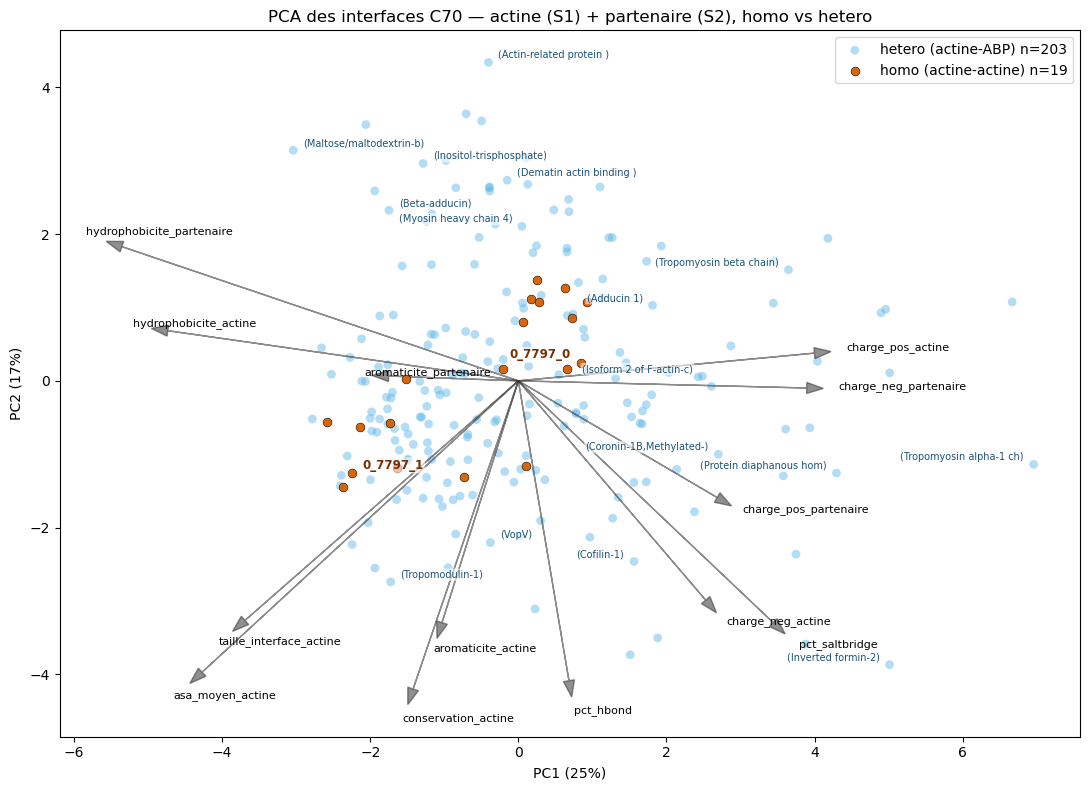

In [15]:
# === PCA des interfaces au niveau cluster C70 (homo + hetero) ===
import warnings; warnings.filterwarnings('ignore')
from pathlib import Path as _P
from scipy.spatial.distance import pdist, squareform
_R = _P('..') if _P('../data').exists() else _P('.')
_df3=pd.read_csv(_R/'data/filtered/details/3.interface_residues.csv')
_df3['pct']=pd.to_numeric(_df3['buried_ASA_percent'].astype(str).str.replace('%','',regex=False),errors='coerce')
_df3['a2']=pd.to_numeric(_df3['buried_ASA_Å²'].astype(str).str.replace('<0.1','0.05',regex=False),errors='coerce')
_df3['canon']=pd.to_numeric(_df3['residue_number_canon_mafft'],errors='coerce')
_df3=_df3[_df3.canon.notna()&_df3.pct.notna()].copy()
_di=pd.read_csv(_R/'data/filtered/details/1.interactions.csv')
_da=pd.read_csv(_R/'data/filtered/filtered_all_data.csv',low_memory=False)
_m=_di.merge(_da[['subunit_1','subunit_2','subunit_2_title','s2_actine','cluster_data_70']].drop_duplicates(),
             left_on=['chain_A_id','chain_B_id'],right_on=['subunit_1','subunit_2'],how='left').drop_duplicates('interaction_id')
_m=_m.dropna(subset=['cluster_data_70'])
_m['homo']=_m['s2_actine'].fillna(False).astype(bool)
_m['abp_title']=_m['subunit_2_title'].fillna('?').astype(str).str.replace(r'\s*\(.*?\)','',regex=True).str.strip().str[:22]
_clu2abp=_m[~_m['homo']].groupby('cluster_data_70')['abp_title'].agg(lambda x:x.value_counts().index[0])
_m['interface_area']=pd.to_numeric(_m['interface_area'].astype(str).str.replace('Å²','',regex=False).str.strip(),errors='coerce')
for _c in ['num_hbonds','num_salt_bridges','num_contacts']: _m[_c]=pd.to_numeric(_m[_c],errors='coerce')
_imap=_m.set_index('interaction_id'); _chA=_imap['chain_A_id'].str.lower(); _clu=_imap['cluster_data_70']
_d=_df3[_df3.interaction_id.isin(set(_m.interaction_id))].copy()
_d['_a']=_d.interaction_id.map(_chA); _d=_d[_d.chain.str.lower()==_d._a].copy()   # cote actine = chaine A (subunit_1)
_d['clu']=_d.interaction_id.map(_clu); _d['canon']=_d.canon.astype(int)
_cdf=pd.read_csv(_R/'data/proteocast/conservation_vs_asa_per_position.csv'); _cons=dict(zip(_cdf['canon'].astype(int),_cdf['conservation']))
_KD={'A':1.8,'R':-4.5,'N':-3.5,'D':-3.5,'C':2.5,'Q':-3.5,'E':-3.5,'G':-0.4,'H':-3.2,'I':4.5,'L':3.8,'K':-3.9,'M':1.9,'F':2.8,'P':-1.6,'S':-0.8,'T':-0.7,'W':-0.9,'Y':-1.3,'V':4.2}
def _md(s): mm=s.mode(); return mm.iloc[0] if len(mm) else None
_po=_d.groupby(['clu','canon']).agg(w=('pct','mean'),res=('residue_name',_md)).reset_index()
_po['kd']=_po['res'].map(lambda r:_KD.get(str(r),0.0)); _po['cons']=_po['canon'].map(lambda c:_cons.get(int(c),np.nan))
_po['ispos']=_po['res'].isin({'R','K'}).astype(float); _po['isneg']=_po['res'].isin({'D','E'}).astype(float); _po['isaro']=_po['res'].isin({'F','Y','W'}).astype(float)
def _wmi(g,c):
    w=g['w'].values; x=g[c].values; mk=~np.isnan(x)
    return (w[mk]*x[mk]).sum()/w[mk].sum() if w[mk].sum()>0 else np.nan
Fi=_po.groupby('clu').apply(lambda g:pd.Series({'conservation_actine':_wmi(g,'cons'),'hydrophobicite_actine':_wmi(g,'kd'),
    'charge_pos_actine':_wmi(g,'ispos'),'charge_neg_actine':_wmi(g,'isneg'),'aromaticite_actine':_wmi(g,'isaro'),'asa_moyen_actine':_wmi(g,'w')}))
Fi['n_residus']=_d.groupby('interaction_id').size().groupby(_clu).mean()
_ag=_m.groupby('cluster_data_70').agg(hb=('num_hbonds','sum'),sb=('num_salt_bridges','sum'),
    ct=('num_contacts','sum'),n=('interaction_id','nunique'),homo=('homo','mean'))
Fi['taille_interface_actine']=_d.groupby('interaction_id')['a2'].sum().groupby(_clu).mean()
Fi=Fi.join(_ag[['homo']])
_cc=pd.read_csv(_R/'data/filtered/details/4.inter-residue_contacts.csv'); _CHG={'R':1,'K':1,'D':-1,'E':-1}
_cc=_cc[_cc.interaction_id.isin(set(_m.interaction_id))].copy(); _cc['_clu']=_cc.interaction_id.map(_clu)
_cc['charge_compl']=-(_cc['residue_A_name'].map(lambda r:_CHG.get(str(r),0))*_cc['residue_B_name'].map(lambda r:_CHG.get(str(r),0)))
Fi['charge_compl']=_cc.groupby('_clu')['charge_compl'].mean()
Fi['pct_hbond']=100*_ag['hb']/_ag['ct']; Fi['pct_saltbridge']=100*_ag['sb']/_ag['ct']
# --- descripteurs cote PARTENAIRE (chaine B = S2 ; actine pour homo, ABP pour hetero) ---
_chB=_imap['chain_B_id'].str.lower()
_db=_df3[_df3.interaction_id.isin(set(_m.interaction_id))].copy()
_db['_b']=_db.interaction_id.map(_chB); _db=_db[_db.chain.str.lower()==_db._b].copy()
_db['clu']=_db.interaction_id.map(_clu)
_db['kd']=_db['residue_name'].map(lambda r:_KD.get(str(r),0.0))
_db['ispos']=_db['residue_name'].isin({'R','K'}).astype(float)
_db['isneg']=_db['residue_name'].isin({'D','E'}).astype(float)
_db['isaro']=_db['residue_name'].isin({'F','Y','W'}).astype(float)
def _wmb(g,col):
    w=g['pct'].values; x=g[col].values; mk=~np.isnan(x)
    return (w[mk]*x[mk]).sum()/w[mk].sum() if w[mk].sum()>0 else np.nan
Fb=_db.groupby('clu').apply(lambda g:pd.Series({'hydrophobicite_partenaire':_wmb(g,'kd'),
    'charge_pos_partenaire':_wmb(g,'ispos'),'charge_neg_partenaire':_wmb(g,'isneg'),'aromaticite_partenaire':_wmb(g,'isaro'),'asa_moyen_partenaire':g['pct'].mean()}))
Fi=Fi.join(Fb)
_featI=['conservation_actine','hydrophobicite_actine','charge_pos_actine','charge_neg_actine','aromaticite_actine','taille_interface_actine','asa_moyen_actine','pct_hbond','pct_saltbridge','hydrophobicite_partenaire','charge_pos_partenaire','charge_neg_partenaire','aromaticite_partenaire']
Fi=Fi.dropna(subset=_featI); _homo=Fi['homo']>0.5
print(f"{len(Fi)} clusters d'interface C70 ({int(_homo.sum())} homo / {int((~_homo).sum())} hetero)")

Xi=Fi[_featI].values.astype(float); Xzi=(Xi-Xi.mean(0))/(Xi.std(0)+1e-9)
Xci=Xzi-Xzi.mean(0); Ui,Si,Vti=np.linalg.svd(Xci,full_matrices=False); pcsi=Ui[:,:2]*Si[:2]; evi=(Si**2)/(Si**2).sum()*100
print(f"Variance PC1+PC2 = {evi[0]:.0f}% + {evi[1]:.0f}% = {evi[0]+evi[1]:.0f}%")
_Di=squareform(pdist(Xzi)); _lab=_homo.values.astype(int)
def _sili(D,lab):
    n=len(lab);s=np.zeros(n)
    for i in range(n):
        sm=(lab==lab[i]).copy();sm[i]=False
        a=D[i,sm].mean() if sm.any() else 0; b=min((D[i,lab==c].mean() for c in set(lab) if c!=lab[i]),default=0)
        s[i]=0 if max(a,b)==0 else (b-a)/max(a,b)
    return s.mean()
print(f"Silhouette separation homo vs hetero = {_sili(_Di,_lab):.3f}  (~0 -> interfaces homo non distinctes des hetero)")

_corI=np.array([[np.corrcoef(Xzi[:,j],pcsi[:,k])[0,1] for k in range(2)] for j in range(len(_featI))])
# palette daltonien-friendly (Okabe-Ito) : hetero=bleu, homo=vermillon
_chet='#56B4E9'; _chomo='#D55E00'
fig,ax=plt.subplots(figsize=(11,8))
# hetero dessous (transparent), homo par-dessus (contour) pour ne plus les masquer
ax.scatter(pcsi[~_homo.values,0],pcsi[~_homo.values,1],c=_chet,s=40,alpha=.45,edgecolor='none',label=f'hetero (actine-ABP) n={int((~_homo).sum())}',zorder=2)
ax.scatter(pcsi[_homo.values,0],pcsi[_homo.values,1],c=_chomo,s=40,alpha=.95,edgecolor='k',lw=.4,label=f'homo (actine-actine) n={int(_homo.sum())}',zorder=4)
_fI=0.8*np.abs(pcsi).max()/np.abs(_corI).max()
for j,nm in enumerate(_featI):
    ax.arrow(0,0,_corI[j,0]*_fI,_corI[j,1]*_fI,color='#333333',head_width=.15,length_includes_head=True,lw=1,alpha=.55,zorder=3)
    ax.annotate(nm,(_corI[j,0]*_fI*1.05,_corI[j,1]*_fI*1.05),fontsize=8,zorder=5)
# --- labels anti-chevauchement : interfaces homo (id cluster) + ABP outsiders distincts ---
_xr=pcsi[:,0].max()-pcsi[:,0].min(); _yr=pcsi[:,1].max()-pcsi[:,1].min()
_placed=[(_corI[j,0]*_fI*1.05,_corI[j,1]*_fI*1.05) for j in range(len(_featI))]  # reserve les labels de fleches
def _free(x,y,mx=0.085,my=0.05):
    return all(not(abs(x-px)<mx*_xr and abs(y-py)<my*_yr) for px,py in _placed)
def _put(i,txt,color,weight='normal',fs=7):
    x,y=pcsi[i,0],pcsi[i,1]
    if not _free(x,y): return False
    _placed.append((x,y)); sd=-1 if x>0 else 1
    ax.annotate(txt,(x,y),fontsize=fs,fontweight=weight,color=color,zorder=7,ha='right' if sd<0 else 'left',
                xytext=(7*sd,3),textcoords='offset points',
                bbox=dict(boxstyle='round,pad=0.12',fc='white',ec='none',alpha=0.6))
    return True
_npc=_ag['n'].reindex(Fi.index).values.astype(float)
_ih=np.where(_homo.values)[0]; _it=np.where(~_homo.values)[0]
for i in _ih[np.argsort(-_npc[_ih])][:2]:               # 2 plus grosses interfaces homo
    _put(i,str(Fi.index[i]),'#7a2e00','bold',8.5)
_dist=np.hypot(pcsi[:,0],pcsi[:,1]); _seen=set()        # ABP outsiders distincts, sans chevauchement
for i in _it[np.argsort(-_dist[_it])]:
    _ab=_clu2abp.get(Fi.index[i],'?')
    if _ab in _seen: continue
    if _put(i,f'({_ab})','#1a5276'): _seen.add(_ab)
    if len(_seen)>=16: break
ax.set_xlabel(f'PC1 ({evi[0]:.0f}%)'); ax.set_ylabel(f'PC2 ({evi[1]:.0f}%)'); ax.legend(loc='best')
ax.set_title('PCA des interfaces C70 — actine (S1) + partenaire (S2), homo vs hetero')
plt.tight_layout(); plt.show()

### Variante visuelle : même PCA, points colorés par conservation côté actine
Mêmes coordonnées que le PCA ci-dessus, mais la couleur = conservation de l'actine (vert = plus conservé). Les ronds noirs = interfaces filament (homo). On voit que le dégradé suit PC2 (vertical) et que les ronds noirs tombent dans la zone conservée.

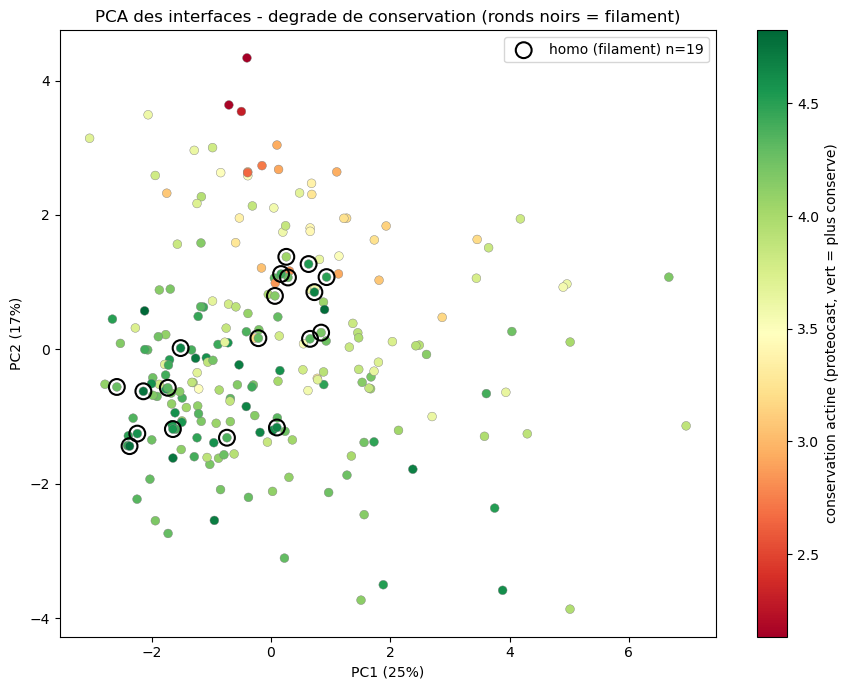

In [16]:
# === Variante : meme PCA, points colores par conservation cote actine ===
_cval=Fi['conservation_actine'].values
fig,ax=plt.subplots(figsize=(9,7))
_sc=ax.scatter(pcsi[:,0],pcsi[:,1],c=_cval,cmap='RdYlGn',s=40,edgecolor='grey',linewidth=.3)
ax.scatter(pcsi[_homo.values,0],pcsi[_homo.values,1],facecolor='none',edgecolor='k',s=130,linewidth=1.5,label='homo (filament) n=%d'%int(_homo.sum()))
plt.colorbar(_sc,label='conservation actine (proteocast, vert = plus conserve)')
ax.set_xlabel('PC1 (%.0f%%)'%evi[0]); ax.set_ylabel('PC2 (%.0f%%)'%evi[1]); ax.legend(loc='best')
ax.set_title('PCA des interfaces - degrade de conservation (ronds noirs = filament)')
plt.tight_layout(); plt.show()

### Variante supervisée : axe LDA construit *pour* séparer filament vs ABP
Contrairement au PCA (qui maximise la variance), l'analyse discriminante (LDA) cherche l'axe qui **sépare au mieux** les deux groupes. La projection des points sur cet axe rend la différence visible ; les poids imprimés indiquent quelle variable porte la séparation.

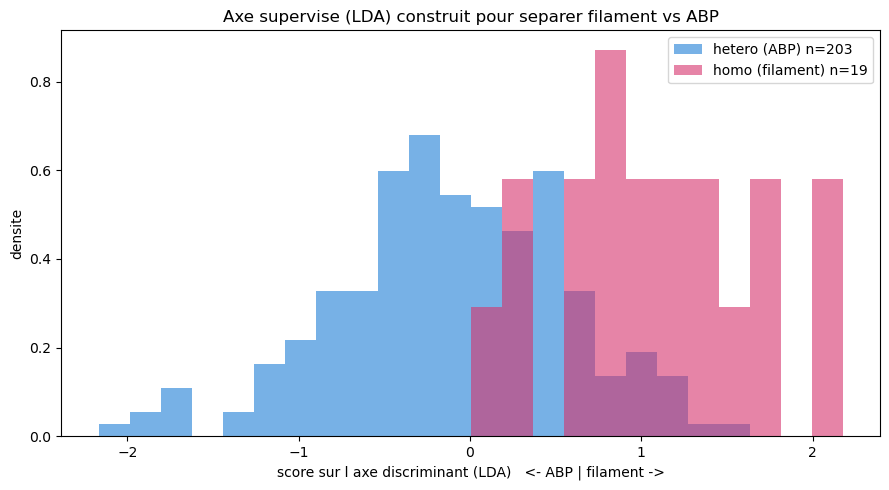

Poids des variables dans l axe LDA (|poids| decroissant, + = pousse vers filament) :
  conservation_actine      +0.68
  asa_moyen_actine         -0.57
  charge_pos_partenaire    -0.29
  aromaticite_actine       -0.17
  charge_neg_actine        +0.17
  charge_pos_actine        -0.13
  hydrophobicite_partenaire +0.12
  hydrophobicite_actine    +0.11
  charge_neg_partenaire    -0.10
  aromaticite_partenaire   -0.09
  taille_interface_actine  +0.07
  pct_saltbridge           -0.03
  pct_hbond                +0.00


In [17]:
# === Variante supervisee : axe LDA construit pour separer homo vs hetero ===
_y=_homo.values.astype(int); _X=Xzi
_mu1=_X[_y==1].mean(0); _mu0=_X[_y==0].mean(0)
_Sw=(np.cov(_X[_y==1].T)*(np.sum(_y==1)-1)+np.cov(_X[_y==0].T)*(np.sum(_y==0)-1))/(len(_y)-2)
_w=np.linalg.solve(_Sw+1e-6*np.eye(_X.shape[1]),_mu1-_mu0); _w/=np.linalg.norm(_w)
_proj=_X@_w
if _proj[_y==1].mean()<_proj[_y==0].mean(): _w=-_w; _proj=-_proj
fig,ax=plt.subplots(figsize=(9,5))
_b=np.linspace(_proj.min(),_proj.max(),25)
ax.hist(_proj[_y==0],_b,alpha=.6,color='#1c7ed6',density=True,label='hetero (ABP) n=%d'%int((_y==0).sum()))
ax.hist(_proj[_y==1],_b,alpha=.6,color='#d6336c',density=True,label='homo (filament) n=%d'%int((_y==1).sum()))
ax.set_xlabel('score sur l axe discriminant (LDA)   <- ABP | filament ->'); ax.set_ylabel('densite')
ax.legend(); ax.set_title('Axe supervise (LDA) construit pour separer filament vs ABP')
plt.tight_layout(); plt.show()
print('Poids des variables dans l axe LDA (|poids| decroissant, + = pousse vers filament) :')
for j in np.argsort(-np.abs(_w)): print('  %-24s %+.2f'%(_featI[j],_w[j]))

### Test statistique homo (filament) vs hétéro (ABP) sur les descripteurs d'interface
Le PCA montre une silhouette ≈ 0 (pas de séparation *globale*). Ce test dit **quelle variable prise individuellement** diffère entre interfaces filament et interfaces ABP : Mann-Whitney U par variable, p-value corrigée Holm-Bonferroni, taille d'effet rank-biserial (>0 = plus élevé côté filament).

                 variable  homo_med  hetero_med  effet_rb      p  p_holm signif
      conservation_actine    4.4151      4.0380    0.6489 0.0000  0.0000    ***
    charge_pos_partenaire    0.1189      0.1543   -0.3000 0.0309  0.3702     ns
hydrophobicite_partenaire   -0.4439     -0.7296    0.2699 0.0521  0.5731     ns
        charge_neg_actine    0.1636      0.1260    0.2595 0.0618  0.6176     ns
    hydrophobicite_actine   -0.3539     -0.5622    0.2092 0.1323  1.0000     ns
        charge_pos_actine    0.0869      0.0989   -0.1942 0.1623  1.0000     ns
    charge_neg_partenaire    0.1259      0.1019    0.1646 0.2361  1.0000     ns
         asa_moyen_actine   46.6188     58.1883   -0.1600 0.2500  1.0000     ns
  taille_interface_actine  527.0534    506.5667    0.1283 0.3562  1.0000     ns
           pct_saltbridge    0.7463      1.4085   -0.1226 0.3632  1.0000     ns
       aromaticite_actine    0.0210      0.0874   -0.1177 0.3945  1.0000     ns
                pct_hbond    5.1948     

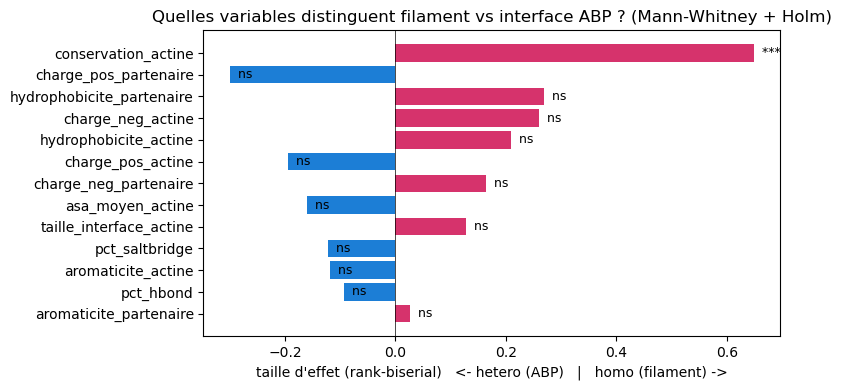

In [18]:
# === Test statistique : interfaces homo (filament) vs hétéro (ABP) ===
from scipy.stats import mannwhitneyu
_res=[]
for _f in _featI:
    _hh=Fi.loc[_homo,_f].dropna(); _tt=Fi.loc[~_homo,_f].dropna()
    _U,_p=mannwhitneyu(_hh,_tt,alternative='two-sided')
    _rb=2*(_U/(len(_hh)*len(_tt)))-1   # >0 : homo (filament) plus eleve
    _res.append({'variable':_f,'homo_med':_hh.median(),'hetero_med':_tt.median(),'effet_rb':_rb,'p':_p})
_st=pd.DataFrame(_res).sort_values('p').reset_index(drop=True)
_mn=len(_st)
_st['p_holm']=np.maximum.accumulate(np.minimum(1.0,_st['p'].values*(_mn-np.arange(_mn))))
_st['signif']=_st['p_holm'].map(lambda p:'***' if p<.001 else '**' if p<.01 else '*' if p<.05 else 'ns')
print(_st.round(4).to_string(index=False))
fig,ax=plt.subplots(figsize=(8,4))
_cols=['#d6336c' if v>0 else '#1c7ed6' for v in _st['effet_rb']]
ax.barh(_st['variable'],_st['effet_rb'],color=_cols)
for _i,(_,_r) in enumerate(_st.iterrows()): ax.text(_r['effet_rb'],_i,'  '+_r['signif'],va='center',fontsize=9)
ax.axvline(0,color='k',lw=.5); ax.invert_yaxis()
ax.set_xlabel('taille d\'effet (rank-biserial)   <- hetero (ABP)   |   homo (filament) ->')
ax.set_title('Quelles variables distinguent filament vs interface ABP ? (Mann-Whitney + Holm)')
plt.tight_layout(); plt.show()

### Conservation de l'actine selon le rôle d'interface (ABP vs filament vs reste)
À partir de `conservation_vs_asa_per_position.csv` (drapeaux `at_homo` / `at_hetero` / `at_interface`). Les positions d'actine contactées par les ABP sont-elles plus conservées que celles du filament, ou que la surface non-interface ? Score : **plus élevé = plus conservé**.

Score conservation : plus eleve = position plus conservee (sensible aux mutations)
Kruskal-Wallis global : H=27.9, p=3.90e-06
                 count  median   mean
groupe                               
non-interface       73   4.840  4.802
homo (filament)      7   5.007  5.134
hetero (ABP)       165   4.184  4.041
homo+hetero        130   4.140  4.036

Comparaisons vs non-interface (Mann-Whitney) :
  homo (filament)  p=5.04e-01   (mediane 5.01 vs 4.84)
  hetero (ABP)     p=7.20e-06   (mediane 4.18 vs 4.84)
  homo+hetero      p=1.02e-05   (mediane 4.14 vs 4.84)


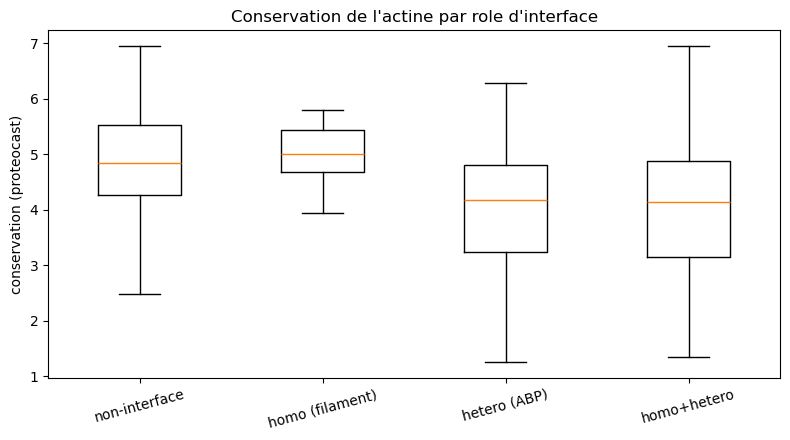

In [19]:
# === Conservation des positions actine selon le role d'interface ===
from scipy.stats import kruskal, mannwhitneyu
_cv=pd.read_csv(_R/'data/proteocast/conservation_vs_asa_per_position.csv')
for _c in ['at_homo','at_hetero','at_interface']: _cv[_c]=_cv[_c].astype(bool)
def _grp(r):
    if not r['at_interface']: return 'non-interface'
    if r['at_homo'] and r['at_hetero']: return 'homo+hetero'
    if r['at_hetero']: return 'hetero (ABP)'
    if r['at_homo']: return 'homo (filament)'
    return 'autre'
_cv['groupe']=_cv.apply(_grp,axis=1)
_order=['non-interface','homo (filament)','hetero (ABP)','homo+hetero']
_data=[_cv[_cv.groupe==g]['conservation'].dropna() for g in _order]
_H,_pk=kruskal(*[d for d in _data if len(d)>0])
print('Score conservation : plus eleve = position plus conservee (sensible aux mutations)')
print('Kruskal-Wallis global : H=%.1f, p=%.2e'%(_H,_pk))
print(_cv.groupby('groupe')['conservation'].agg(['count','median','mean']).round(3).reindex(_order).to_string())
print()
print('Comparaisons vs non-interface (Mann-Whitney) :')
_base=_cv[_cv.groupe=='non-interface']['conservation'].dropna()
for g in _order[1:]:
    _d=_cv[_cv.groupe==g]['conservation'].dropna()
    if len(_d)>0:
        _pp=mannwhitneyu(_d,_base,alternative='two-sided')[1]
        print('  %-16s p=%.2e   (mediane %.2f vs %.2f)'%(g,_pp,_d.median(),_base.median()))
fig,ax=plt.subplots(figsize=(8,4.5))
ax.boxplot(_data,labels=_order,showfliers=False)
ax.set_ylabel('conservation (proteocast)')
ax.set_title("Conservation de l'actine par role d'interface")
ax.tick_params(axis='x',rotation=15)
plt.tight_layout(); plt.show()

Score conservation : plus eleve = position plus conservee (sensible aux mutations)
Groupes NON exclusifs (une position peut etre dans filament ET ABP).

                         count  median   mean
non-interface               73   4.840  4.802
TOUS filament (act-act)    137   4.237  4.093
TOUS ABP                   295   4.177  4.039

Comparaisons par paires (Mann-Whitney) :
  TOUS filament (act-act)  vs non-interface            : mediane 4.24 vs 4.84  p=3.62e-05
  TOUS ABP                 vs non-interface            : mediane 4.18 vs 4.84  p=1.06e-06
  TOUS filament (act-act)  vs TOUS ABP                 : mediane 4.24 vs 4.18  p=6.98e-01


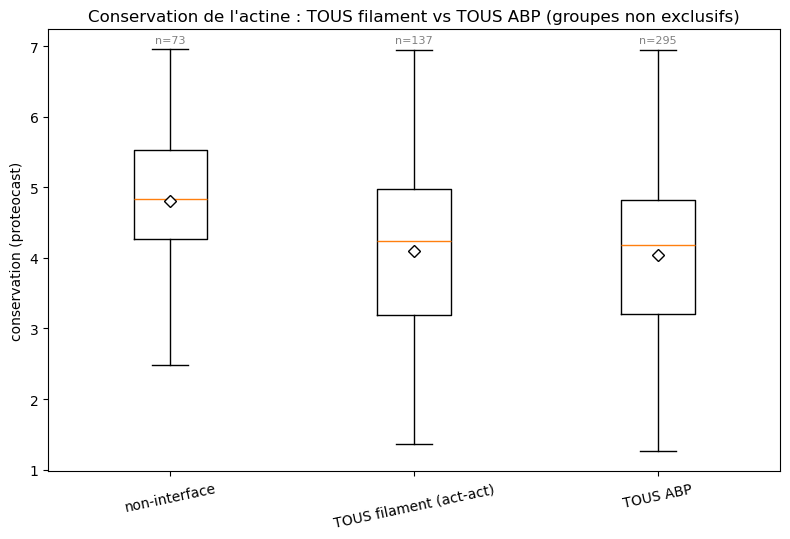

In [20]:
# === Conservation actine : TOUS filament (actine-actine) vs TOUS ABP (groupes NON exclusifs) ===
# Version etendue : un residu compte dans 'filament' des qu'il touche une autre actine
# (meme s'il touche aussi un ABP), et dans 'ABP' des qu'il touche un ABP (meme s'il
# touche aussi le filament). Les groupes se CHEVAUCHENT -> on teste par paires
# (Mann-Whitney), pas en Kruskal-Wallis (qui suppose des groupes independants).
from scipy.stats import mannwhitneyu
_cv=pd.read_csv(_R/'data/proteocast/conservation_vs_asa_per_position.csv')
for _c in ['at_homo','at_hetero','at_interface']: _cv[_c]=_cv[_c].astype(bool)

_groups={
    'non-interface'          : _cv[~_cv.at_interface]['conservation'].dropna(),
    'TOUS filament (act-act)': _cv[_cv.at_homo]['conservation'].dropna(),   # tous, meme si aussi ABP
    'TOUS ABP'               : _cv[_cv.at_hetero]['conservation'].dropna(),  # tous, meme si aussi filament
}
_ord=list(_groups)
print('Score conservation : plus eleve = position plus conservee (sensible aux mutations)')
print('Groupes NON exclusifs (une position peut etre dans filament ET ABP).\n')
_tab=pd.DataFrame({'count':[len(_groups[g]) for g in _ord],
                   'median':[_groups[g].median() for g in _ord],
                   'mean':[_groups[g].mean() for g in _ord]}, index=_ord).round(3)
print(_tab.to_string()); print()

print('Comparaisons par paires (Mann-Whitney) :')
for a,b in [('TOUS filament (act-act)','non-interface'),
            ('TOUS ABP','non-interface'),
            ('TOUS filament (act-act)','TOUS ABP')]:
    p=mannwhitneyu(_groups[a],_groups[b])[1]
    print(f'  {a:24s} vs {b:24s} : mediane {_groups[a].median():.2f} vs {_groups[b].median():.2f}  p={p:.2e}')

fig,ax=plt.subplots(figsize=(8,5.5))
bp=ax.boxplot([_groups[g] for g in _ord],labels=_ord,showmeans=True,
              meanprops=dict(marker='D',mfc='white',mec='k',ms=6))
for i,g in enumerate(_ord): ax.text(i+1,7.05,f'n={len(_groups[g])}',ha='center',fontsize=8,color='grey')
ax.set_ylabel('conservation (proteocast)')
ax.set_title("Conservation de l'actine : TOUS filament vs TOUS ABP (groupes non exclusifs)")
ax.tick_params(axis='x',rotation=12)
plt.tight_layout(); plt.show()

Score conservation : plus eleve = position plus conservee.
Coeur = max buried_ASA > 25% dans le type d interface.

                    count  median   mean
coeur filament+ABP    179   4.286  4.198
coeur ABP seul        193   4.321  4.214

coeur filament+ABP (n=179) vs coeur ABP seul (n=193) : p=7.42e-01
coeur filament tous (n=179, med=4.29) vs coeur ABP tous (n=372, med=4.29) : p=8.46e-01


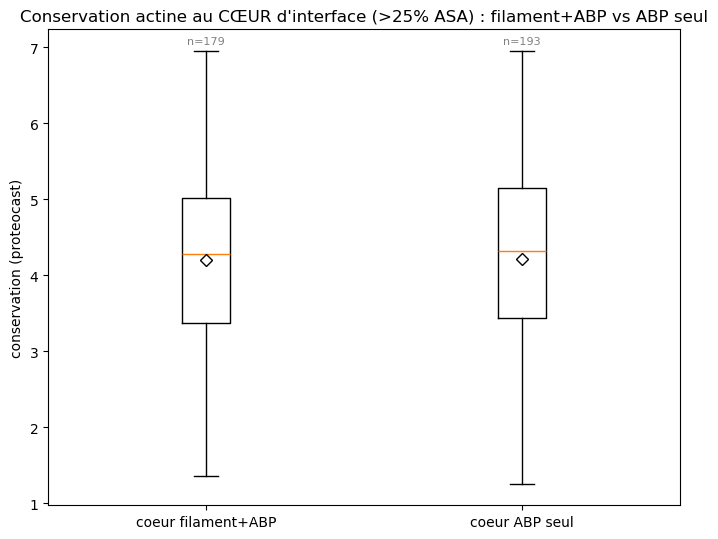

In [21]:
# === Conservation actine : CŒUR d'interface (max ASA > 25%) filament vs ABP ===
# Variante 'coeur' de la cellule precedente : un residu compte dans un groupe seulement
# s'il est REELLEMENT enfoui (max buried_ASA > 25%) dans ce type d'interface, pas
# juste effleure. Calcule depuis 3.interface_residues.csv (max ASA par position canon).
from scipy.stats import mannwhitneyu
_di1=pd.read_csv(_R/'data/filtered/details/1.interactions.csv')
_pp1=pd.read_csv(_R/'data/filtered/proteins_per_pdb.csv')
_ac1=set(_pp1[_pp1.is_actin]['chain'].str.lower())
_homoids=set(_di1[_di1['chain_B_id'].str.lower().isin(_ac1)]['interaction_id'])
_d3=_df3[_df3.canon.notna()&_df3.pct.notna()].copy(); _d3['canon']=_d3.canon.astype(int)
_d3['is_homo']=_d3.interaction_id.isin(_homoids)
_hm=_d3[_d3.is_homo].groupby('canon')['pct'].max()      # ASA max cote filament
_hh=_d3[~_d3.is_homo].groupby('canon')['pct'].max()     # ASA max cote ABP

_cvc=pd.read_csv(_R/'data/proteocast/conservation_vs_asa_per_position.csv').set_index('canon')
_fcore=(_hm.reindex(_cvc.index)>25).fillna(False)   # coeur filament : max ASA homo > 25%
_acore=(_hh.reindex(_cvc.index)>25).fillna(False)   # coeur ABP      : max ASA hetero > 25%

# NB : avec le max sur toutes les structures, coeur filament (179) est INCLUS dans coeur ABP (372).
# Les seules comparaisons non degenerees : filament&ABP vs ABP-seul (et filament-tous vs ABP-tous).
_grp={
    'coeur filament+ABP': _cvc['conservation'][_fcore & _acore].dropna(),   # les deux >25%
    'coeur ABP seul'     : _cvc['conservation'][_acore & ~_fcore].dropna(),  # ABP>25 mais pas filament
}
_ord=list(_grp)
print('Score conservation : plus eleve = position plus conservee.')
print('Coeur = max buried_ASA > 25% dans le type d interface.\n')
print(pd.DataFrame({'count':[len(_grp[g]) for g in _ord],
                    'median':[_grp[g].median() for g in _ord],
                    'mean':[_grp[g].mean() for g in _ord]}, index=_ord).round(3).to_string())
print()
_p=mannwhitneyu(_grp['coeur filament+ABP'],_grp['coeur ABP seul'])[1]
print(f'coeur filament+ABP (n={len(_grp["coeur filament+ABP"])}) vs coeur ABP seul (n={len(_grp["coeur ABP seul"])}) : p={_p:.2e}')
# repere global : coeur filament (tous) vs coeur ABP (tous)
_gf=_cvc['conservation'][_fcore].dropna(); _ga=_cvc['conservation'][_acore].dropna()
print(f'coeur filament tous (n={len(_gf)}, med={_gf.median():.2f}) vs coeur ABP tous (n={len(_ga)}, med={_ga.median():.2f}) : p={mannwhitneyu(_gf,_ga)[1]:.2e}')

fig,ax=plt.subplots(figsize=(7,5.5))
ax.boxplot([_grp[g] for g in _ord],labels=_ord,showmeans=True,
           meanprops=dict(marker='D',mfc='white',mec='k',ms=6))
for i,g in enumerate(_ord): ax.text(i+1,7.05,f'n={len(_grp[g])}',ha='center',fontsize=8,color='grey')
ax.set_ylabel('conservation (proteocast)')
ax.set_title("Conservation actine au CŒUR d'interface (>25% ASA) : filament+ABP vs ABP seul")
plt.tight_layout(); plt.show()

### Résidus « hotspot » de l'actine — contacts polaires les plus fréquents
Quelles positions canoniques de l'actine forment le plus de liaisons H et de ponts salins, toutes interfaces confondues. Le côté actine est identifié par la présence d'une numérotation canonique MAFFT (`residue_*_canon_mafft`).

Top 15 positions canoniques actine par nb de contacts polaires :
 canon    n res  n_pdb  hbond  both  salt
   173 5806   Y    663   5800     5     1
   275 5215   E    859   4913   112   190
   292 4875   I    710   4873     1     1
   249 4208   D    642   3667   426   115
   293 4163   D    700   3698   367    98
    48 4055   M    662   4055     0     0
    47 4027   V    568   4027     0     0
   177 3957   H   1267   3956     0     1
    44 3871   H   1217   3777    19    75
   291 3822   D   1015   3285   353   184
   199 3716   E    819   3491   210    15
    43 3653   R   1287   2985   435   233
    49 3540   V    642   3540     0     0
   195 3236   K    747   3234     1     1
   205 3213   V    788   3208     5     0


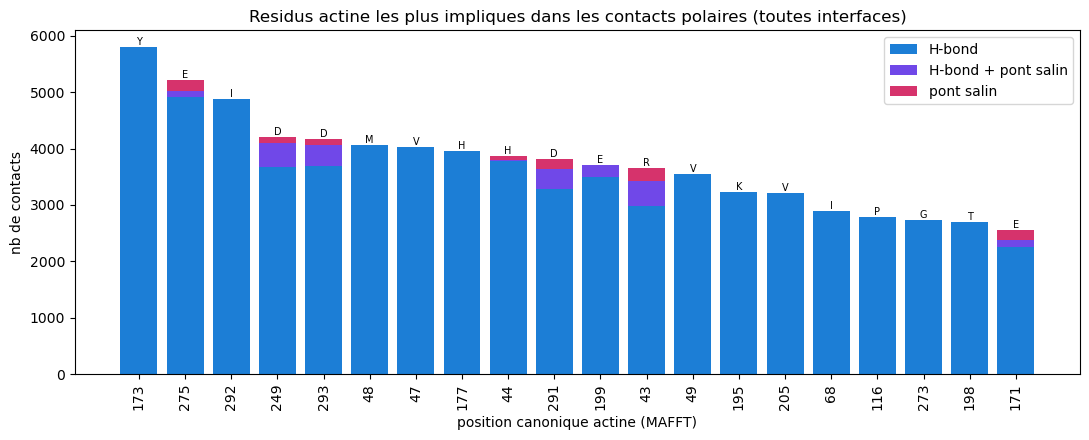

In [22]:
# === Residus 'hotspot' de l'actine : contacts polaires (H-bond / pont salin) ===
_ct=pd.read_csv(_R/'data/filtered/details/4.inter-residue_contacts.csv')
_a=_ct[['interaction_id','residue_A_canon_mafft','residue_A_name','contact_type']].rename(columns={'residue_A_canon_mafft':'canon','residue_A_name':'res'})
_b=_ct[['interaction_id','residue_B_canon_mafft','residue_B_name','contact_type']].rename(columns={'residue_B_canon_mafft':'canon','residue_B_name':'res'})
_act=pd.concat([_a,_b],ignore_index=True).dropna(subset=['canon']); _act['canon']=_act['canon'].astype(int)
def _cat(t):
    t=str(t)
    if 'H-bond' in t and 'Salt bridge' in t: return 'both'
    if 'Salt bridge' in t: return 'salt'
    return 'hbond'
_act['cat']=_act['contact_type'].map(_cat)
_hot=_act.groupby('canon').agg(n=('cat','size'),res=('res',lambda s:s.mode().iloc[0]),n_pdb=('interaction_id','nunique')).reset_index().sort_values('n',ascending=False)
_piv=_act.groupby(['canon','cat']).size().unstack(fill_value=0)
for _c in ['hbond','both','salt']:
    if _c not in _piv: _piv[_c]=0
print('Top 15 positions canoniques actine par nb de contacts polaires :')
print(_hot.head(15).merge(_piv[['hbond','both','salt']],on='canon').to_string(index=False))
_top=_hot.head(20); _pv=_piv.reindex(_top['canon'])
fig,ax=plt.subplots(figsize=(11,4.5)); _x=list(range(len(_top)))
ax.bar(_x,_pv['hbond'],color='#1c7ed6',label='H-bond')
ax.bar(_x,_pv['both'],bottom=_pv['hbond'].values,color='#7048e8',label='H-bond + pont salin')
ax.bar(_x,_pv['salt'],bottom=_pv['hbond'].values+_pv['both'].values,color='#d6336c',label='pont salin')
for _i,(_,_r) in enumerate(_top.iterrows()): ax.text(_i,_r['n'],_r['res'],ha='center',va='bottom',fontsize=7)
ax.set_xticks(_x); ax.set_xticklabels([str(c) for c in _top['canon']],rotation=90)
ax.set_xlabel('position canonique actine (MAFFT)'); ax.set_ylabel('nb de contacts'); ax.legend()
ax.set_title('Residus actine les plus impliques dans les contacts polaires (toutes interfaces)')
plt.tight_layout(); plt.show()

## 3. Analyse de compétition — sites S1 partagés

In [23]:
# Pour chaque site S1 : liste des ABPs qui s'y fixent
competition = (
    hetero_m.dropna(subset=["protein", "s1_binding_site_cluster_data_70"])
    .groupby("s1_binding_site_cluster_data_70")
    .agg(
        nb_abp=("protein", "nunique"),
        abps=("protein", lambda x: sorted(x.unique().tolist())),
        nb_inter=("subunit_1", "count"),
        nb_pdb=("_pdb", "nunique"),
    )
    .reset_index()
    .rename(columns={"s1_binding_site_cluster_data_70": "Site S1"})
    .sort_values("nb_abp", ascending=False)
)

compet_multi = competition[competition["nb_abp"] >= 2].copy()
compet_multi["ABPs"] = compet_multi["abps"].apply(lambda x: " · ".join(x))

print(f"{len(compet_multi)} sites S1 avec ≥ 2 ABPs (compétition potentielle)")
compet_multi[["Site S1", "nb_abp", "nb_inter", "nb_pdb", "ABPs"]]

28 sites S1 avec ≥ 2 ABPs (compétition potentielle)


,Site S1,nb_abp,nb_inter,nb_pdb,ABPs
130,6685_6,6,19,11,"Myosin-14,Alpha-actinin A · Myosin-6 · Myosin-..."
0,6685_0,5,83,22,Alpha-catenin-like protein hmp-1 · Catenin alp...
13,6685_121,4,23,5,Inositol-trisphosphate 3-kinase A · Plastin-3 ...
42,6685_16,4,22,5,Catenin alpha-1 · Epididymis secretory protein...
31,6685_15,4,16,4,Actin-related protein 2/3 complex subunit 1B ·...
71,6685_200,3,8,4,Cofilin-1 · Inverted formin-2 · Protein diapha...
1,6685_102,3,9,4,Catenin alpha-1 · Inositol-trisphosphate 3-kin...
68,6685_193,3,7,4,Actin-related protein 2/3 complex subunit 1 · ...
27,6685_144,3,9,5,Actin-related protein 2/3 complex subunit 1 · ...
24,6685_141,3,28,5,Alpha-catenin-like protein hmp-1 · Catenin alp...


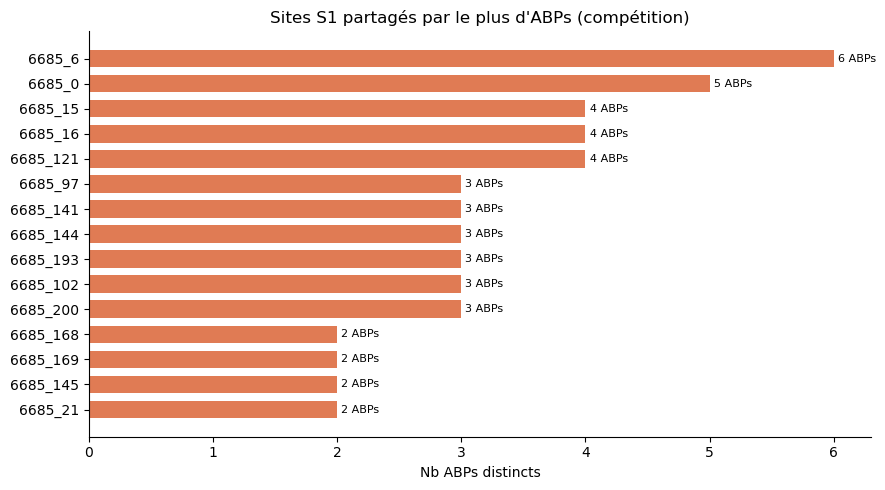

In [24]:
# Bar chart : sites S1 les plus "disputés"
top_sites = compet_multi.head(15).sort_values("nb_abp")
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(top_sites["Site S1"].astype(str), top_sites["nb_abp"],
               color="#e07b54", height=0.7)
ax.bar_label(bars, fmt="%d ABPs", padding=3, fontsize=8)
ax.set_xlabel("Nb ABPs distincts")
ax.set_title("Sites S1 partagés par le plus d'ABPs (compétition)")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

In [25]:
# Réseau de compétition : ABPs reliés par sites S1 partagés
import networkx as nx

G = nx.Graph()
for _, row in compet_multi.iterrows():
    abps = row["abps"]
    site = row["Site S1"]
    for i, a in enumerate(abps):
        for b in abps[i+1:]:
            if G.has_edge(a, b):
                G[a][b]["weight"] += 1
                G[a][b]["sites"].append(site)
            else:
                G.add_edge(a, b, weight=1, sites=[site])

print(f"Réseau de compétition : {G.number_of_nodes()} ABPs · {G.number_of_edges()} paires")

# Paires les plus en compétition (partageant le plus de sites S1)
edges_sorted = sorted(G.edges(data=True), key=lambda e: e[2]["weight"], reverse=True)
print("\nTop 10 paires d'ABPs en compétition (nb sites S1 partagés) :")
for a, b, d in edges_sorted[:10]:
    print(f"  {a!r:40s} ↔ {b!r:40s}  → {d['weight']} sites : {d['sites']}")

Réseau de compétition : 37 ABPs · 64 paires

Top 10 paires d'ABPs en compétition (nb sites S1 partagés) :
  'Vibrio VopV'                            ↔ 'VopV'                                    → 3 sites : ['6685_257', '6685_258', '6685_259']
  'Adducin 1'                              ↔ 'Beta-adducin'                            → 3 sites : ['6685_152', '6685_151', '6685_150']
  'Myosin-6'                               ↔ 'Myosin heavy chain 4'                    → 2 sites : ['6685_193', '6685_97']
  'Alpha-catenin-like protein hmp-1'       ↔ 'Catenin alpha-1'                         → 2 sites : ['6685_0', '6685_141']
  'Cofilin-1'                              ↔ 'Cofilin-2'                               → 2 sites : ['6685_0', '6685_21']
  'Cofilin-1'                              ↔ 'Inverted formin-2'                       → 2 sites : ['6685_0', '6685_200']
  'Inverted formin-2'                      ↔ 'Protein diaphanous homolog 1'            → 2 sites : ['6685_200', '6685_211']
  'Epididy

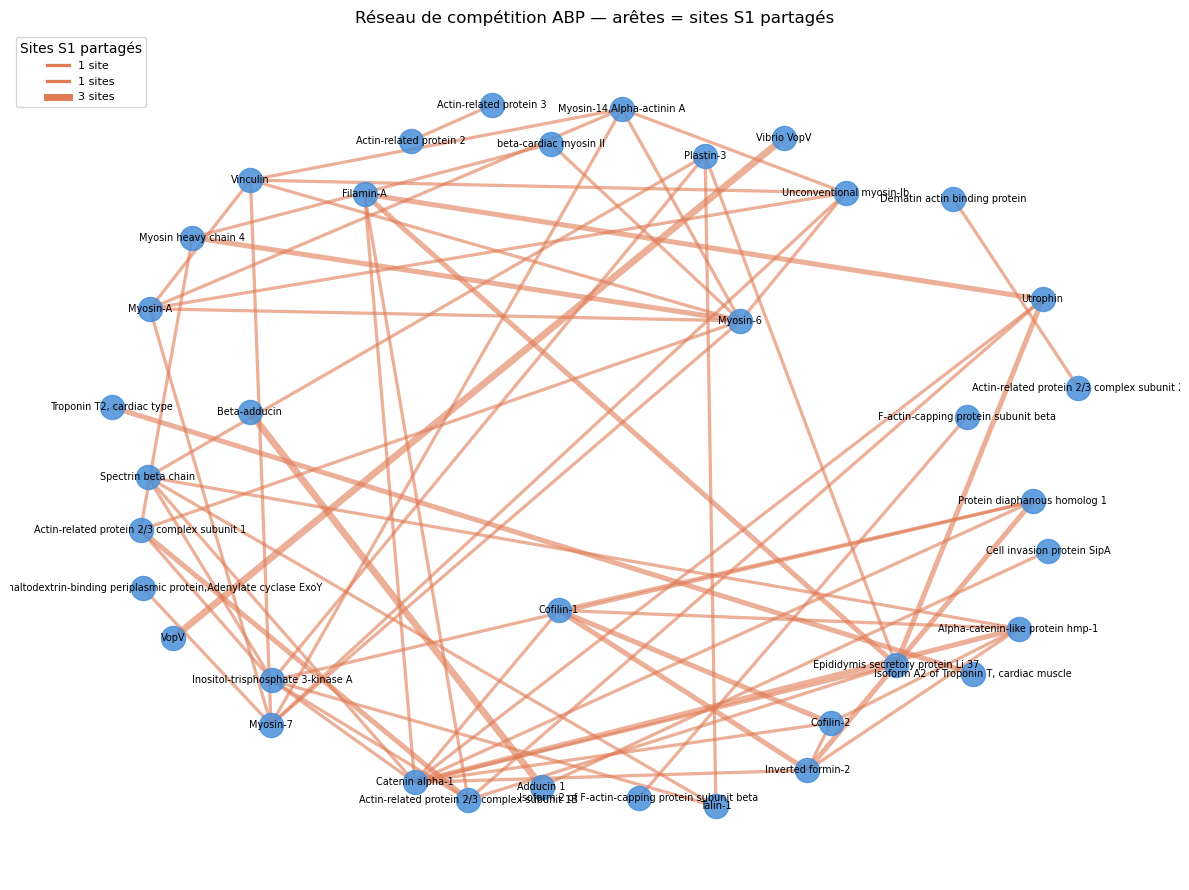

In [26]:
# Visualisation réseau (composantes principales)
# Filtrer les ABPs avec au moins 1 compétiteur
fig, ax = plt.subplots(figsize=(12, 9))

weights = [G[u][v]["weight"] for u, v in G.edges()]
w_max   = max(weights) if weights else 1

pos = nx.spring_layout(G, k=2.5, seed=42)
nx.draw_networkx_nodes(G, pos, ax=ax, node_size=300,
                       node_color="#4a90d9", alpha=0.85)
nx.draw_networkx_labels(G, pos, ax=ax, font_size=7)
nx.draw_networkx_edges(
    G, pos, ax=ax,
    width=[1 + 4 * w / w_max for w in weights],
    edge_color="#e07b54", alpha=0.6,
)
# Légende épaisseur
for w, lbl in [(1, "1 site"), (w_max // 2, f"{w_max//2} sites"), (w_max, f"{w_max} sites")]:
    ax.plot([], [], color="#e07b54",
            linewidth=1 + 4 * w / w_max, label=lbl)
ax.legend(title="Sites S1 partagés", fontsize=8, loc="upper left")
ax.set_title("Réseau de compétition ABP — arêtes = sites S1 partagés", fontsize=12)
ax.axis("off")
plt.tight_layout()
plt.show()

## 4. Détail par site S1 : quels ABPs sont en compétition ?

In [27]:
# Sélectionner un site S1 pour voir le détail des interactions par ABP
SITE_S1 = "6685_0"  # ← changer ici

site_data = hetero_m[
    hetero_m["s1_binding_site_cluster_data_70"] == SITE_S1
].copy()

detail = (
    site_data.groupby("protein")
    .agg(
        nb_inter=("subunit_1", "count"),
        nb_pdb=("_pdb", "nunique"),
        nb_c70=("cluster_data_70", "nunique"),
        c70_clusters=("cluster_data_70",
                      lambda x: ", ".join(sorted(x.dropna().astype(str).unique()))),
        area_moy=("area", "mean"),
        contacts_moy=("number_of_contacts", "mean"),
    )
    .reset_index()
    .sort_values("nb_inter", ascending=False)
)

print(f"Site S1 : {SITE_S1} — {len(detail)} ABPs en compétition")
detail

Site S1 : 6685_0 — 5 ABPs en compétition


,protein,nb_inter,nb_pdb,nb_c70,c70_clusters,area_moy,contacts_moy
3,Cofilin-2,42,10,1,0_30351_1,1082.097869,91.357143
2,Cofilin-1,27,8,1,0_30351_1,1007.246124,89.148148
1,Catenin alpha-1,7,2,2,"0_36172_1, 0_39640_1",847.528095,76.000000
0,Alpha-catenin-like protein hmp-1,5,1,1,0_65066_1,718.058249,59.000000
4,Inverted formin-2,2,1,1,0_74512_0,407.355210,37.000000


76 positions canoniques · 5 ABPs
Nb interactions par ABP (dénominateur) :
{'Alpha-catenin-like protein hmp-1': 5, 'Catenin alpha-1': 7, 'Cofilin-1': 27, 'Cofilin-2': 42, 'Inverted formin-2': 2}


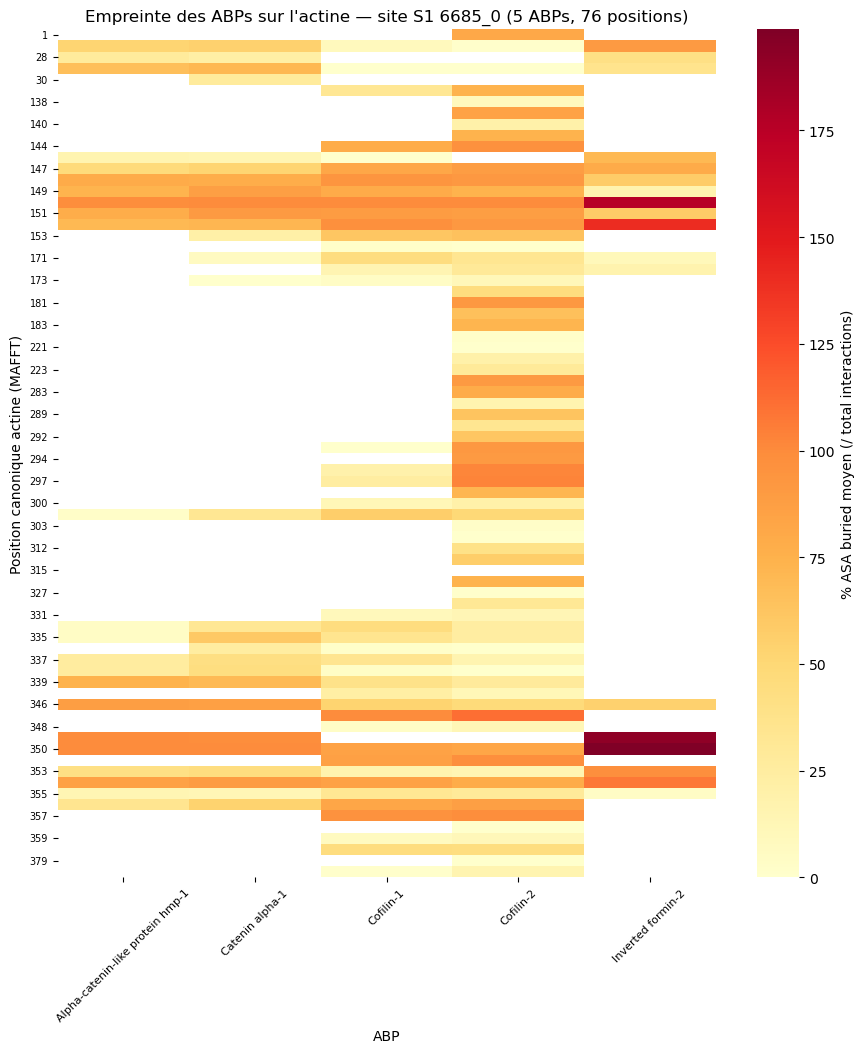

In [28]:
# Charger résidus d'interface et interactions pour relier positions → ABP
df3_nb    = pd.read_csv("../data/filtered/details/3.interface_residues.csv")
df_int_nb = pd.read_csv("../data/filtered/details/1.interactions.csv")

df3_nb["residue_number_canon_mafft"] = pd.to_numeric(
    df3_nb["residue_number_canon_mafft"], errors="coerce")
df3_nb["buried_ASA_percent"] = pd.to_numeric(
    df3_nb["buried_ASA_percent"].astype(str).str.replace("%", "", regex=False),
    errors="coerce")

# Relier les interactions du site S1 aux interaction_ids via 1.interactions.csv
site_with_ids = site_data.merge(
    df_int_nb[["interaction_id", "chain_A_id", "chain_B_id"]],
    left_on=["subunit_1", "subunit_2"],
    right_on=["chain_A_id", "chain_B_id"],
    how="inner"
)

# Total d'interactions par ABP (dénominateur global — absences = 0)
_n_inter_total = (
    site_with_ids.groupby("protein")["interaction_id"].nunique()
    .rename("n_total")
)

# Garder seulement les résidus de la chaîne actine (S1)
_id_to_actin = site_with_ids.set_index("interaction_id")["chain_A_id"].str.lower()
_id_to_prot  = site_with_ids.set_index("interaction_id")["protein"]

df3_site = df3_nb[df3_nb["interaction_id"].isin(site_with_ids["interaction_id"])].copy()
df3_site["_actin_ch"] = df3_site["interaction_id"].map(_id_to_actin)
df3_site = df3_site[df3_site["chain"].str.lower() == df3_site["_actin_ch"]].copy()
df3_site["protein"] = df3_site["interaction_id"].map(_id_to_prot)
df3_site = df3_site.dropna(subset=["residue_number_canon_mafft", "protein"])
df3_site["canon"] = df3_site["residue_number_canon_mafft"].astype(int)

print(f"{df3_site['canon'].nunique()} positions canoniques · {df3_site['protein'].nunique()} ABPs")
print("Nb interactions par ABP (dénominateur) :")
print(_n_inter_total.to_dict())

# Somme ASA par (protein, canon), puis division par le total d'interactions
footprint_sum = (
    df3_site.groupby(["protein", "canon"])["buried_ASA_percent"]
    .sum()
    .reset_index()
    .rename(columns={"buried_ASA_percent": "asa_sum"})
)
footprint_sum = footprint_sum.join(_n_inter_total, on="protein")
footprint_sum["asa_mean"] = footprint_sum["asa_sum"] / footprint_sum["n_total"]

pivot_fp = footprint_sum.pivot_table(
    index="canon", columns="protein",
    values="asa_mean", fill_value=0
)
pivot_fp.columns.name = "ABP"

fig_fp, ax_fp = plt.subplots(
    figsize=(max(7, pivot_fp.shape[1] * 1.8), max(6, pivot_fp.shape[0] * 0.14))
)
sns.heatmap(
    pivot_fp,
    ax=ax_fp,
    cmap="YlOrRd",
    mask=pivot_fp == 0,
    linewidths=0,
    vmin=0,
    cbar_kws={"label": "% ASA buried moyen (/ total interactions)"},
)
ax_fp.set_title(
    f"Empreinte des ABPs sur l'actine — site S1 {SITE_S1} "
    f"({pivot_fp.shape[1]} ABPs, {pivot_fp.shape[0]} positions)",
    fontsize=12,
)
ax_fp.set_xlabel("ABP", fontsize=10)
ax_fp.set_ylabel("Position canonique actine (MAFFT)", fontsize=10)
ax_fp.tick_params(axis="x", rotation=45, labelsize=8)
ax_fp.tick_params(axis="y", labelsize=7)
plt.tight_layout()
plt.show()

## 5. PDB sans ABP — filaments d'actine pure

In [29]:
pdbs_with_abp = set(df_pp[~df_pp["is_actin"]]["pdb_id"])
all_pdbs      = set(df_all["_pdb"])
pdbs_no_abp   = all_pdbs - pdbs_with_abp

print(f"PDB sans ABP : {len(pdbs_no_abp)} / {len(all_pdbs)} au total")

homo_no_abp = df_all[
    df_all["s1_actine"] & df_all["s2_actine"] &
    df_all["_pdb"].isin(pdbs_no_abp) &
    df_all["cluster_data_70"].notna()
].copy()

homo_no_abp["Binding sites"] = homo_no_abp.apply(
    lambda r: " × ".join(sorted([
        str(r["s1_binding_site_cluster_data_70"]),
        str(r["s2_binding_site_cluster_data_70"])
    ])), axis=1
)

summary_no_abp = (
    homo_no_abp.groupby(["cluster_data_70", "Binding sites"])
    .agg(nb_pdb=("_pdb", "nunique"), nb_inter=("_pdb", "count"))
    .reset_index()
    .sort_values("nb_pdb", ascending=False)
)
summary_no_abp["%PDB"]   = (summary_no_abp["nb_pdb"]   / len(pdbs_no_abp) * 100).round(1)
summary_no_abp["%inter"] = (summary_no_abp["nb_inter"] / len(homo_no_abp)  * 100).round(1)

summary_no_abp

PDB sans ABP : 60 / 144 au total


,cluster_data_70,Binding sites,nb_pdb,nb_inter,%PDB,%inter
0,0_7797_0,6685_1 × 6685_2,60,258,100.0,53.8
2,0_7797_1,6685_3 × 6685_4,57,199,95.0,41.5
1,0_7797_0,6685_109 × 6685_2,3,10,5.0,2.1
5,0_7797_45,6685_3 × 6685_4,2,8,3.3,1.7
3,0_7797_10,6685_1 × 6685_2,1,2,1.7,0.4
4,0_7797_32,6685_3 × 6685_4,1,3,1.7,0.6


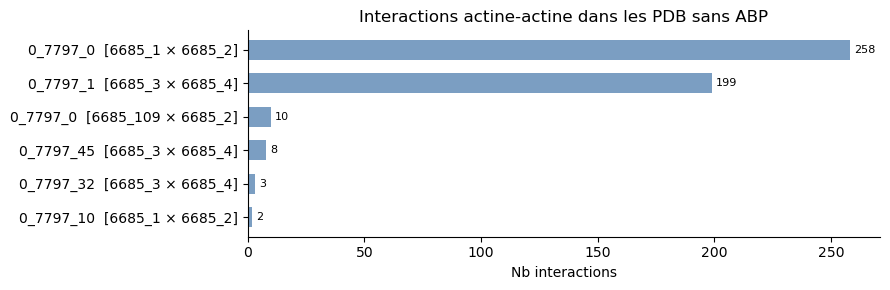

In [30]:
# Bar chart clusters actine-actine dans PDB sans ABP
s_na = summary_no_abp.sort_values("nb_inter")
lbl  = s_na["cluster_data_70"].astype(str) + "  [" + s_na["Binding sites"] + "]"

fig, ax = plt.subplots(figsize=(9, max(3, len(s_na) * 0.45)))
bars = ax.barh(lbl, s_na["nb_inter"], color="#7b9ec2", height=0.6)
ax.bar_label(bars, fmt="%d", padding=3, fontsize=8)
ax.set_xlabel("Nb interactions")
ax.set_title("Interactions actine-actine dans les PDB sans ABP")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## %ASA par résidu selon le type de contact actine-actine (filament)

Échelle **résiduelle** : pour chaque type de contact aa (sites de liaison `6685_1/2/3/4` + mineurs), distribution du `%ASA enfoui` **par position canonique** (moyenné sur les structures du site pour éviter la pseudo-réplication). Montre la structure **cœur/pourtour** de chaque contact, pas une moyenne trompeuse.

contact  n_res  med_ASA  pct_coeur  pct_profond
 6685_1     37     10.5       32.4         10.8
 6685_2     39     11.9       25.6         10.3
 6685_3     35     40.1       71.4         42.9
 6685_4     52     30.9       55.8         42.3
 autres     70     24.0       48.6         24.3


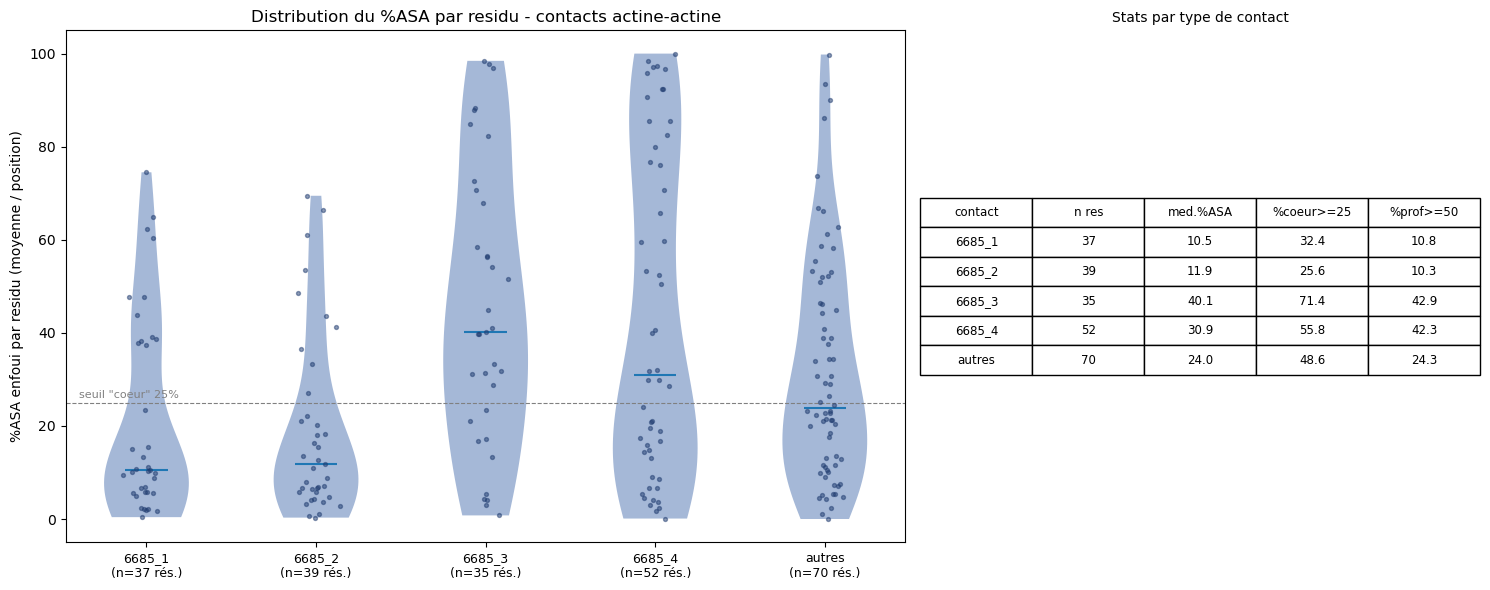

In [31]:
# === %ASA par residu pour chaque type de contact actine-actine ===
import warnings; warnings.filterwarnings('ignore')
from pathlib import Path as _P
_R=_P('..') if _P('../data').exists() else _P('.')
_df3=pd.read_csv(_R/'data/filtered/details/3.interface_residues.csv')
_df3['pct']=pd.to_numeric(_df3['buried_ASA_percent'].astype(str).str.replace('%','',regex=False),errors='coerce')
_df3['canon']=pd.to_numeric(_df3['residue_number_canon_mafft'],errors='coerce')
_df3=_df3[_df3.canon.notna()&_df3.pct.notna()].copy()
_di=pd.read_csv(_R/'data/filtered/details/1.interactions.csv')
_da=pd.read_csv(_R/'data/filtered/filtered_all_data.csv',low_memory=False)
_m=_di.merge(_da[['subunit_1','subunit_2','s2_actine','s1_binding_site_cluster_data_70']].drop_duplicates(),
             left_on=['chain_A_id','chain_B_id'],right_on=['subunit_1','subunit_2'],how='left').drop_duplicates('interaction_id')
_m['homo']=_m['s2_actine'].fillna(False).astype(bool)
_h=_m[_m.homo].dropna(subset=['s1_binding_site_cluster_data_70']).copy()
_chA=_h.set_index('interaction_id')['chain_A_id'].str.lower(); _site=_h.set_index('interaction_id')['s1_binding_site_cluster_data_70']
_d=_df3[_df3.interaction_id.isin(set(_h.interaction_id))].copy()
_d['_a']=_d.interaction_id.map(_chA); _d=_d[_d.chain.str.lower()==_d._a].copy()
_d['site']=_d.interaction_id.map(_site); _d['canon']=_d.canon.astype(int)
_main=['6685_1','6685_2','6685_3','6685_4']; _d['grp']=_d['site'].where(_d['site'].isin(_main),'autres')
_pr=_d.groupby(['grp','canon'])['pct'].mean().reset_index()
_order=_main+['autres']; _data=[_pr[_pr.grp==g]['pct'].values for g in _order]
_lab=[f"{g}\n(n={len(v)} rés.)" for g,v in zip(_order,_data)]
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(15,6),gridspec_kw={'width_ratios':[1.5,1]})
_pa=ax1.violinplot(_data,showmedians=True,showextrema=False)
for pc in _pa['bodies']: pc.set_facecolor('#4C72B0'); pc.set_alpha(.5)
for i,v in enumerate(_data): ax1.scatter(np.random.normal(i+1,0.05,len(v)),v,s=8,color='#1f3b6f',alpha=.5,zorder=3)
ax1.set_xticks(range(1,len(_order)+1)); ax1.set_xticklabels(_lab,fontsize=9)
ax1.set_ylabel("%ASA enfoui par residu (moyenne / position)"); ax1.set_title("Distribution du %ASA par residu - contacts actine-actine")
ax1.axhline(25,color='grey',ls='--',lw=.8); ax1.text(0.6,26,'seuil "coeur" 25%',fontsize=8,color='grey')
_rows=[[g,len(v),np.median(v),100*np.mean(v>=25),100*np.mean(v>=50)] for g,v in zip(_order,_data)]
_T=pd.DataFrame(_rows,columns=['contact','n_res','med_ASA','pct_coeur','pct_profond'])
print(_T.round(1).to_string(index=False)); ax2.axis('off')
_tb=ax2.table(cellText=_T.round(1).values,colLabels=['contact','n res','med.%ASA','%coeur>=25','%prof>=50'],loc='center',cellLoc='center')
_tb.auto_set_font_size(False); _tb.set_fontsize(8.5); _tb.scale(1,1.6); ax2.set_title('Stats par type de contact',fontsize=10)
plt.tight_layout(); plt.show()

## PCA des contacts résidu-résidu (tous contacts confondus)

**1 point = 1 contact entre 2 résidus** (homo + hétéro). Descripteurs **par côté A/B** : `asaA/asaB` (%ASA), `kdA/kdB` (hydrophobicité), `polaire_A/polaire_B` ; + `charge_compl`, `aromatique`, `conservation` (côté actine). Type en couleur.

_Pour les contacts hétéro, A = résidu d'actine, B = résidu du partenaire ABP._ ⚠️ ~120 000 contacts → boxplots + médianes pour le message quantitatif.

n contacts: 124153
type
vdW           114696
H-bond          5963
H-bond+sel      2233
pont salin      1261
Variance PC1+PC2 = 16% + 12% = 28%


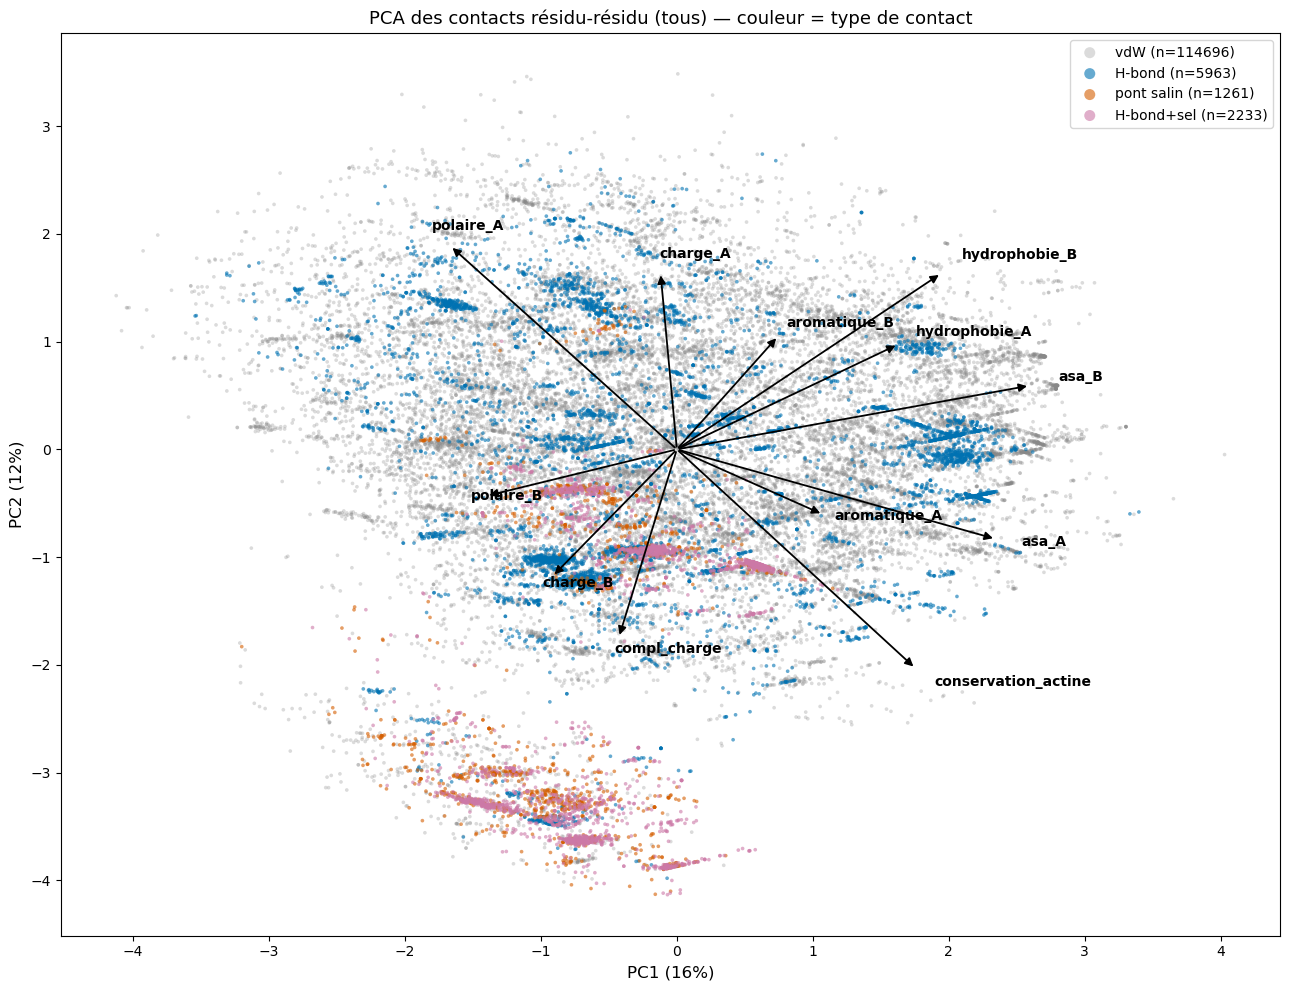

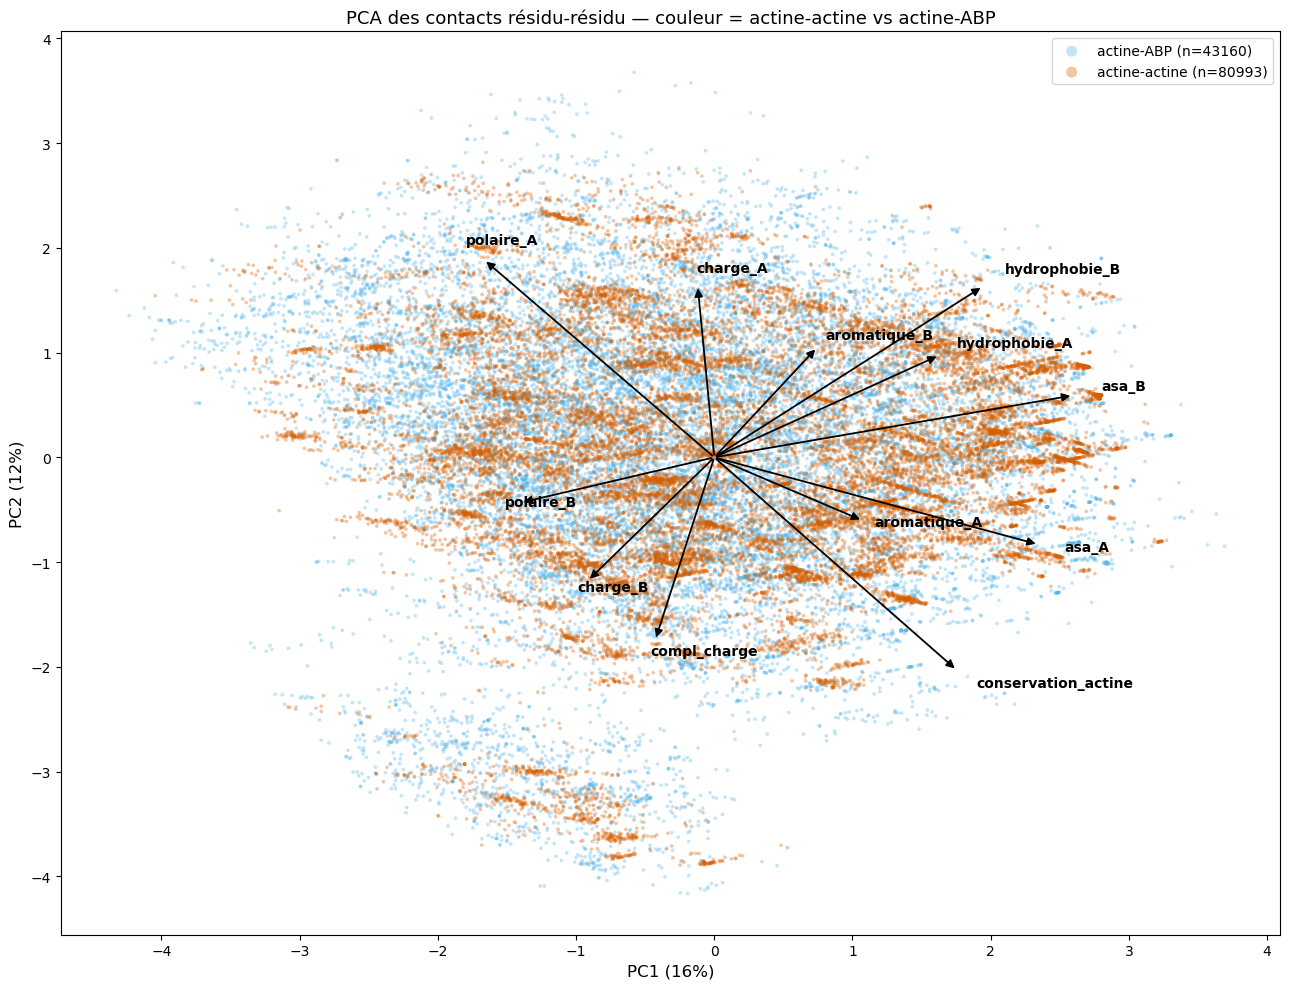

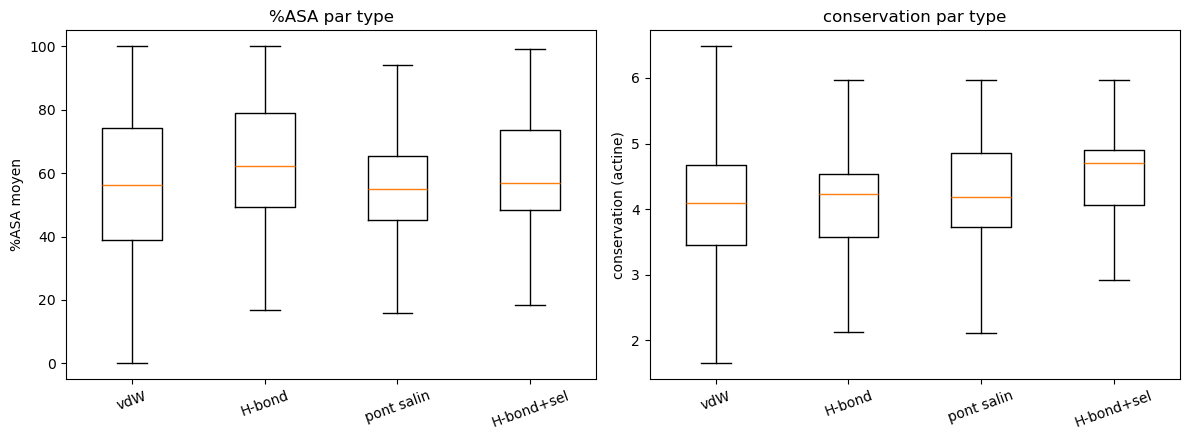

            asa_A  asa_B  conservation  compl_charge  aromatique_A  aromatique_B
type                                                                            
H-bond       68.1   60.4          4.24          0.06          0.10          0.07
H-bond+sel   58.8   54.7          4.71          0.98          0.00          0.00
pont salin   56.7   52.4          4.18          0.94          0.00          0.00
vdW          58.9   56.4          4.09          0.02          0.11          0.07


In [32]:
# === PCA des contacts residu-residu - descripteurs par cote A/B ===
import warnings; warnings.filterwarnings('ignore')
from pathlib import Path as _P
_R=_P('..') if _P('../data').exists() else _P('.')
_c=pd.read_csv(_R/'data/filtered/details/4.inter-residue_contacts.csv',low_memory=False)
def _num(s): return pd.to_numeric(s.astype(str).str.replace('Å²','',regex=False).str.replace('%','',regex=False).str.strip(),errors='coerce')
_c['asa_A']=_num(_c['asa_pct_A']); _c['asa_B']=_num(_c['asa_pct_B'])   # %ASA (0-100)
_KD={'A':1.8,'R':-4.5,'N':-3.5,'D':-3.5,'C':2.5,'Q':-3.5,'E':-3.5,'G':-0.4,'H':-3.2,'I':4.5,'L':3.8,'K':-3.9,'M':1.9,'F':2.8,'P':-1.6,'S':-0.8,'T':-0.7,'W':-0.9,'Y':-1.3,'V':4.2}
_CHG={'R':1,'K':1,'D':-1,'E':-1}; _ARO={'F','Y','W'}; _POL={'S','T','N','Q','H','C'}
_a=_c['residue_A_name'].astype(str); _b=_c['residue_B_name'].astype(str)
_c['hydrophobie_A']=_a.map(lambda r:_KD.get(r,np.nan)); _c['hydrophobie_B']=_b.map(lambda r:_KD.get(r,np.nan))
_c['polaire_A']=_a.isin(_POL).astype(int); _c['polaire_B']=_b.isin(_POL).astype(int)
_qA=_a.map(lambda r:_CHG.get(r,0)); _qB=_b.map(lambda r:_CHG.get(r,0)); _c['compl_charge']=-(_qA*_qB)
_c['aromatique_A']=_a.isin(_ARO).astype(int); _c['aromatique_B']=_b.isin(_ARO).astype(int)
_c['charge_A']=_qA.values; _c['charge_B']=_qB.values             # charges nettes separees
# conservation cote actine
_pp=pd.read_csv(_R/'data/filtered/proteins_per_pdb.csv'); _ac=set(_pp[_pp.is_actin]['chain'].str.lower())
_cdf=pd.read_csv(_R/'data/proteocast/conservation_vs_asa_per_position.csv'); _cons=dict(zip(_cdf['canon'].astype(int),_cdf['conservation']))
_cnA=pd.to_numeric(_c['residue_A_canon_mafft'],errors='coerce'); _cnB=pd.to_numeric(_c['residue_B_canon_mafft'],errors='coerce')
_isA=_c['chain_A_id'].str.lower().isin(_ac).values; _isB=_c['chain_B_id'].str.lower().isin(_ac).values
_c['iface']=np.where(_isA&_isB,'actine-actine',np.where(_isA^_isB,'actine-ABP','autre'))  # type de contact homo/hetero
def _cv(cn,ia): return _cons.get(int(cn),np.nan) if (ia and pd.notna(cn)) else np.nan
_csA=np.array([_cv(cn,ia) for cn,ia in zip(_cnA,_isA)]); _csB=np.array([_cv(cn,ia) for cn,ia in zip(_cnB,_isB)])
_c['conservation_actine']=np.nanmean(np.vstack([_csA,_csB]),axis=0)
def _typ(t):
    if pd.isna(t): return 'vdW'
    if 'Salt' in t and 'H-bond' in t: return 'H-bond+sel'
    if 'Salt' in t: return 'pont salin'
    if 'H-bond' in t: return 'H-bond'
    return 'vdW'
_c['type']=_c['contact_type'].map(_typ)
_feat=['asa_A','asa_B','hydrophobie_A','hydrophobie_B','polaire_A','polaire_B','charge_A','charge_B','compl_charge','aromatique_A','aromatique_B','conservation_actine']
_c=_c.dropna(subset=_feat).reset_index(drop=True)
print("n contacts:",len(_c)); print(_c['type'].value_counts().to_string())
_X=_c[_feat].values.astype(float); _Xz=(_X-_X.mean(0))/(_X.std(0)+1e-9)
_Xc=_Xz-_Xz.mean(0); _U,_S,_Vt=np.linalg.svd(_Xc,full_matrices=False); _pcs=_U[:,:2]*_S[:2]; _ev=(_S**2)/(_S**2).sum()*100
print(f"Variance PC1+PC2 = {_ev[0]:.0f}% + {_ev[1]:.0f}% = {_ev[0]+_ev[1]:.0f}%")
_cols={'vdW':'#888888','H-bond':'#0072B2','pont salin':'#D55E00','H-bond+sel':'#CC79A7'}
_cor=np.array([[np.corrcoef(_Xz[:,j],_pcs[:,k])[0,1] for k in range(2)] for j in range(len(_feat))])
_ty=_c['type'].values
fig,ax=plt.subplots(figsize=(13,10)); np.random.seed(0)
for t in ['vdW','H-bond','pont salin','H-bond+sel']:
    idx=np.where(_ty==t)[0]
    if t=='vdW' and len(idx)>20000: idx=np.random.choice(idx,20000,replace=False)  # sous-echantillon vdW pour l'affichage
    ax.scatter(_pcs[idx,0],_pcs[idx,1],s=7,alpha=.30 if t=='vdW' else .6,color=_cols[t],label=f'{t} (n={int((_ty==t).sum())})',edgecolor='none')
_f=0.6*np.abs(_pcs).max()/np.abs(_cor).max()
for j,nm in enumerate(_feat):
    ax.annotate('',xy=(_cor[j,0]*_f,_cor[j,1]*_f),xytext=(0,0),arrowprops=dict(arrowstyle='-|>',color='k',lw=1.3,mutation_scale=12),zorder=5)
    ax.annotate(nm,(_cor[j,0]*_f*1.08,_cor[j,1]*_f*1.08),fontsize=10,fontweight='bold',zorder=6)
ax.set_xlabel(f'PC1 ({_ev[0]:.0f}%)',fontsize=12); ax.set_ylabel(f'PC2 ({_ev[1]:.0f}%)',fontsize=12)
ax.legend(markerscale=3,fontsize=10,loc='best')
ax.set_title('PCA des contacts résidu-résidu (tous) — couleur = type de contact',fontsize=13)
plt.tight_layout(); plt.show()

# === meme PCA, colore par type d'interface : actine-actine (homo) vs actine-ABP (hetero) ===
_cif={'actine-ABP':'#56B4E9','actine-actine':'#D55E00','autre':'#cccccc'}; _iv=_c['iface'].values
fig,ax=plt.subplots(figsize=(13,10)); np.random.seed(0)
for t in ['actine-ABP','actine-actine']:
    idx=np.where(_iv==t)[0]
    if len(idx)>20000: idx=np.random.choice(idx,20000,replace=False)
    ax.scatter(_pcs[idx,0],_pcs[idx,1],s=7,alpha=.35,color=_cif[t],label=f'{t} (n={int((_iv==t).sum())})',edgecolor='none')
for j,nm in enumerate(_feat):
    ax.annotate('',xy=(_cor[j,0]*_f,_cor[j,1]*_f),xytext=(0,0),arrowprops=dict(arrowstyle='-|>',color='k',lw=1.3,mutation_scale=12),zorder=5)
    ax.annotate(nm,(_cor[j,0]*_f*1.08,_cor[j,1]*_f*1.08),fontsize=10,fontweight='bold',zorder=6)
ax.set_xlabel(f'PC1 ({_ev[0]:.0f}%)',fontsize=12); ax.set_ylabel(f'PC2 ({_ev[1]:.0f}%)',fontsize=12)
ax.legend(markerscale=3,fontsize=10,loc='best'); ax.set_title('PCA des contacts résidu-résidu — couleur = actine-actine vs actine-ABP',fontsize=13)
plt.tight_layout(); plt.show()
_o=['vdW','H-bond','pont salin','H-bond+sel']; _c['asa_m']=(_c['asa_A']+_c['asa_B'])/2
fig,axs=plt.subplots(1,2,figsize=(12,4.5))
axs[0].boxplot([_c[_c.type==t]['asa_m'] for t in _o],labels=_o,showfliers=False); axs[0].set_ylabel('%ASA moyen'); axs[0].set_title('%ASA par type'); axs[0].tick_params(axis='x',rotation=20)
axs[1].boxplot([_c[_c.type==t]['conservation_actine'] for t in _o],labels=_o,showfliers=False); axs[1].set_ylabel('conservation (actine)'); axs[1].set_title('conservation par type'); axs[1].tick_params(axis='x',rotation=20)
plt.tight_layout(); plt.show()
print(_c.groupby('type').agg(asa_A=('asa_A','median'),asa_B=('asa_B','median'),conservation=('conservation_actine','median'),compl_charge=('compl_charge','mean'),aromatique_A=('aromatique_A','mean'),aromatique_B=('aromatique_B','mean')).round(2).to_string())

Repartition : {np.str_('actine-actine (homo)'): 80993, np.str_('actine-ABP sans ARP (hetero)'): 40197, np.str_('actine-ARP'): 2963}


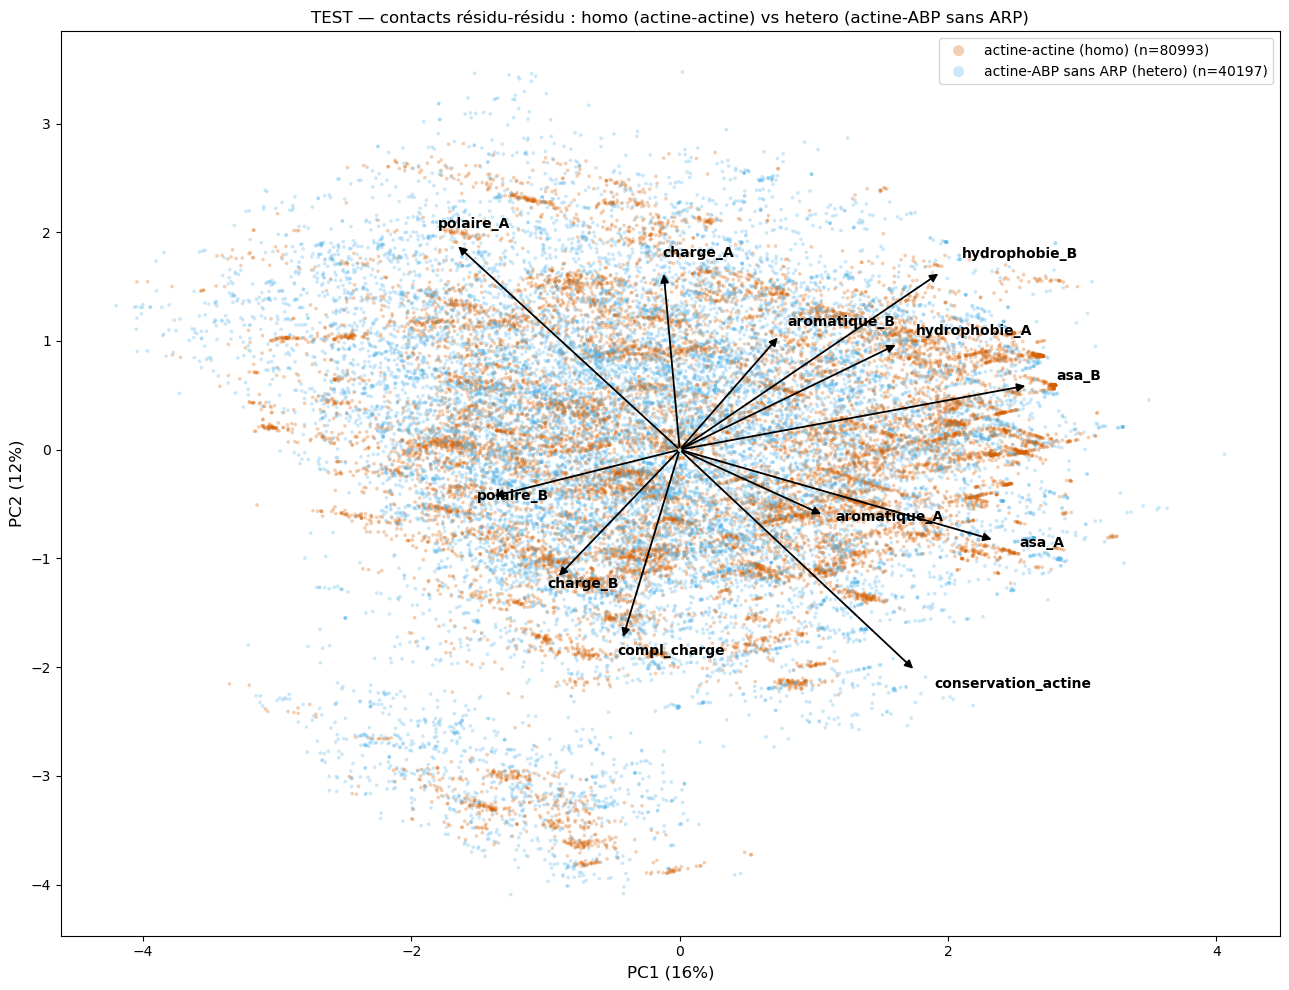

In [33]:
# === TEST : PCA complete des contacts, coloree par groupe homo / ARP / hetero ===
# (memes axes que la cellule precedente : _pcs, _cor, _ev, _feat, _c, _ac, _R)
_daX=pd.read_csv(_R/'data/filtered/filtered_all_data.csv',low_memory=False)
_t2l={}
for _s,_t in zip(_daX['subunit_1'].astype(str).str.lower(),_daX['subunit_1_title'].astype(str)): _t2l[_s]=_t
for _s,_t in zip(_daX['subunit_2'].astype(str).str.lower(),_daX['subunit_2_title'].astype(str)): _t2l[_s]=_t
_cA=_c['chain_A_id'].str.lower(); _cB=_c['chain_B_id'].str.lower()
_partner=np.where(_cA.isin(_ac),_cB,_cA)
_ptitle=pd.Series(_partner).map(lambda x:_t2l.get(x,'')).fillna('')
_is_arp=_ptitle.str.contains('actin-related',case=False,regex=False).values
_grp=np.where(_c['iface'].values=='actine-actine','actine-actine (homo)',
      np.where((_c['iface'].values=='actine-ABP')&_is_arp,'actine-ARP',
      np.where(_c['iface'].values=='actine-ABP','actine-ABP sans ARP (hetero)','autre')))
import collections as _co
print('Repartition :', dict(_co.Counter(_grp)))

_gcol={'actine-actine (homo)':'#D55E00','actine-ARP':'#009E73','actine-ABP sans ARP (hetero)':'#56B4E9','autre':'#dddddd'}
np.random.seed(0)
fig,ax=plt.subplots(figsize=(13,10))
for g in ['actine-actine (homo)','actine-ABP sans ARP (hetero)']:   # ARP retires
    idx=np.where(_grp==g)[0]
    if len(idx)==0: continue
    if len(idx)>15000: idx=np.random.choice(idx,15000,replace=False)
    ax.scatter(_pcs[idx,0],_pcs[idx,1],s=7,alpha=.30,color=_gcol[g],label=f'{g} (n={int((_grp==g).sum())})',edgecolor='none')
_f=0.6*np.abs(_pcs).max()/np.abs(_cor).max()
for j,nm in enumerate(_feat):
    ax.annotate('',xy=(_cor[j,0]*_f,_cor[j,1]*_f),xytext=(0,0),arrowprops=dict(arrowstyle='-|>',color='k',lw=1.3,mutation_scale=12),zorder=5)
    ax.annotate(nm,(_cor[j,0]*_f*1.08,_cor[j,1]*_f*1.08),fontsize=10,fontweight='bold',zorder=6)
ax.set_xlabel(f'PC1 ({_ev[0]:.0f}%)',fontsize=12); ax.set_ylabel(f'PC2 ({_ev[1]:.0f}%)',fontsize=12)
ax.legend(markerscale=3,fontsize=10,loc='best')
ax.set_title('TEST — contacts résidu-résidu : homo (actine-actine) vs hetero (actine-ABP sans ARP)',fontsize=12)
plt.tight_layout(); plt.show()

classes des contacts : {'sensitive': 91322, 'tolerant': 32831}
Variance PC1+PC2 = 17% + 12% = 29% (sans conservation, 11 descripteurs)


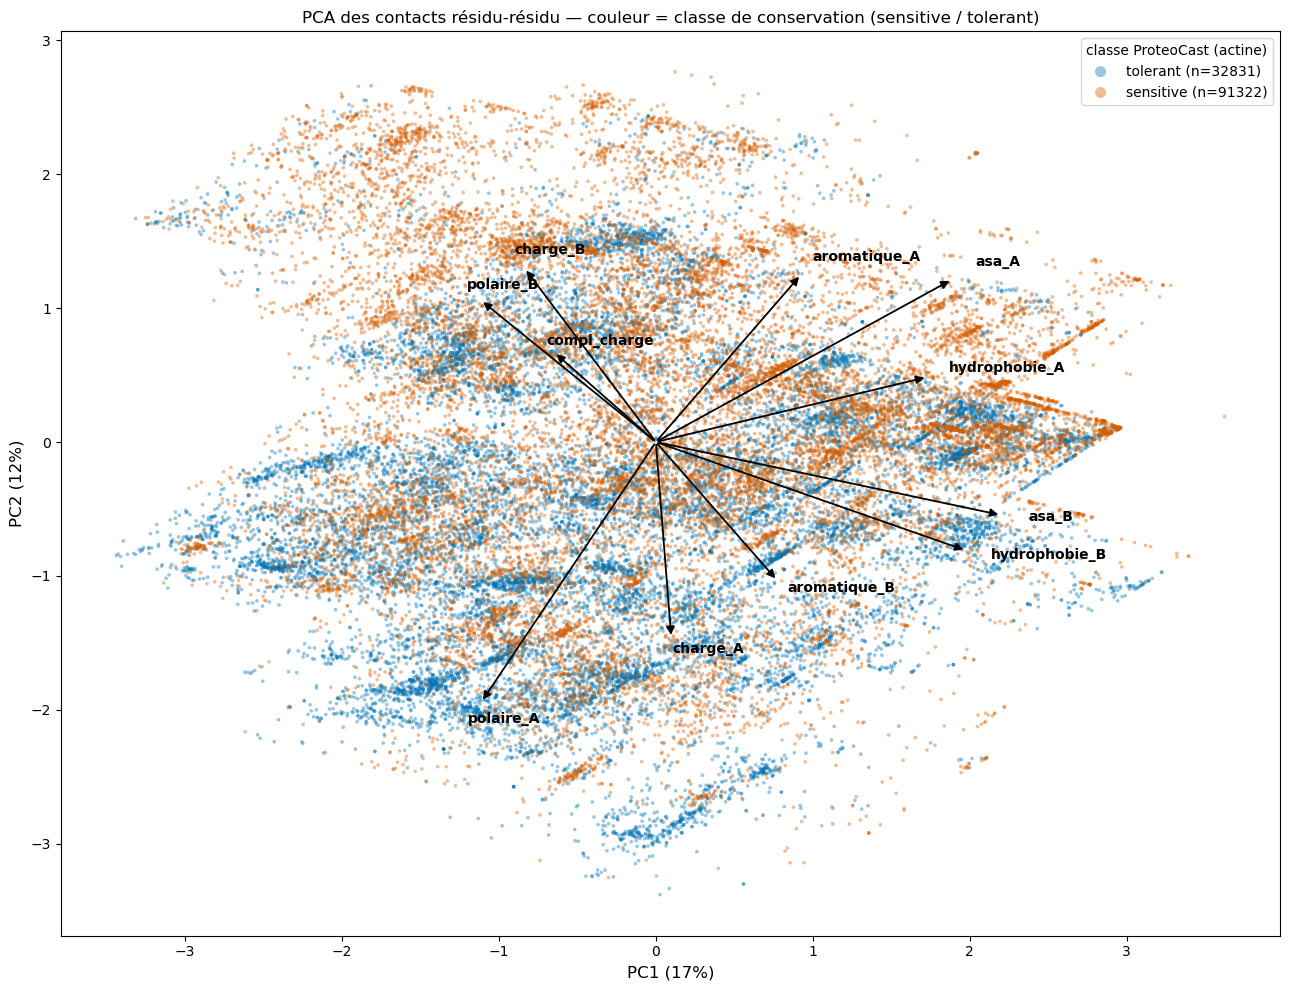

In [34]:
# === Variante : PCA des contacts SANS conservation, couleur = classe ProteoCast (actine) ===
# (s'appuie sur _c, _feat, _cdf, _ac definis dans la cellule contactpca)
_clsmap=dict(zip(_cdf['canon'].astype(int),_cdf['residue_class']))   # canon -> sensitive / tolerant
_cnA=pd.to_numeric(_c['residue_A_canon_mafft'],errors='coerce'); _cnB=pd.to_numeric(_c['residue_B_canon_mafft'],errors='coerce')
_isA=_c['chain_A_id'].str.lower().isin(_ac).values; _isB=_c['chain_B_id'].str.lower().isin(_ac).values
_clA=_cnA.map(lambda x:_clsmap.get(int(x)) if pd.notna(x) else None)
_clB=_cnB.map(lambda x:_clsmap.get(int(x)) if pd.notna(x) else None)
_clsv=np.array(['inconnu']*len(_c),dtype=object)
_useB=_isB & _clB.notna().values; _clsv[_useB]=_clB[_useB].astype(str).values
_useA=_isA & _clA.notna().values; _clsv[_useA]=_clA[_useA].astype(str).values   # cote actine A prioritaire
import collections as _co; print('classes des contacts :', dict(_co.Counter(_clsv)))

# PCA sans le descripteur conservation_actine
_featc=[f for f in _feat if f!='conservation_actine']
_Xk=_c[_featc].values.astype(float); _Xkz=(_Xk-_Xk.mean(0))/(_Xk.std(0)+1e-9)
_Xkc=_Xkz-_Xkz.mean(0); _Uk,_Sk,_Vtk=np.linalg.svd(_Xkc,full_matrices=False)
_pcsk=_Uk[:,:2]*_Sk[:2]; _evk=(_Sk**2)/(_Sk**2).sum()*100
print(f"Variance PC1+PC2 = {_evk[0]:.0f}% + {_evk[1]:.0f}% = {_evk[0]+_evk[1]:.0f}% (sans conservation, {len(_featc)} descripteurs)")
_cork=np.array([[np.corrcoef(_Xkz[:,j],_pcsk[:,k])[0,1] for k in range(2)] for j in range(len(_featc))])

_ccol={'sensitive':'#D55E00','tolerant':'#0072B2','inconnu':'#dddddd'}
np.random.seed(0); fig,ax=plt.subplots(figsize=(13,10))
for g in ['inconnu','tolerant','sensitive']:   # sensitive par-dessus
    sub=np.where(_clsv==g)[0]
    if len(sub)==0: continue
    if len(sub)>18000: sub=np.random.choice(sub,18000,replace=False)
    ax.scatter(_pcsk[sub,0],_pcsk[sub,1],s=7,alpha=.25 if g=='inconnu' else .4,color=_ccol[g],label=f'{g} (n={int((_clsv==g).sum())})',edgecolor='none')
_fk=0.6*np.abs(_pcsk).max()/np.abs(_cork).max()
for j,nm in enumerate(_featc):
    ax.annotate('',xy=(_cork[j,0]*_fk,_cork[j,1]*_fk),xytext=(0,0),arrowprops=dict(arrowstyle='-|>',color='k',lw=1.3,mutation_scale=12),zorder=5)
    ax.annotate(nm,(_cork[j,0]*_fk*1.08,_cork[j,1]*_fk*1.08),fontsize=10,fontweight='bold',zorder=6)
ax.set_xlabel(f'PC1 ({_evk[0]:.0f}%)',fontsize=12); ax.set_ylabel(f'PC2 ({_evk[1]:.0f}%)',fontsize=12)
ax.legend(markerscale=3,fontsize=10,loc='best',title='classe ProteoCast (actine)')
ax.set_title('PCA des contacts résidu-résidu — couleur = classe de conservation (sensitive / tolerant)',fontsize=12)
plt.tight_layout(); plt.show()

301 positions actine uniques : {'sensitive': np.int64(215), 'tolerant': np.int64(86)}


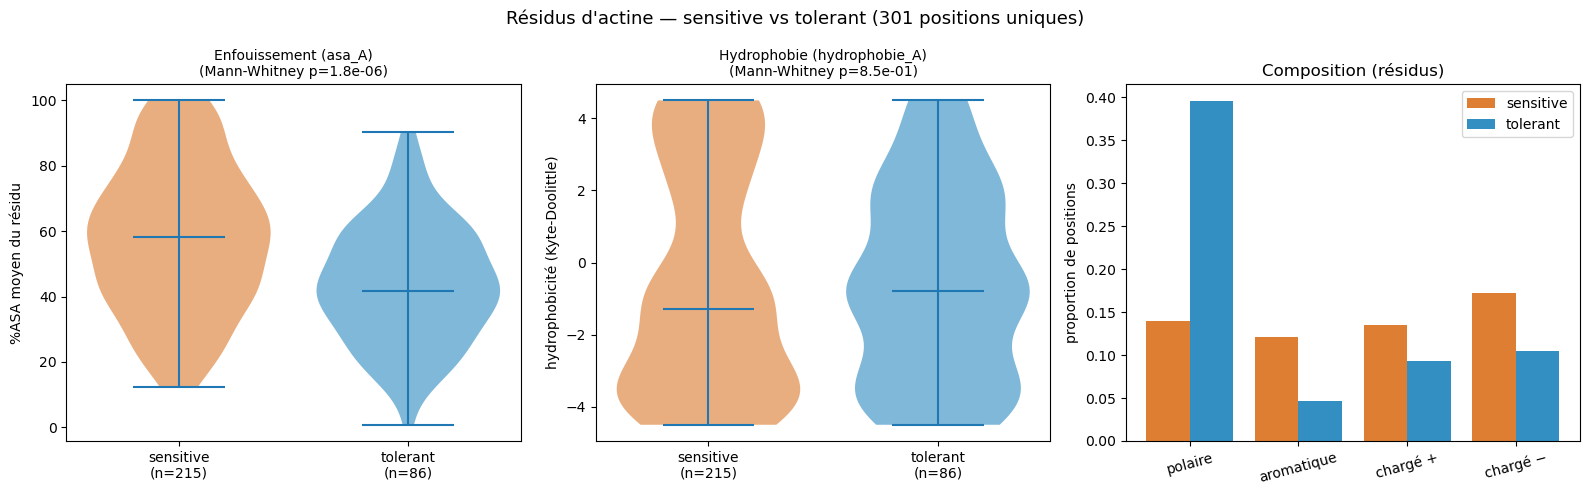


Moyennes par classe (positions uniques) :
             asa    kd   pol   chg   aro
cls                                     
sensitive  57.64 -0.53  0.14 -0.04  0.12
tolerant   43.81 -0.60  0.40 -0.01  0.05

AA les plus frequents par classe :
  sensitive: {'E': np.int64(23), 'I': np.int64(20), 'P': np.int64(16), 'K': np.int64(16), 'G': np.int64(16), 'Y': np.int64(14)}
  tolerant: {'S': np.int64(13), 'A': np.int64(12), 'T': np.int64(10), 'M': np.int64(7), 'D': np.int64(6), 'Q': np.int64(6)}


In [35]:
# === Côté actine (résidu A) : comparaison physico-chimique sensitive vs tolerant ===
# (4 des 5 descripteurs sont discrets -> un scatter PCA fait des "bandes" ; on compare les DISTRIBUTIONS par classe)
from scipy.stats import mannwhitneyu
_canonA=pd.to_numeric(_c['residue_A_canon_mafft'],errors='coerce')
_clsfull=_canonA.map(lambda x:_clsmap.get(int(x)) if pd.notna(x) else None)
_keep=_clsfull.notna().values
_df=pd.DataFrame({'canon':_canonA[_keep].values,'cls':_clsfull[_keep].astype(str).values,
    'aa':_c.loc[_keep,'residue_A_name'].values,'asa':_c.loc[_keep,'asa_A'].values,
    'kd':_c.loc[_keep,'hydrophobie_A'].values,'pol':_c.loc[_keep,'polaire_A'].values,
    'chg':_c.loc[_keep,'charge_A'].values,'aro':_c.loc[_keep,'aromatique_A'].values})
# 1 ligne = 1 POSITION actine unique (pas pondéré par le nb de contacts)
_g=_df.groupby('canon').agg(cls=('cls','first'),aa=('aa','first'),asa=('asa','mean'),
    kd=('kd','first'),pol=('pol','first'),chg=('chg','first'),aro=('aro','first'))
print(f"{len(_g)} positions actine uniques : {dict(_g['cls'].value_counts())}")
_S=_g[_g.cls=='sensitive']; _T=_g[_g.cls=='tolerant']; _col={'sensitive':'#D55E00','tolerant':'#0072B2'}

fig,axs=plt.subplots(1,3,figsize=(16,5))
# --- ASA (continu) ---
def _viol(ax,a,b,ylab,title):
    vp=ax.violinplot([a,b],positions=[1,2],showmedians=True,widths=.8)
    for i,pc in enumerate(vp['bodies']): pc.set_facecolor(['#D55E00','#0072B2'][i]); pc.set_alpha(.5)
    ax.set_xticks([1,2]); ax.set_xticklabels([f'sensitive\n(n={len(_S)})',f'tolerant\n(n={len(_T)})'])
    ax.set_ylabel(ylab); 
    try: _p=mannwhitneyu(a,b).pvalue
    except Exception: _p=float('nan')
    ax.set_title(f'{title}\n(Mann-Whitney p={_p:.1e})',fontsize=10)
_viol(axs[0],_S['asa'].values,_T['asa'].values,'%ASA moyen du résidu','Enfouissement (asa_A)')
_viol(axs[1],_S['kd'].values,_T['kd'].values,'hydrophobicité (Kyte-Doolittle)','Hydrophobie (hydrophobie_A)')
# --- descripteurs binaires : proportions par classe ---
_cats=['polaire','aromatique','chargé +','chargé −']
_sp=[(_S.pol==1).mean(),(_S.aro>=1).mean(),(_S.chg>0).mean(),(_S.chg<0).mean()]
_tp=[(_T.pol==1).mean(),(_T.aro>=1).mean(),(_T.chg>0).mean(),(_T.chg<0).mean()]
_x=np.arange(len(_cats))
axs[2].bar(_x-.2,_sp,.4,label='sensitive',color='#D55E00',alpha=.8)
axs[2].bar(_x+.2,_tp,.4,label='tolerant',color='#0072B2',alpha=.8)
axs[2].set_xticks(_x); axs[2].set_xticklabels(_cats,rotation=15); axs[2].set_ylabel('proportion de positions')
axs[2].set_title('Composition (résidus)'); axs[2].legend()
plt.suptitle('Résidus d\'actine — sensitive vs tolerant (301 positions uniques)',fontsize=13)
plt.tight_layout(); plt.show()

print("\nMoyennes par classe (positions uniques) :")
print(_g.groupby('cls')[['asa','kd','pol','chg','aro']].mean().round(2).to_string())
print("\nAA les plus frequents par classe :")
for gg in ['sensitive','tolerant']:
    print(f'  {gg}:', dict(_g[_g.cls==gg]['aa'].value_counts().head(6)))